# Анализ спроса на шеринговые самокаты

## Описание проекта
Компания, предоставляющая услуги аренды самокатов, недавно вышла на рынок. Собрав первые данные о поездках, она заинтересована в оптимизации бизнеса, в частности — в переходе на динамическое ценообразование.

## Цель проекта
Проанализировать эффективность текущей деятельности компании и выявить факторы, оказывающие влияние на спрос.

## План:
### Этап 0: Предобработка данных и знакомство с ними данных
### Этап 1: Проведение расчетов и исследований.
   #### 1.1 Итоговая стоимость
   #### 1.2 Таблица почасовый трафик
   #### 1.3 Корреляция между параметрами погоды
### Этап 2: Проверка гипотез
#### Предложенные гипотезы
### Этап 3: Регрессионное моделирование
   #### 3.1 Факторы
   #### 3.2 Нюансы
### Этап 4: Дашборд и презентация    
### Этап 5: Финальная сдача проекта

### Этап 0: Предобработка данных и знакомство с ними. Знакомство с данными

Два файла: weather.csv и rides.csv

# Weather.csv

In [2]:
import os
import ast
import pandas as pd
import numpy as np
import seaborn as sns
import re
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from catboost import CatBoostRegressor
import math
from sklearn.metrics import mean_squared_error
from scipy.stats import ttest_ind
from tqdm import tqdm
from scipy.stats import spearmanr

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
warnings.filterwarnings('ignore')

In [3]:
w = pd.read_csv('weather.csv')
w.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3673 entries, 0 to 3672
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Datetime             3672 non-null   object
 1   Temperature          3618 non-null   object
 2   Precipitation Total  3643 non-null   object
 3   Wind Gust            3673 non-null   object
 4   Wind Speed           3657 non-null   object
 5   Cloud Cover Total    3653 non-null   object
 6   Sunshine Duration    3661 non-null   object
dtypes: object(7)
memory usage: 201.0+ KB


Пояснение:
 0   Datetime -  время измерения             
 1   Temperature - температура воздуха          
 2   Precipitation Total - осадки  
 3   Wind Gust - скорость ветра            
 4   Wind Speed - порывы ветра (макс скорость)           
 5   Cloud Cover Total - облачность (% покрытия)    
 6   Sunshine Duration - Солнечное сияние (мин)

# Rides.csv

In [4]:
df = pd.read_csv('rides.csv')
df.info()
data_num = len(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102255 entries, 0 to 102254
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Id              102255 non-null  int64  
 1   Start Date      102255 non-null  object 
 2   End Date        102255 non-null  object 
 3   Start Location  102255 non-null  object 
 4   Start District  102255 non-null  object 
 5   End Location    102255 non-null  object 
 6   End District    102255 non-null  object 
 7   Distance        101022 non-null  float64
 8   Promo           102255 non-null  int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 7.0+ MB


0.   Id - идентификатор поездки              
 1.   Start Date - Start Datetime     
 2.   End Date - End Datetime        
 3.   Start Location - Start Location  
 4.   Start District - Start District   
 5.   End Location - End Location    
 6.   End District - End District    
 7.   Distance - Distance        
 8.   Promo - применен ли промо-код на бесплатный старт

<!-- # *Предобработаем данные по следующему плану:

#### Этап 1: Наименования столбцов - pep-8
## 2. Тип данных
## 3. Явные дубликаты (До стат. расчетов, чтобы не было смещения!)
## 4. Неявные дубликаты (Категориальные столбцы)
## 5. Аномалии/выбросы
  ## 5.1. Предположить причину возникновения, подумать о необходимости обработки
  ## 5.2. Если обработка нужна, то подход как к пропускам (в следующем пункте)
## 6. Пропуски
  ## 6.1. Стратегий несколько, вопрос в том, как обоснуете свое решение
  ## 6.2. Можно учесть взаимосвязи в данных: погода – соседние по времени наблюдения, поездки
## – время/расстояние/скорость, расстояние между районами
## 7. Аналитический и графический анализ данных + выводы (Сколько и чего имеем по результатам
## обработки) -->

### Этап 1:Проведение расчетов и исследований.

Общая информация про файл rides.csv

In [5]:
df = pd.read_csv('rides.csv', sep=',', encoding='utf-8', skipinitialspace=True, decimal=',')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102255 entries, 0 to 102254
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   Id              102255 non-null  int64 
 1   Start Date      102255 non-null  object
 2   End Date        102255 non-null  object
 3   Start Location  102255 non-null  object
 4   Start District  102255 non-null  object
 5   End Location    102255 non-null  object
 6   End District    102255 non-null  object
 7   Distance        101022 non-null  object
 8   Promo           102255 non-null  int64 
dtypes: int64(2), object(7)
memory usage: 7.0+ MB


### Столбец	Тип признака Описание
#### *Id* - Уникальный идентификатор. Идентификатор поездки, номинативный, может рассматриваться как индекс.
#### *Start Date* - Временной (datetime). Дата и время начала поездки.
#### *End Date* - Временной (datetime). Дата и время окончания поездки.
#### *Start Location* - Категориальный. Название улицы старта.
#### *Start District* - Категориальный. Район отправления.
#### *End Location* - Категориальный. Название улицы прибытия.
#### *End District* - Категориальный. Район прибытия.
#### *Distance* - Количественный (непрерывный). Пройденное расстояние, в метрах.
#### *Promo* - Категориальный (бинарный). Флаг: была ли акция (0/1).

# Очистка DataFrame df, удаляем некорректные строки и преобразуя даты.

## Явные дубликаты

In [6]:
# initial_count = len(df)
# df = df.drop_duplicates()
# final_count = len(df)

# removed = initial_count - final_count
# print(f"Удалено дубликатов: {removed}")

<!-- Удалено дубликатов: 4883<br>
Было: 102255, Стало: 97372 -->

In [7]:
df.reset_index(drop=True)
df.head(10)

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,Шевченко,Юго-Восточный,Майская,Октябрьский,4069.0,0
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,Чехова,заречный,Спортивная,октябрьский,4515.0,0
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,Буденного,Октябрьский,Суворова,ленинский,4520.0,0
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,Труда,Центральный,Рабочая,Северо-Западный,3881.0,0
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,Первомайская,Северо-Западный,Юбилейная,Юго-Восточный,4029.0,0
5,100345,2023-04-22 09:10:09,2023-04-22 09:49:56,Лесная,Юго-Восточный,Западная,Ленинский,4879.0,0
6,100346,2023-04-22 09:15:12,2023-04-22 09:26:01,Пролетарская,Центральный,Свободы,Ленинский,1846.0,0
7,100347,2023-04-22 09:19:13,2023-04-22 09:40:03,Комарова,Ленинский,ул. западная,Ленинский,3133.0,0
8,100348,2023-04-22 09:21:42,2023-04-22 09:39:04,Западная,ленинский,Озерная,Юго-Восточный,3.0,0
9,100349,2023-04-22 09:28:00,2023-04-22 10:02:08,Свободы,ленинский,ул. чкалова,юго-восточный,5263.0,0


Есть несколько вещей, которые необходимо проверить и выполнить, прежде чем можно будет продолжить анализ.

- Переименование столбцов, чтобы исключить пустое пространство между именами столбцов
- Проверка того, что столбцы имеют соответствующий тип данных
- Проверьте и удалите значения N / A или дублированные значения, если таковые имеются
- Проверьте, нет ли аномалий в категориальных и числовых столбцах (опечаток, значений, которые не имеют смысла, и т.д.)

#### Переименование столбцов

In [8]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
cols = df.copy()

#### Определение типов 

In [9]:
for col in cols.columns:
    print(col + ' has the datatype: \t',  cols[col].dtype)

id has the datatype: 	 int64
start_date has the datatype: 	 object
end_date has the datatype: 	 object
start_location has the datatype: 	 object
start_district has the datatype: 	 object
end_location has the datatype: 	 object
end_district has the datatype: 	 object
distance has the datatype: 	 object
promo has the datatype: 	 int64


- Судя по результатам, дата поездки не распознается как объект datetime. Ее необходимо преобразовать в столбец объекта datetime.
- По опыту, данные о месяцах, начале поездки и другие ячейки также могут быть полезны. Они будут извлечены в отдельный столбец для облегчения доступа.

In [10]:
df['start_date'] = pd.to_datetime(df['start_date'])
df['end_date'] = pd.to_datetime(df['end_date'])
df.head(5)

,id,start_date,end_date,start_location,start_district,end_location,end_district,distance,promo
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,Шевченко,Юго-Восточный,Майская,Октябрьский,4069.0,0
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,Чехова,заречный,Спортивная,октябрьский,4515.0,0
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,Буденного,Октябрьский,Суворова,ленинский,4520.0,0
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,Труда,Центральный,Рабочая,Северо-Западный,3881.0,0
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,Первомайская,Северо-Западный,Юбилейная,Юго-Восточный,4029.0,0


In [42]:
seasons = {
    12: 'зима', 1: 'зима', 2: 'зима',
    3: 'весна', 4: 'весна', 5: 'весна',
    6: 'лето', 7: 'лето', 8: 'лето',
    9: 'осень', 10: 'осень', 11: 'осень'
}

df['start_month'] = df['start_date'].dt.month
df['start_season'] = df['start_month'].map(seasons)

df['start_hour'] = df['start_date'].dt.hour

def time_of_day(x):
    if 5 <= x <= 12:
        return 'утро'
    elif 12 < x <= 18:
        return 'день'
    elif 18 < x <= 22:
        return 'вечер'
    return 'ночь'

df['time_of_day'] = df['start_date'].apply(lambda x: time_of_day(x.hour))
df['weekday'] = df['start_date'].dt.weekday

df['day_type'] = df['weekday'].apply(lambda x: 'будний день' if x < 5 else 'выходной')
df['days'] = df['start_date'].dt.day

df['duration'] = (df['end_date'] - df['start_date']).dt.total_seconds() / 60
df['distance'] = pd.to_numeric(df['distance'], errors='coerce')
df['speed'] = (df['distance'] / 1000) / (df['duration'] / 60)

df.head(10)

,id,start_date,end_date,start_location,start_district,end_location,end_district,distance,promo,start_month,...,end_month,end_season,date,starthourcum,endhourcum,start_date_shifted,end_date_shifted,starthour2,endhour2,start_season
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,шевченко,юго-восточный,майская,октябрьский,4069.000000,0,4,...,4,весна,2023 4 22 9,2023-04-22 09:00:00,2023-04-22 09:00:00,2023-04-22 03:01:03,2023-04-22 03:24:45,2023-04-22 03:00:00,2023-04-22 03:00:00,весна
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,чехова,заречный,спортивная,октябрьский,4515.000000,0,4,...,4,весна,2023 4 22 9,2023-04-22 09:00:00,2023-04-22 09:00:00,2023-04-22 03:01:07,2023-04-22 03:29:32,2023-04-22 03:00:00,2023-04-22 03:00:00,весна
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,буденного,октябрьский,суворова,ленинский,4520.000000,0,4,...,4,весна,2023 4 22 9,2023-04-22 09:00:00,2023-04-22 09:00:00,2023-04-22 03:04:27,2023-04-22 03:42:46,2023-04-22 03:00:00,2023-04-22 03:00:00,весна
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,труда,центральный,рабочая,северо-западный,3881.000000,0,4,...,4,весна,2023 4 22 9,2023-04-22 09:00:00,2023-04-22 09:00:00,2023-04-22 03:06:34,2023-04-22 03:38:23,2023-04-22 03:00:00,2023-04-22 03:00:00,весна
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,первомайская,северо-западный,юбилейная,юго-восточный,4029.000000,0,4,...,4,весна,2023 4 22 9,2023-04-22 09:00:00,2023-04-22 09:00:00,2023-04-22 03:09:27,2023-04-22 03:40:07,2023-04-22 03:00:00,2023-04-22 03:00:00,весна
5,100345,2023-04-22 09:10:09,2023-04-22 09:49:56,лесная,юго-восточный,западная,ленинский,4879.000000,0,4,...,4,весна,2023 4 22 9,2023-04-22 09:00:00,2023-04-22 09:00:00,2023-04-22 03:10:09,2023-04-22 03:49:56,2023-04-22 03:00:00,2023-04-22 03:00:00,весна
6,100346,2023-04-22 09:15:12,2023-04-22 09:26:01,пролетарская,центральный,свободы,ленинский,1846.000000,0,4,...,4,весна,2023 4 22 9,2023-04-22 09:00:00,2023-04-22 09:00:00,2023-04-22 03:15:12,2023-04-22 03:26:01,2023-04-22 03:00:00,2023-04-22 03:00:00,весна
7,100347,2023-04-22 09:19:13,2023-04-22 09:40:03,комарова,ленинский,западная,ленинский,3133.000000,0,4,...,4,весна,2023 4 22 9,2023-04-22 09:00:00,2023-04-22 09:00:00,2023-04-22 03:19:13,2023-04-22 03:40:03,2023-04-22 03:00:00,2023-04-22 03:00:00,весна
8,100348,2023-04-22 09:21:42,2023-04-22 09:39:04,западная,ленинский,озерная,юго-восточный,3066.639014,0,4,...,4,весна,2023 4 22 9,2023-04-22 09:00:00,2023-04-22 09:00:00,2023-04-22 03:21:42,2023-04-22 03:39:04,2023-04-22 03:00:00,2023-04-22 03:00:00,весна
9,100349,2023-04-22 09:28:00,2023-04-22 10:02:08,свободы,ленинский,чкалова,юго-восточный,5263.000000,0,4,...,4,весна,2023 4 22 9,2023-04-22 09:00:00,2023-04-22 10:00:00,2023-04-22 03:28:00,2023-04-22 04:02:08,2023-04-22 03:00:00,2023-04-22 04:00:00,весна


## Неявные дубликаты

#### Для начала смотрим формат написания улиц и сводим его к одному стилю

In [12]:
print(df['start_location'].unique(), df['start_district'].unique())
print(df.duplicated().sum())

['Шевченко' 'Чехова' 'Буденного' 'Труда' 'Первомайская' 'Лесная'
 'Пролетарская' 'Комарова' 'Западная' 'Свободы' 'Коммунальная' 'Зеленая'
 'Шоссейная' 'Центральная' 'буденного' 'новая' 'Энтузиастов'
 'ул.подгорная' 'Восточная' 'Лермонтова' 'Школьная' 'Пушкина' 'подгорная'
 'рябиновая' 'Солнечная' 'Мичурина' 'ул труда' 'Партизанская' 'Вокзальная'
 'Комсомольская' 'майская' 'Красноармейская' 'Рабочая' 'Почтовая' 'дачная'
 'Заводская' 'Ломоносова' 'карла маркса' 'Советская' 'Красная'
 'Дзержинского' 'Рябиновая' 'ул.советская' 'ул.энергетиков' 'Пионерская'
 'ленина' 'ул. сиреневая' 'гагарина' 'юбилейная' 'Цветочная'
 'ул. набережная' 'Сосновая' 'Спортивная' 'Новая' 'Ленина' 'Полевая'
 'ул. строительная' 'Майская' 'Озерная' 'ул.горького' 'ул. восточная'
 'пионерская' 'Энергетиков' 'ул.озерная' 'южная' 'Некрасова'
 'ул.молодежная' 'ул. пионерская' 'Чкалова' 'Речная' 'Парковая'
 'Карла Маркса' 'строителей' 'Кирова' 'Набережная' 'матросова' 'Садовая'
 'колхозная' 'ул. чкалова' 'комарова' 'Луго

#### Замена названий улиц

In [13]:
def clean_street(name):
    if isinstance(name, str):
        name = name.lower().replace('ул.', '').replace('ул ', '').strip()
        return name
    return name


df['start_location'] = df['start_location'].apply(clean_street)
df['start_district'] = df['start_district'].apply(lambda x: x.lower().replace(' ', '-'))
df['end_location'] = df['end_location'].apply(clean_street)
df['end_district'] = df['end_district'].apply(lambda x: x.lower().replace(' ', '-'))

df.head(10)

,id,start_date,end_date,start_location,start_district,end_location,end_district,distance,promo,start_month,season,start_hour,time_of_day,weekday,day_type,days,duration,speed
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,шевченко,юго-восточный,майская,октябрьский,4069.0,0,4,весна,9,утро,5,выходной,22,23.700000,10.301266
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,чехова,заречный,спортивная,октябрьский,4515.0,0,4,весна,9,утро,5,выходной,22,28.416667,9.533138
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,буденного,октябрьский,суворова,ленинский,4520.0,0,4,весна,9,утро,5,выходной,22,38.316667,7.077860
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,труда,центральный,рабочая,северо-западный,3881.0,0,4,весна,9,утро,5,выходной,22,31.816667,7.318806
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,первомайская,северо-западный,юбилейная,юго-восточный,4029.0,0,4,весна,9,утро,5,выходной,22,30.666667,7.882826
5,100345,2023-04-22 09:10:09,2023-04-22 09:49:56,лесная,юго-восточный,западная,ленинский,4879.0,0,4,весна,9,утро,5,выходной,22,39.783333,7.358358
6,100346,2023-04-22 09:15:12,2023-04-22 09:26:01,пролетарская,центральный,свободы,ленинский,1846.0,0,4,весна,9,утро,5,выходной,22,10.816667,10.239753
7,100347,2023-04-22 09:19:13,2023-04-22 09:40:03,комарова,ленинский,западная,ленинский,3133.0,0,4,весна,9,утро,5,выходной,22,20.833333,9.023040
8,100348,2023-04-22 09:21:42,2023-04-22 09:39:04,западная,ленинский,озерная,юго-восточный,3.0,0,4,весна,9,утро,5,выходной,22,17.366667,0.010365
9,100349,2023-04-22 09:28:00,2023-04-22 10:02:08,свободы,ленинский,чкалова,юго-восточный,5263.0,0,4,весна,9,утро,5,выходной,22,34.133333,9.251367


Распределение улиц по районам

In [14]:
grouped_streets_by_district = df.groupby('start_district')['start_location'].unique().to_frame()
grouped_streets_by_district = pd.DataFrame(grouped_streets_by_district)
grouped_streets_by_district['1'] = grouped_streets_by_district['start_location'].apply(len)
grouped_streets_by_district.sort_values(by='1', ascending=False)

,start_location,1
start_district,,
центральный,"[труда, пролетарская, зеленая, энтузиастов, пу...",30
юго-восточный,"[шевченко, лесная, коммунальная, центральная, ...",22
ленинский,"[комарова, западная, свободы, подгорная, лермо...",14
северо-западный,"[первомайская, новая, школьная, рябиновая, раб...",13
заречный,"[чехова, шоссейная, комсомольская, пионерская,...",6
октябрьский,"[буденного, восточная, майская, ломоносова, сп...",6


#### Нужно посмотреть пропуски по дате, чтобы заранее не тянуть за собой лишние ячейки

In [15]:
missing_dates = df[['start_date', 'end_date']].isnull().sum()

print("Количество пропущенных значений в датах:")
print(missing_dates)

Количество пропущенных значений в датах:
start_date      0
end_date      579
dtype: int64


In [16]:
df['distance'].describe()

count    1.010220e+05
mean     2.729110e+04
std      3.097186e+05
min      1.000000e+00
25%      3.044000e+03
50%      3.702000e+03
75%      4.429000e+03
max      7.569789e+06
Name: distance, dtype: float64

Получается, что в строках, где нет конечной даты, остальные данные не нулевые

##### Всего пропущенных значений в конечной дате (end_date): 579
##### Чтобы не терять данные, можно восстановить пропущенное время на основе регрессии

In [17]:
valid = df[(df['end_date'].notnull()) & (df['distance'] > 100) & (df['duration'] > 1) & (df['speed'] < 20)]
X = valid[['distance']]
y = valid['duration']

model = LinearRegression()
model.fit(X, y)

missing = df[df['end_date'].isnull()].copy()
missing['predicted_duration'] = model.predict(missing[['distance']])
missing['predicted_duration'] = missing['predicted_duration'].clip(lower=3)

missing['end_date'] = missing['start_date'] + pd.to_timedelta(missing['predicted_duration'], unit='m')

df.update(missing[['end_date']])

print("Оставшиеся пропуски в end_date:", df['end_date'].isnull().sum())

Оставшиеся пропуски в end_date: 0


In [18]:
missing_dates = df[['start_date', 'end_date']].isnull().sum()
print("Количество пропущенных значений в датах:")
print(missing_dates)
df.head(10)

Количество пропущенных значений в датах:
start_date    0
end_date      0
dtype: int64


,id,start_date,end_date,start_location,start_district,end_location,end_district,distance,promo,start_month,season,start_hour,time_of_day,weekday,day_type,days,duration,speed
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,шевченко,юго-восточный,майская,октябрьский,4069.0,0,4,весна,9,утро,5,выходной,22,23.700000,10.301266
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,чехова,заречный,спортивная,октябрьский,4515.0,0,4,весна,9,утро,5,выходной,22,28.416667,9.533138
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,буденного,октябрьский,суворова,ленинский,4520.0,0,4,весна,9,утро,5,выходной,22,38.316667,7.077860
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,труда,центральный,рабочая,северо-западный,3881.0,0,4,весна,9,утро,5,выходной,22,31.816667,7.318806
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,первомайская,северо-западный,юбилейная,юго-восточный,4029.0,0,4,весна,9,утро,5,выходной,22,30.666667,7.882826
5,100345,2023-04-22 09:10:09,2023-04-22 09:49:56,лесная,юго-восточный,западная,ленинский,4879.0,0,4,весна,9,утро,5,выходной,22,39.783333,7.358358
6,100346,2023-04-22 09:15:12,2023-04-22 09:26:01,пролетарская,центральный,свободы,ленинский,1846.0,0,4,весна,9,утро,5,выходной,22,10.816667,10.239753
7,100347,2023-04-22 09:19:13,2023-04-22 09:40:03,комарова,ленинский,западная,ленинский,3133.0,0,4,весна,9,утро,5,выходной,22,20.833333,9.023040
8,100348,2023-04-22 09:21:42,2023-04-22 09:39:04,западная,ленинский,озерная,юго-восточный,3.0,0,4,весна,9,утро,5,выходной,22,17.366667,0.010365
9,100349,2023-04-22 09:28:00,2023-04-22 10:02:08,свободы,ленинский,чкалова,юго-восточный,5263.0,0,4,весна,9,утро,5,выходной,22,34.133333,9.251367


#### Далее посмотрим графики распределения категориальных признаков для выявления аномалий

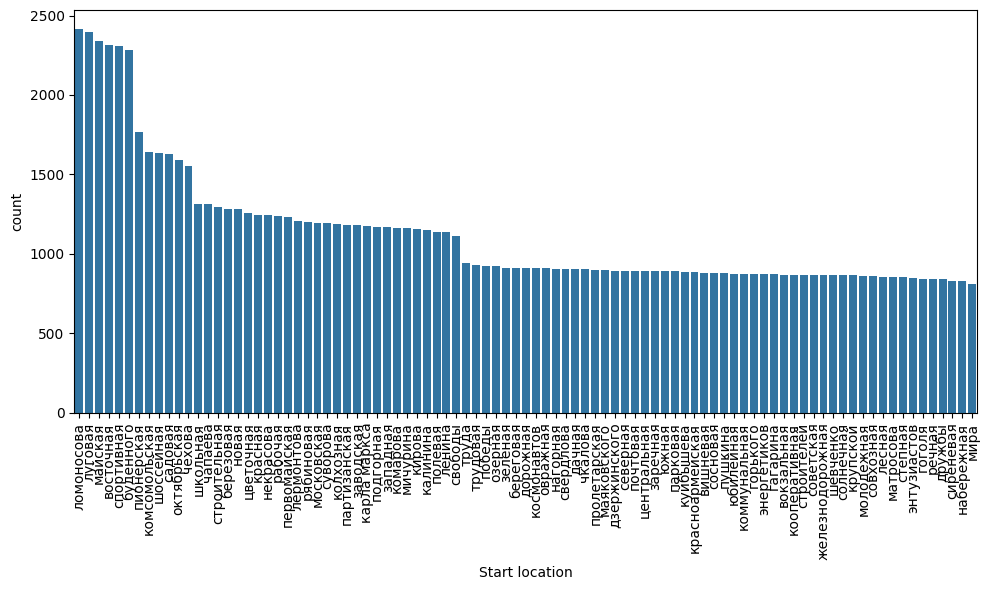

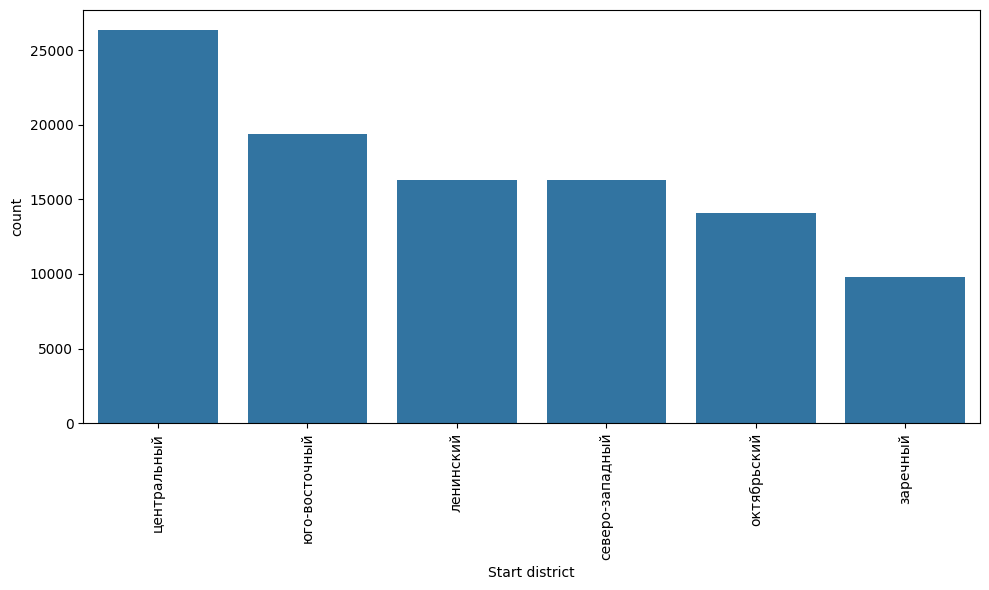

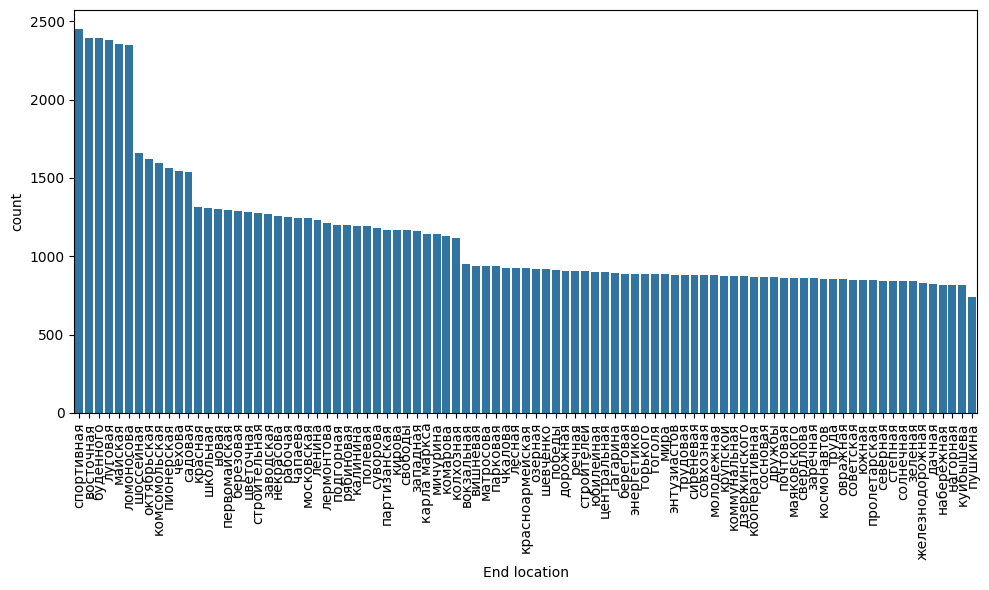

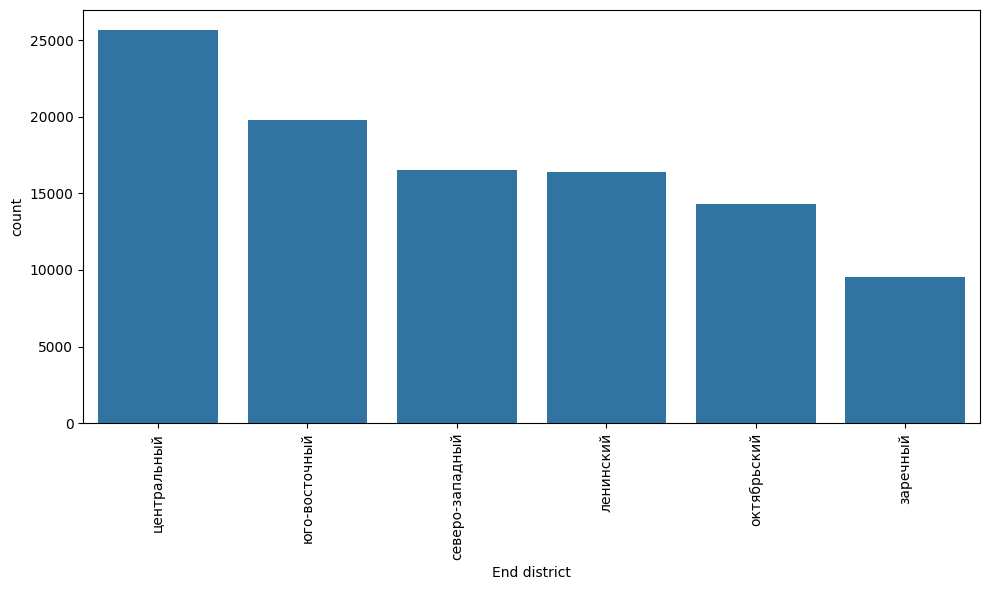

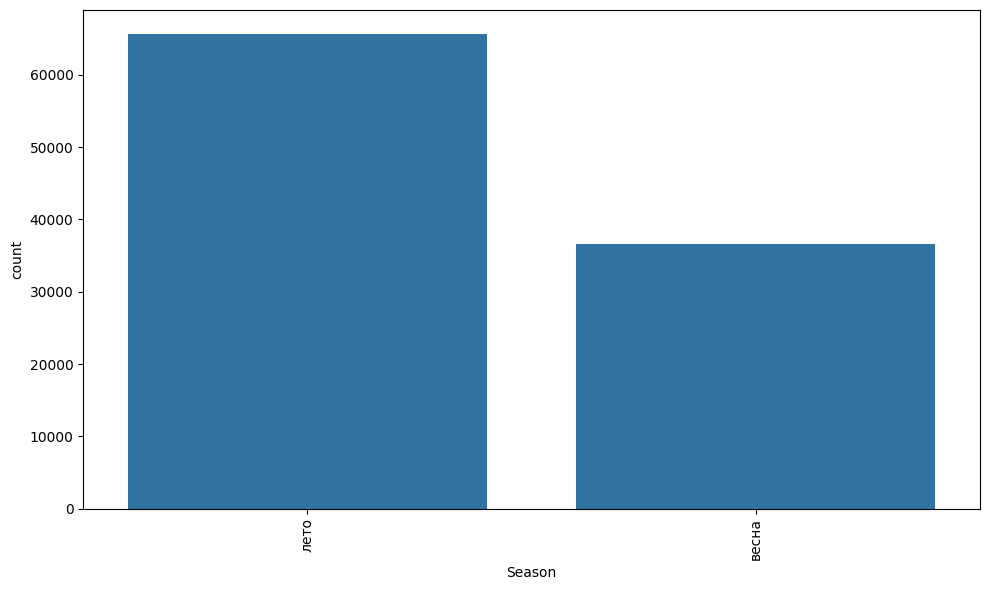

In [19]:
categorical_columns = ['start_location','start_district', 'end_location','end_district','season']

def plot_all_hist(df, columns):
    for col in columns:
        plt.figure(figsize=(10, 6))
        order = df[col].value_counts().index
        sns.countplot(x=col, data=df, order=order)
        plt.xlabel(col.replace('_', ' ').capitalize())
        plt.xticks(rotation=90) 
        plt.tight_layout()
        plt.show()

plot_all_hist(df, categorical_columns)

##### Аномальных значений не найдено, приведение улиц к одному формату позволило избежать неправильного распределения

#### Теперь посмотрим распределение количественных признаков для выявления аномалий

In [20]:
numerical_cols = ['distance','duration','speed']
df[numerical_cols].describe()

,distance,duration,speed
count,1.010220e+05,101676.000000,100443.000000
mean,2.729110e+04,26.368571,65.588570
std,3.097186e+05,9.946608,736.902834
min,1.000000e+00,2.566667,0.002395
25%,3.044000e+03,19.466667,7.662272
50%,3.702000e+03,24.616667,9.115320
75%,4.429000e+03,31.233333,10.541813
max,7.569789e+06,84.833333,15580.652700


##### Есть значительные выбросы, которые можно заметить по колонке speed, так как максимальная скорость 15580, чего физически не может быть, именно поэтому среднее не соотносится со значениями квартилей

In [21]:
Q1 = df['speed'].quantile(0.25)
Q3 = df['speed'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

df_check_anomalies = df[(df['speed'] >= lower_bound) & (df['speed'] <= upper_bound)]
df_check_anomalies.head(10)
df_check_anomalies['speed'].describe()

count    99823.000000
mean         8.907849
std          2.558748
min          0.002395
25%          7.650777
50%          9.098973
75%         10.510671
max         19.122772
Name: speed, dtype: float64

Чтобы сравнить распределение до после построим графики дистанции и сокрости

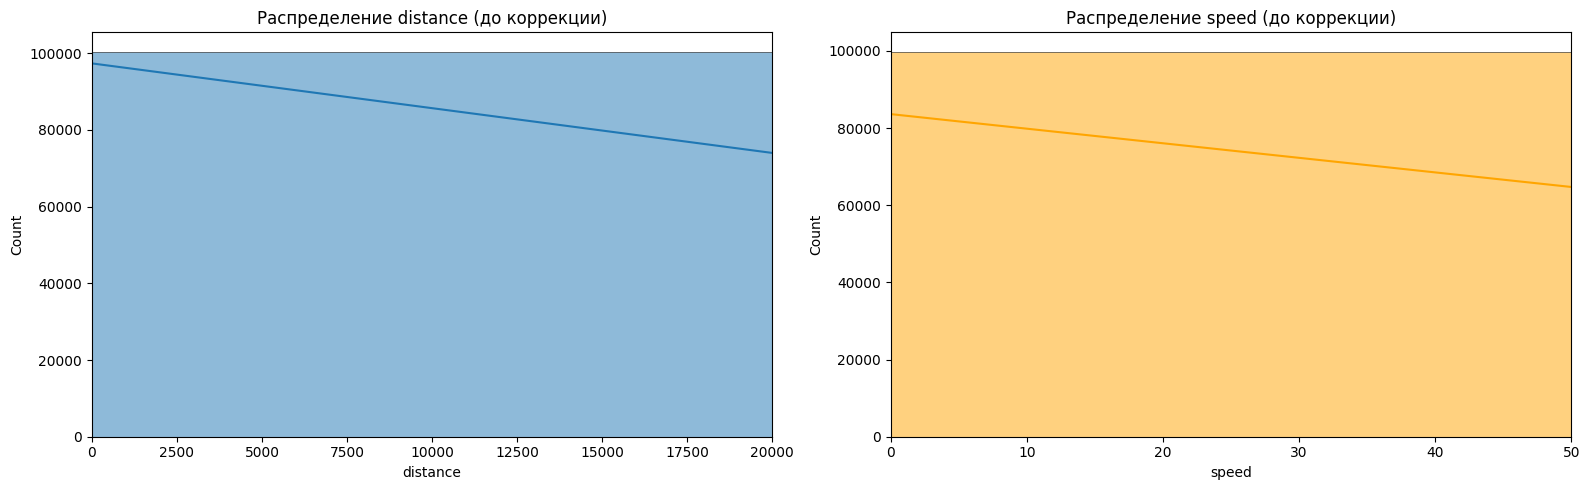

In [22]:
plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['distance'], bins=100, kde=True)
plt.title("Распределение distance (до коррекции)")
plt.xlim(0, 20000)

plt.subplot(1, 2, 2)
sns.histplot(df['speed'], bins=100, kde=True, color='orange')
plt.title("Распределение speed (до коррекции)")
plt.xlim(0, 50)

plt.tight_layout()
plt.show()


Для исправления аномальных значений воспользуемся градиентым бустингом, учитывая факторы, которые могут повлиять на изменение дистанции. Применяется такой способ, чтобы не просто брать среднюю скорость, а стараться учесть другие признаки для более точного попадания

In [23]:
df_model = df[(df['speed'] > 3) & (df['speed'] < 40) & (df['duration'] > 1)].copy()

features = ['duration', 'start_hour', 'weekday', 'day_type', 'season', 'time_of_day']
target = 'distance'

cat_features = ['weekday', 'day_type', 'season', 'time_of_day']
num_features = ['duration', 'start_hour']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
    ('num', 'passthrough', num_features)
])

model = Pipeline(steps=[
    ('prep', preprocessor),
    ('reg', GradientBoostingRegressor(n_estimators=200, max_depth=5, random_state=42))
])

X = df_model[features]
y = df_model[target]

model.fit(X, y)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['weekday', 'day_type',
                                                   'season', 'time_of_day']),
                                                 ('num', 'passthrough',
                                                  ['duration',
                                                   'start_hour'])])),
                ('reg',
                 GradientBoostingRegressor(max_depth=5, n_estimators=200,
                                           random_state=42))])

Чтобы заменить значения, нужно понять, что является нормальным значением и применять до верхней границы 95%

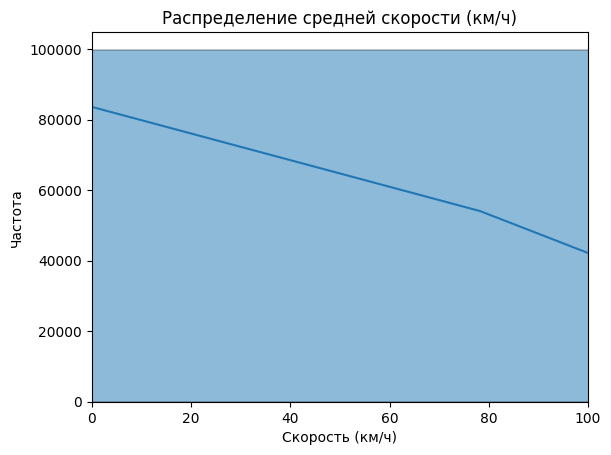

count    100443.000000
mean         65.588570
std         736.902834
min           0.002395
1%            0.008170
5%            5.048275
25%           7.662272
50%           9.115320
75%          10.541813
95%          12.664658
99%          14.679226
max       15580.652700
Name: speed, dtype: float64


In [24]:
sns.histplot(df['speed'], bins=100, kde=True)
plt.title('Распределение средней скорости (км/ч)')
plt.xlabel('Скорость (км/ч)')
plt.ylabel('Частота')
plt.xlim(0, 100)  # чтобы отсечь экстремумы
plt.show()

print(df['speed'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))
low_speed = df['speed'].quantile(0.05)
high_speed = df['speed'].quantile(0.95)

In [25]:
mask_outliers = (df['duration'] > 5) & (df['duration'] < 90) & (
    (df['speed'] < low_speed) | (df['speed'] > high_speed)
)

df_outliers = df[mask_outliers].copy()
df.loc[mask_outliers, 'distance'] = model.predict(df_outliers[features])

df['speed'] = (df['distance'] / 1000) / (df['duration'] / 60)

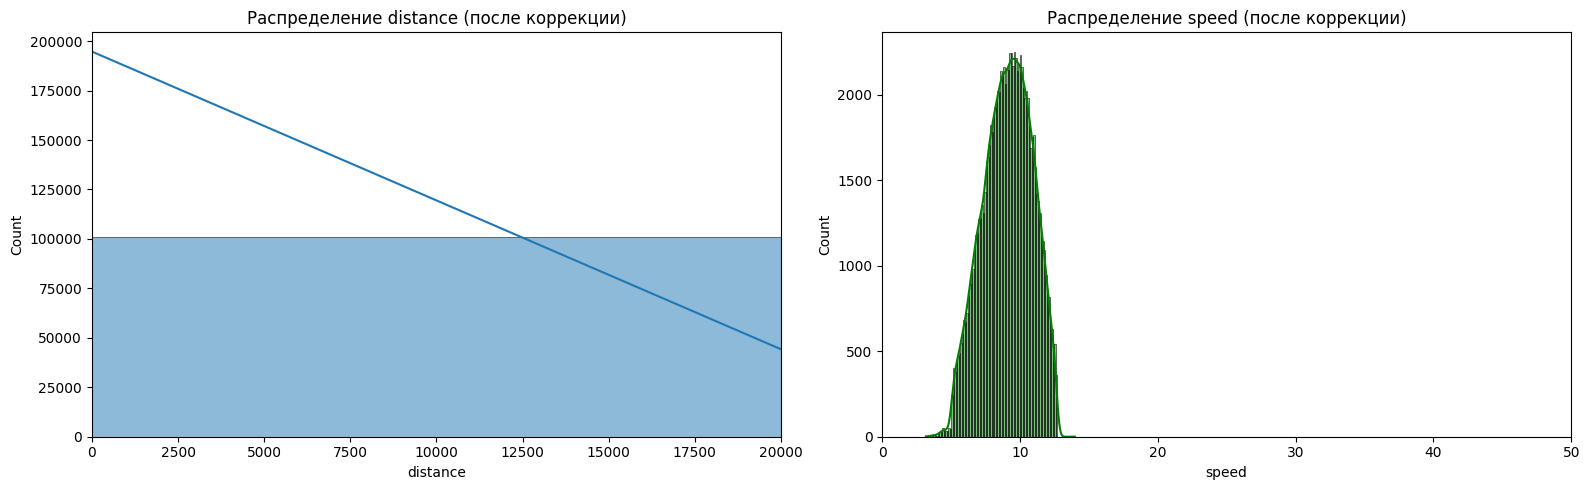

,id,start_date,end_date,start_location,start_district,end_location,end_district,distance,promo,start_month,season,start_hour,time_of_day,weekday,day_type,days,duration,speed
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,шевченко,юго-восточный,майская,октябрьский,4069.000000,0,4,весна,9,утро,5,выходной,22,23.700000,10.301266
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,чехова,заречный,спортивная,октябрьский,4515.000000,0,4,весна,9,утро,5,выходной,22,28.416667,9.533138
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,буденного,октябрьский,суворова,ленинский,4520.000000,0,4,весна,9,утро,5,выходной,22,38.316667,7.077860
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,труда,центральный,рабочая,северо-западный,3881.000000,0,4,весна,9,утро,5,выходной,22,31.816667,7.318806
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,первомайская,северо-западный,юбилейная,юго-восточный,4029.000000,0,4,весна,9,утро,5,выходной,22,30.666667,7.882826
5,100345,2023-04-22 09:10:09,2023-04-22 09:49:56,лесная,юго-восточный,западная,ленинский,4879.000000,0,4,весна,9,утро,5,выходной,22,39.783333,7.358358
6,100346,2023-04-22 09:15:12,2023-04-22 09:26:01,пролетарская,центральный,свободы,ленинский,1846.000000,0,4,весна,9,утро,5,выходной,22,10.816667,10.239753
7,100347,2023-04-22 09:19:13,2023-04-22 09:40:03,комарова,ленинский,западная,ленинский,3133.000000,0,4,весна,9,утро,5,выходной,22,20.833333,9.023040
8,100348,2023-04-22 09:21:42,2023-04-22 09:39:04,западная,ленинский,озерная,юго-восточный,3066.639014,0,4,весна,9,утро,5,выходной,22,17.366667,10.594914
9,100349,2023-04-22 09:28:00,2023-04-22 10:02:08,свободы,ленинский,чкалова,юго-восточный,5263.000000,0,4,весна,9,утро,5,выходной,22,34.133333,9.251367


In [26]:
plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['distance'], bins=100, kde=True)
plt.title("Распределение distance (после коррекции)")
plt.xlim(0, 20000)

plt.subplot(1, 2, 2)
sns.histplot(df['speed'], bins=100, kde=True, color='green')
plt.title("Распределение speed (после коррекции)")
plt.xlim(0, 50)

plt.tight_layout()
plt.show()
df.head(10)

In [27]:
df['speed'].describe()

count    100443.000000
mean          9.099979
std           1.760212
min           3.168274
25%           7.840991
50%           9.186684
75%          10.442922
max          13.991489
Name: speed, dtype: float64

In [28]:
initial_count = len(df)
df = df.drop_duplicates()
print(f"Удалено неявных дубликатов: {initial_count - len(df)}")

Удалено неявных дубликатов: 4883


In [29]:
print(f"Было {data_num}")
print(f"Стало {len(df)}")

Было 102255
Стало 97372


#### ИТОГ: 
- Привели столбцы к PEP-8
- Заменили названия улиц и районов для правильного распределения
- С помощью регрессии заменили 579 пропусков в end_date
- С помощью градиентного бустинга убрали аномалии в дистанции

#### Добавление длительности поездки, средней скорости

In [30]:
def get_rate(weekday, hour):
    if weekday < 5:  # Пн–Пт
        if 1 <= hour < 6:
            return 3
        elif 6 <= hour < 10:
            return 4
        elif 10 <= hour < 16:
            return 5
        elif 16 <= hour < 22:
            return 6
        else:  # 22:00 – 01:00 (hour 22, 23, 0)
            return 5
    else:  # Сб–Вс
        if 1 <= hour < 6:
            return 3
        elif 6 <= hour < 10:
            return 4
        elif 10 <= hour < 16:
            return 6
        elif 16 <= hour < 22:
            return 7
        else:  # 22:00 – 01:00 (hour 22, 23, 0)
            return 6


def calculate_trip_cost(row):
    weekday = row['weekday']
    start_hour = row['start_hour']
    duration = row['duration']  
    promo = row['promo']

    rate = get_rate(weekday, start_hour)

    # Если акция, бесплатный старт, но учитываем длительность и стоимость минуты
    if promo == 1 and (weekday == 0 and 6 <= start_hour < 10):  # Понедельник, с 6:00 до 10:00
        return duration * rate  # бесплатный старт, считаем только длительность * стоимость минуты
    else:
        # Если без промо или не понедельник с акцией
        return start_cost + (duration * rate)


start_cost = 30

df['rate_per_minute'] = df.apply(lambda row: get_rate(row['weekday'], row['start_hour']), axis=1)
df['cost'] = df.apply(calculate_trip_cost, axis=1)
df['cost_no_start'] = df['duration'] * df['rate_per_minute']

df.head(10)

,id,start_date,end_date,start_location,start_district,end_location,end_district,distance,promo,start_month,...,start_hour,time_of_day,weekday,day_type,days,duration,speed,rate_per_minute,cost,cost_no_start
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,шевченко,юго-восточный,майская,октябрьский,4069.000000,0,4,...,9,утро,5,выходной,22,23.700000,10.301266,4,124.800000,94.800000
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,чехова,заречный,спортивная,октябрьский,4515.000000,0,4,...,9,утро,5,выходной,22,28.416667,9.533138,4,143.666667,113.666667
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,буденного,октябрьский,суворова,ленинский,4520.000000,0,4,...,9,утро,5,выходной,22,38.316667,7.077860,4,183.266667,153.266667
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,труда,центральный,рабочая,северо-западный,3881.000000,0,4,...,9,утро,5,выходной,22,31.816667,7.318806,4,157.266667,127.266667
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,первомайская,северо-западный,юбилейная,юго-восточный,4029.000000,0,4,...,9,утро,5,выходной,22,30.666667,7.882826,4,152.666667,122.666667
5,100345,2023-04-22 09:10:09,2023-04-22 09:49:56,лесная,юго-восточный,западная,ленинский,4879.000000,0,4,...,9,утро,5,выходной,22,39.783333,7.358358,4,189.133333,159.133333
6,100346,2023-04-22 09:15:12,2023-04-22 09:26:01,пролетарская,центральный,свободы,ленинский,1846.000000,0,4,...,9,утро,5,выходной,22,10.816667,10.239753,4,73.266667,43.266667
7,100347,2023-04-22 09:19:13,2023-04-22 09:40:03,комарова,ленинский,западная,ленинский,3133.000000,0,4,...,9,утро,5,выходной,22,20.833333,9.023040,4,113.333333,83.333333
8,100348,2023-04-22 09:21:42,2023-04-22 09:39:04,западная,ленинский,озерная,юго-восточный,3066.639014,0,4,...,9,утро,5,выходной,22,17.366667,10.594914,4,99.466667,69.466667
9,100349,2023-04-22 09:28:00,2023-04-22 10:02:08,свободы,ленинский,чкалова,юго-восточный,5263.000000,0,4,...,9,утро,5,выходной,22,34.133333,9.251367,4,166.533333,136.533333


## Дополнительные действия: добавление нужных столбиков дат

In [31]:
df['day_of_week'] = df['start_date'].dt.day_name()
df['end_month'] = df['end_date'].dt.month
df['end_season'] = df['end_month'].map(seasons)

def time_day(x):
    if 5 <= x <= 12:
        return 'Утро'
    elif 12 < x <= 18:
        return 'День'
    elif 18 < x <= 22:
        return 'Вечер'
    return 'Ночь'


df['date'] = df['start_date'].apply(lambda x: str(x.year) + ' ' + str(x.month) + ' ' + str(x.day) + ' ' + str(x.hour))
df['starthourcum'] = df['start_date'].dt.floor('H')
df['endhourcum'] = df['end_date'].dt.floor('H')
df['start_date_shifted'] = df['start_date'] - pd.Timedelta(hours=6)
df['end_date_shifted'] = df['end_date'] - pd.Timedelta(hours=6)
df['starthour2'] = df['start_date_shifted'].dt.floor('h')
df['endhour2'] = df['end_date_shifted'].dt.floor('h')

## Аномалии и выбросы

Анализ дистанции: строк > 10000 и <=5 около 3363

Почему значения Distance < 100 м — это аномалия?
- Физическая нереалистичность:

Поездка на самокате длиной 3–50 метров — это скорее шаг пешком. Реальный пользователь вряд ли бы взял самокат на такую дистанцию.
Это может быть результатом ошибки GPS, неправильного старта/финиша, тестов, или неудачного трекинга.

- Время поездки несоразмерно маленькой дистанции:

Можно встретить поездку длиной 4 метра, которая длится 10+ минут — это маловероятно и указывает на ошибку в геоданных.

- Повторяющиеся адреса:

Начальная и конечная локация могут совпадать (самокат не двигался), но всё равно расстояние не ноль — ещё один признак сбоя в данных.

In [32]:
q1 = df['distance'].quantile(0.25)
q2 = df['distance'].quantile(0.50)  # или median()
q3 = df['distance'].quantile(0.75)
iqr = q3 - q1

print(f"Q1 (25%): {q1}")
print(f"Q2 (Median): {q2}")
print(f"Q3 (75%): {q3}")
print(f"IQR (Q3 - Q1): {iqr}")

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[(df['distance'] < lower_bound) | (df['distance'] > upper_bound)]
print(f"Количество выбросов по Distance: {len(outliers)}")


Q1 (25%): 3088.0
Q2 (Median): 3720.8532321554035
Q3 (75%): 4448.0
IQR (Q3 - Q1): 1360.0
Количество выбросов по Distance: 1201


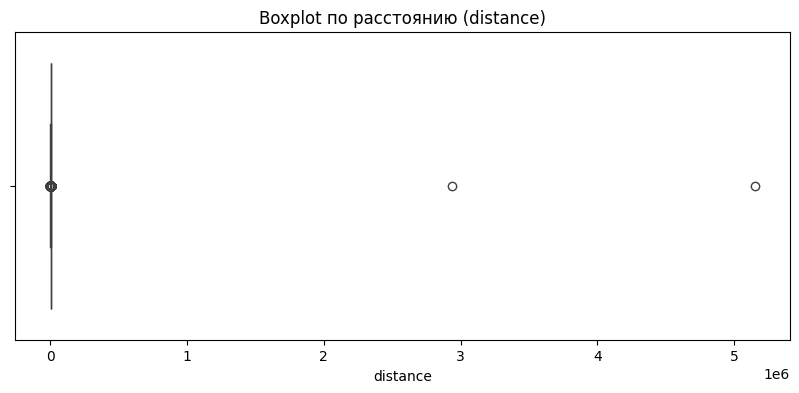

      start_location  end_location   distance  duration
495       ломоносова     цветочная        4.0       NaN
2546     октябрьская      комарова        5.0       NaN
2806       восточная  строительная        3.0       NaN
10158  комсомольская     заводская  5149229.0       NaN
15582         гоголя      дорожная        3.0       NaN
16517       мичурина     восточная        5.0       NaN
21876        майская      гагарина        4.0       NaN
27939       крупской     буденного        4.0       NaN
46102    энтузиастов    спортивная        4.0       NaN
46473     спортивная         труда        4.0       NaN
Количество аномальных строк в Distance: 18
Количество поездок с дистанцией меньше 100 м: 16
Количество поездок с дистанцией более 10000 м: 2


In [34]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['distance'])
plt.title("Boxplot по расстоянию (distance)")
plt.show()

anomalies_distance = df[(df['distance'] <= 100) | (df['distance'] > 10000)]
anomalies_count = anomalies_distance.shape[0]
print(anomalies_distance[['start_location', 'end_location', 'distance', 'duration']].head(10))

low_distance_count = df[df['distance'] < 100].shape[0]
high_distance_count = df[df['distance'] > 10000].shape[0]

print(f"Количество аномальных строк в Distance: {anomalies_count}")
print(f"Количество поездок с дистанцией меньше 100 м: {low_distance_count}")
print(f"Количество поездок с дистанцией более 10000 м: {high_distance_count}")

Количество выбросов по каждому району:
start_district
ленинский          8
северо-западный    5
юго-восточный      4
заречный           3
октябрьский        0
центральный        0
Name: is_outlier, dtype: int64
Аномальных строк по условию Distance < 100: 16
Аномальных строк по условию Distance > upper_bound: 20
Выбросы по Distance удалены.


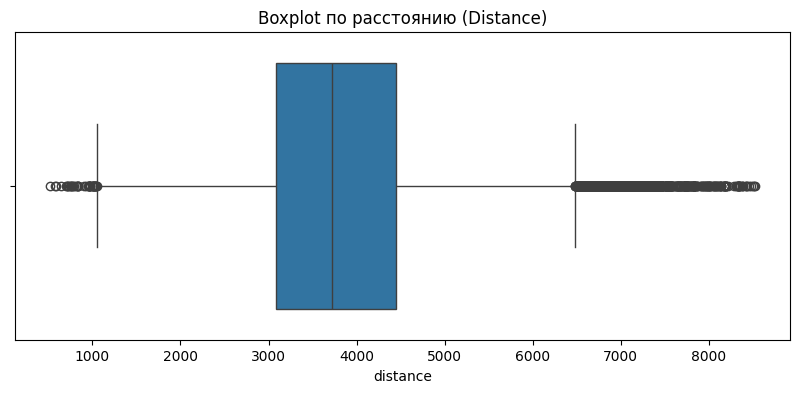

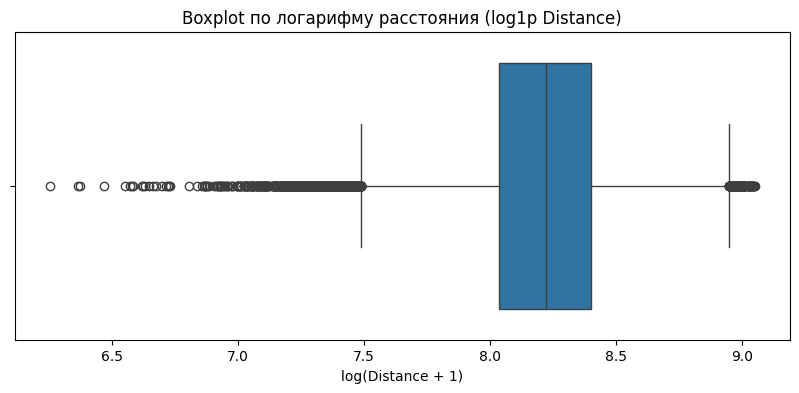

In [36]:
# Квартильные границы
q1 = df['distance'].quantile(0.25)
q3 = df['distance'].quantile(0.75)
iqr = q3 - q1

# Границы для определения выбросов
condition = (df['distance'] < 100) & (df['duration'] > 8)
upper_bound = q3 + 3 * iqr

df1 = df.copy()
df1['is_outlier'] = (condition) | (df1['distance'] > upper_bound)
outliers_by_district = df1.groupby('start_district')['is_outlier'].sum()
print("Количество выбросов по каждому району:")
print(outliers_by_district.sort_values(ascending=False))

condition = (df['distance'] < 100)
condition_large = (df['distance'] > upper_bound)

print(f"Аномальных строк по условию Distance < 100: {condition.sum()}")
print(f"Аномальных строк по условию Distance > upper_bound: {condition_large.sum()}")

df = df[(df['distance'] >= 100) & (df['distance'] <= upper_bound)]

print("Выбросы по Distance удалены.")


plt.figure(figsize=(10, 4))
sns.boxplot(x=df['distance'])
plt.title("Boxplot по расстоянию (Distance)")
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(x=np.log1p(df['distance']))  # log1p = log(1 + x) для работы с нулями
plt.title("Boxplot по логарифму расстояния (log1p Distance)")
plt.xlabel("log(Distance + 1)")
plt.show()


- Удалено аномальных строк по условию Distance < 100: 2923
- Удалено Аномальных строк по условию Distance > upper_bound: 60
#####
Выбросы по Distance удалены.

##### Почему могли возникнуть аномалии и такие выбросы?
##### - GPS плохо работает в центре, поэтому не видно остановку самоката, следовательно время поездки увеличивается, не смотря на стоячее положение
##### - По распределению пропусков видно, что в центре аномалий больше, что также можно приурочить к некорректной работе GPS

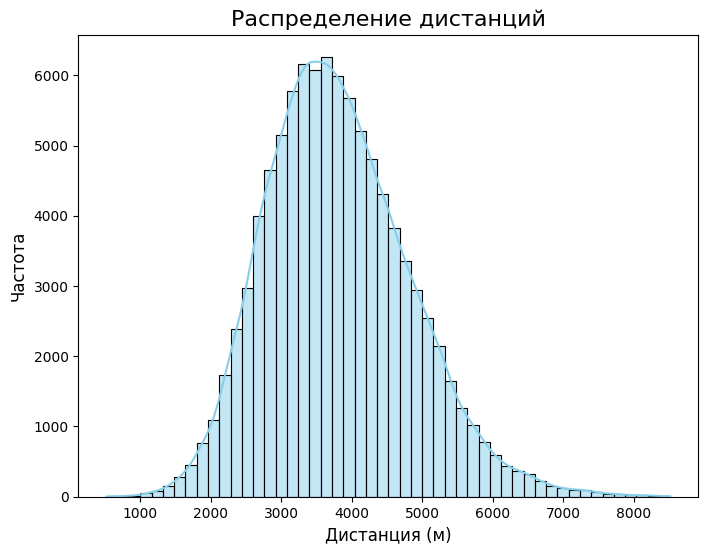

In [37]:
df = df[df['distance'] <= 10000]
plt.figure(figsize=(8, 6))
sns.histplot(df['distance'], kde=True, color='skyblue', bins=50)

plt.title('Распределение дистанций', fontsize=16)
plt.xlabel('Дистанция (м)', fontsize=12)
plt.ylabel('Частота', fontsize=12)

plt.show()

In [38]:
missing_end_date = df[df['end_date'].isna()]
print(f"Пропусков в 'End Date': {len(missing_end_date)}")

print(missing_end_date[['start_date', 'end_date']].head(10))


Пропусков в 'End Date': 0
Empty DataFrame
Columns: [start_date, end_date]
Index: []


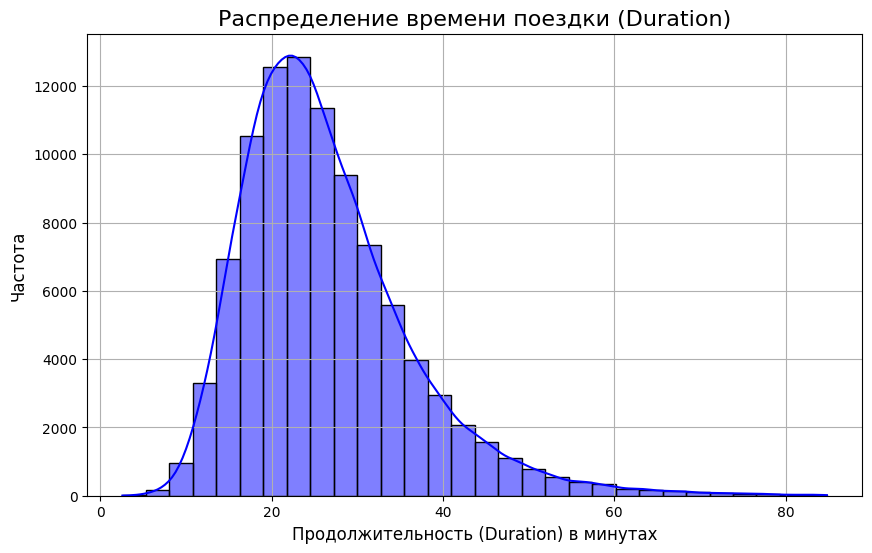

In [39]:
# Построение гистограммы распределения для столбца 'Duration'
plt.figure(figsize=(10, 6))
sns.histplot(df['duration'], kde=True, bins=30, color='blue')

# Настройки графика
plt.title('Распределение времени поездки (Duration)', fontsize=16)
plt.xlabel('Продолжительность (Duration) в минутах', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.grid(True)

# Показать график
plt.show()

Поиск и удаление дубликатов в DataFrame df, основываясь на дате начала поездки и районе отправления.

In [40]:
duplicates = df[df.duplicated(subset=['start_date', 'start_district'], keep=False)]
df = df.drop_duplicates(subset=['start_date', 'start_district'], keep='first')
df.head(10)

,id,start_date,end_date,start_location,start_district,end_location,end_district,distance,promo,start_month,...,day_of_week,end_month,end_season,date,starthourcum,endhourcum,start_date_shifted,end_date_shifted,starthour2,endhour2
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,шевченко,юго-восточный,майская,октябрьский,4069.000000,0,4,...,Saturday,4,весна,2023 4 22 9,2023-04-22 09:00:00,2023-04-22 09:00:00,2023-04-22 03:01:03,2023-04-22 03:24:45,2023-04-22 03:00:00,2023-04-22 03:00:00
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,чехова,заречный,спортивная,октябрьский,4515.000000,0,4,...,Saturday,4,весна,2023 4 22 9,2023-04-22 09:00:00,2023-04-22 09:00:00,2023-04-22 03:01:07,2023-04-22 03:29:32,2023-04-22 03:00:00,2023-04-22 03:00:00
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,буденного,октябрьский,суворова,ленинский,4520.000000,0,4,...,Saturday,4,весна,2023 4 22 9,2023-04-22 09:00:00,2023-04-22 09:00:00,2023-04-22 03:04:27,2023-04-22 03:42:46,2023-04-22 03:00:00,2023-04-22 03:00:00
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,труда,центральный,рабочая,северо-западный,3881.000000,0,4,...,Saturday,4,весна,2023 4 22 9,2023-04-22 09:00:00,2023-04-22 09:00:00,2023-04-22 03:06:34,2023-04-22 03:38:23,2023-04-22 03:00:00,2023-04-22 03:00:00
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,первомайская,северо-западный,юбилейная,юго-восточный,4029.000000,0,4,...,Saturday,4,весна,2023 4 22 9,2023-04-22 09:00:00,2023-04-22 09:00:00,2023-04-22 03:09:27,2023-04-22 03:40:07,2023-04-22 03:00:00,2023-04-22 03:00:00
5,100345,2023-04-22 09:10:09,2023-04-22 09:49:56,лесная,юго-восточный,западная,ленинский,4879.000000,0,4,...,Saturday,4,весна,2023 4 22 9,2023-04-22 09:00:00,2023-04-22 09:00:00,2023-04-22 03:10:09,2023-04-22 03:49:56,2023-04-22 03:00:00,2023-04-22 03:00:00
6,100346,2023-04-22 09:15:12,2023-04-22 09:26:01,пролетарская,центральный,свободы,ленинский,1846.000000,0,4,...,Saturday,4,весна,2023 4 22 9,2023-04-22 09:00:00,2023-04-22 09:00:00,2023-04-22 03:15:12,2023-04-22 03:26:01,2023-04-22 03:00:00,2023-04-22 03:00:00
7,100347,2023-04-22 09:19:13,2023-04-22 09:40:03,комарова,ленинский,западная,ленинский,3133.000000,0,4,...,Saturday,4,весна,2023 4 22 9,2023-04-22 09:00:00,2023-04-22 09:00:00,2023-04-22 03:19:13,2023-04-22 03:40:03,2023-04-22 03:00:00,2023-04-22 03:00:00
8,100348,2023-04-22 09:21:42,2023-04-22 09:39:04,западная,ленинский,озерная,юго-восточный,3066.639014,0,4,...,Saturday,4,весна,2023 4 22 9,2023-04-22 09:00:00,2023-04-22 09:00:00,2023-04-22 03:21:42,2023-04-22 03:39:04,2023-04-22 03:00:00,2023-04-22 03:00:00
9,100349,2023-04-22 09:28:00,2023-04-22 10:02:08,свободы,ленинский,чкалова,юго-восточный,5263.000000,0,4,...,Saturday,4,весна,2023 4 22 9,2023-04-22 09:00:00,2023-04-22 10:00:00,2023-04-22 03:28:00,2023-04-22 04:02:08,2023-04-22 03:00:00,2023-04-22 04:00:00


# Анализ факторов, влияющих на спрос, и визуализирует результаты. Он показывает когда (по сезонам, дням, часам) чаще всего происходят поездки, а также среднюю длительность поездок в зависимости от времени года

start_season
весна    26.397682
лето     26.357005
Name: duration, dtype: float64
day_of_week
Sunday       17896
Saturday     17728
Friday       13900
Monday       12559
Wednesday    11506
Thursday     11370
Tuesday      11036
Name: count, dtype: int64
start_hour
0     1144
1      560
2      431
3      188
4      216
5      821
6     2423
7     3473
8     3913
9     3780
10    3651
11    3208
12    3580
13    4110
14    5197
15    6012
16    7002
17    7686
18    8101
19    8580
20    8037
21    6254
22    4754
23    2874
Name: count, dtype: int64


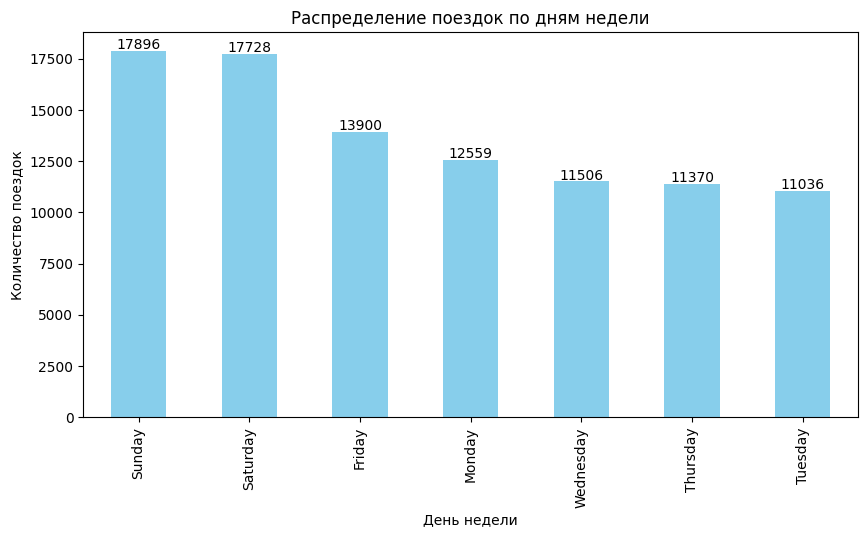

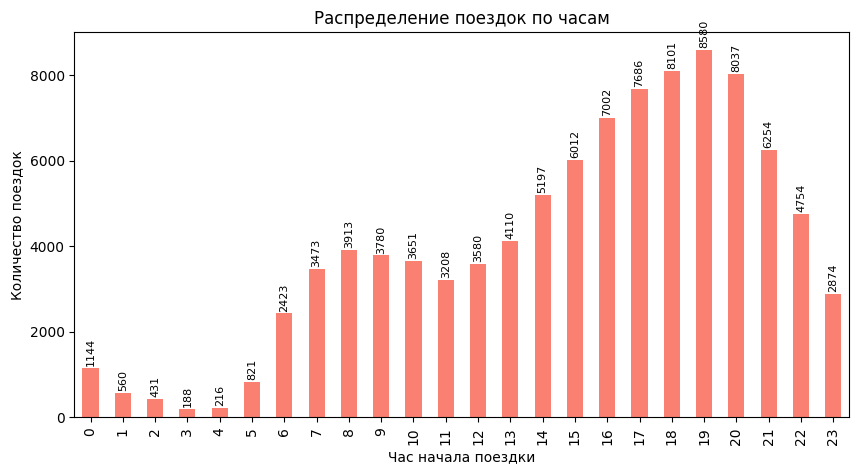

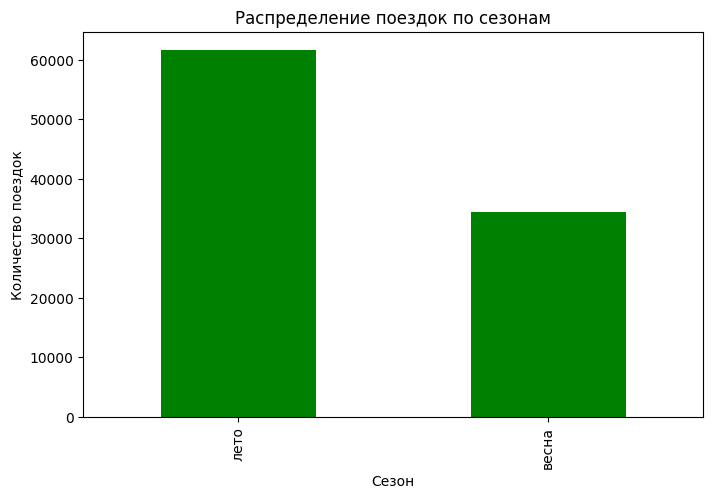

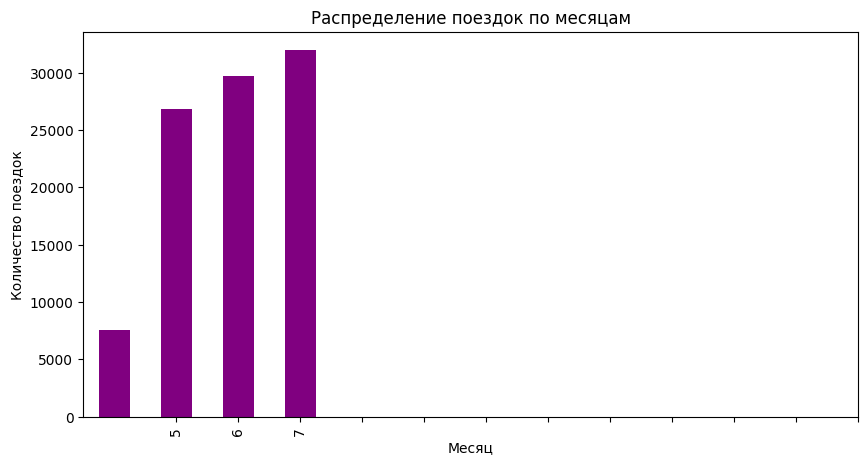

In [43]:
# Анализ факторов, влияющих на спрос
# 1. Средняя длительность поездки по сезонам
season_duration = df.groupby('start_season')['duration'].mean()
print(season_duration)

# 2. Количество поездок по дням недели
day_counts = df['day_of_week'].value_counts()
print(day_counts)

# 3. Количество поездок по часам
hour_counts = df['start_hour'].value_counts().sort_index()
print(hour_counts)

# 4. Количество поездок по сезонам
season_counts = df['start_season'].value_counts()

# 5. Количество поездок по месяцам
month_counts = df['start_month'].value_counts().sort_index()

# Визуализация данных с аннотациями
plt.figure(figsize=(10, 5))
day_counts.plot(kind='bar', color='skyblue')
plt.xlabel('День недели')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по дням недели')
for i, v in enumerate(day_counts):
    plt.text(i, v + 100, str(v), ha='center', fontsize=10)
plt.show()

plt.figure(figsize=(10, 5))
hour_counts.plot(kind='bar', color='salmon')
plt.xlabel('Час начала поездки')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по часам')
for i, v in enumerate(hour_counts):
    plt.text(i, v + 100, str(v), ha='center', fontsize=8, rotation=90)
plt.show()

plt.figure(figsize=(8, 5))
season_counts.plot(kind='bar', color='green')
plt.xlabel('Сезон')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по сезонам')
plt.show()

plt.figure(figsize=(10, 5))
month_counts.plot(kind='bar', color='purple')
plt.xlabel('Месяц')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по месяцам')
plt.xticks(range(1, 13))
plt.show()

Строим гистограмму распределения дистанций поездок

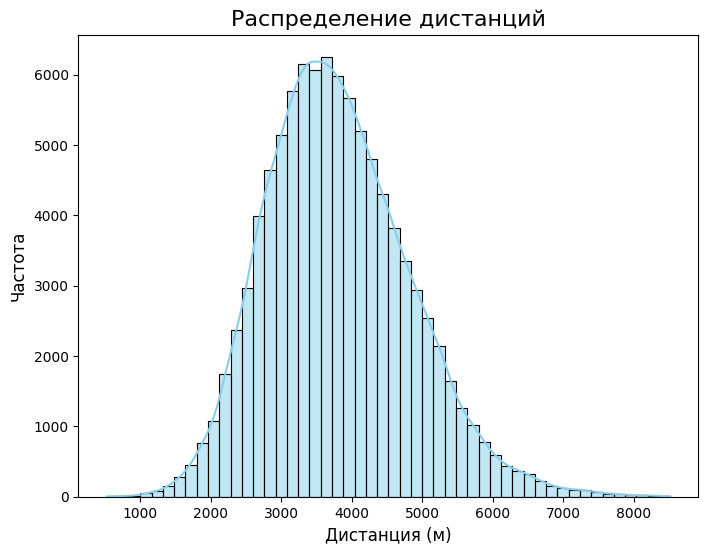

In [44]:
plt.figure(figsize=(8, 6))
sns.histplot(df['distance'], kde=True, color='skyblue', bins=50)

# Добавим подписи и заголовок
plt.title('Распределение дистанций', fontsize=16)
plt.xlabel('Дистанция (м)', fontsize=12)
plt.ylabel('Частота', fontsize=12)

# Показать график
plt.show()

In [47]:
df.columns

Index(['id', 'start_date', 'end_date', 'start_location', 'start_district',
       'end_location', 'end_district', 'distance', 'promo', 'start_month',
       'start_hour', 'time_of_day', 'weekday', 'day_type', 'days', 'duration',
       'speed', 'rate_per_minute', 'cost', 'cost_no_start', 'day_of_week',
       'end_month', 'end_season', 'date', 'starthourcum', 'endhourcum',
       'start_date_shifted', 'end_date_shifted', 'starthour2', 'endhour2',
       'start_season'],
      dtype='object')

# Рассчитываем стоимость каждой поездки на основе времени суток и дня недели, применяя динамическую тарифную сетку.

Столбчатая диаграмму (bar plot), показывающую распределение поездок по времени суток (Утро, День, Вечер, Ночь)

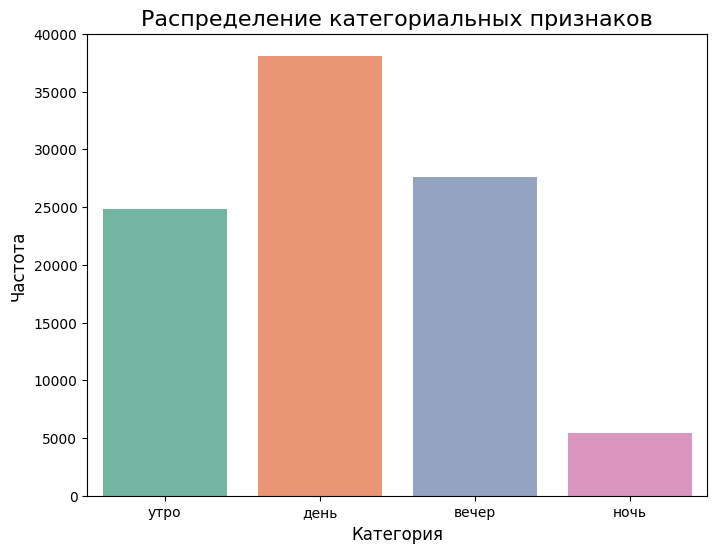

In [48]:
plt.figure(figsize=(8, 6))
sns.countplot(x='time_of_day', data=df, palette='Set2')

plt.title('Распределение категориальных признаков', fontsize=16)
plt.xlabel('Категория', fontsize=12)
plt.ylabel('Частота', fontsize=12)

plt.show()

Два анализа: один — визуализирует распределение стоимости поездки по районам, а второй — рассчитывает среднюю продолжительность поездки по районам.

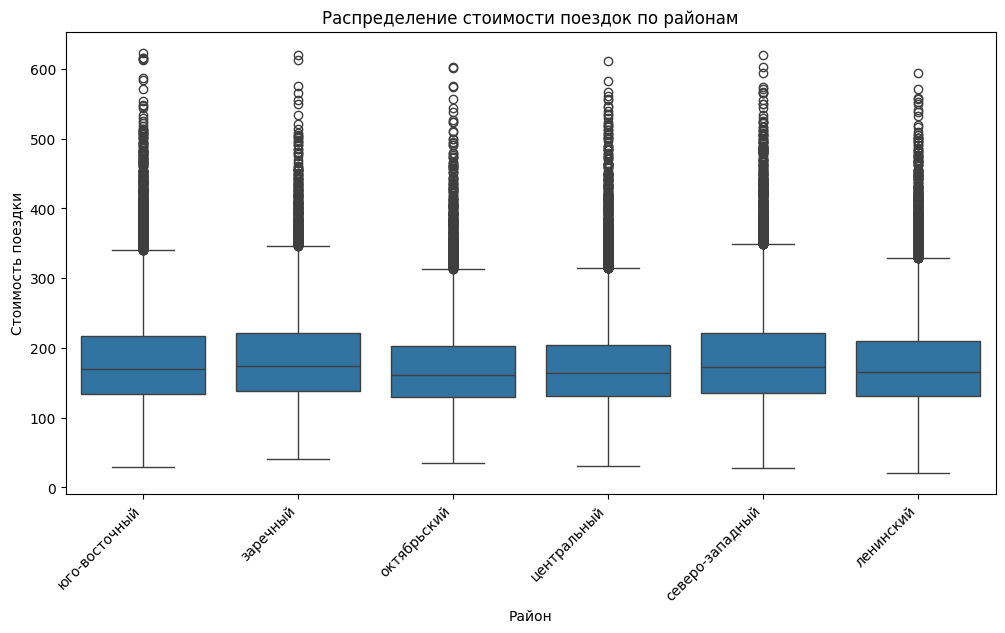

start_district
заречный           27.769205
северо-западный    27.666196
юго-восточный      27.188727
ленинский          26.127199
октябрьский        25.241779
центральный        25.201552
Name: duration, dtype: float64


In [50]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='start_district', y='cost', data=df)

plt.xticks(rotation=45, ha='right')
plt.xlabel('Район')
plt.ylabel('Стоимость поездки')
plt.title('Распределение стоимости поездок по районам')

plt.show()

average_duration_by_district = df.groupby('start_district')['duration'].mean().sort_values(ascending=False)
print(average_duration_by_district)

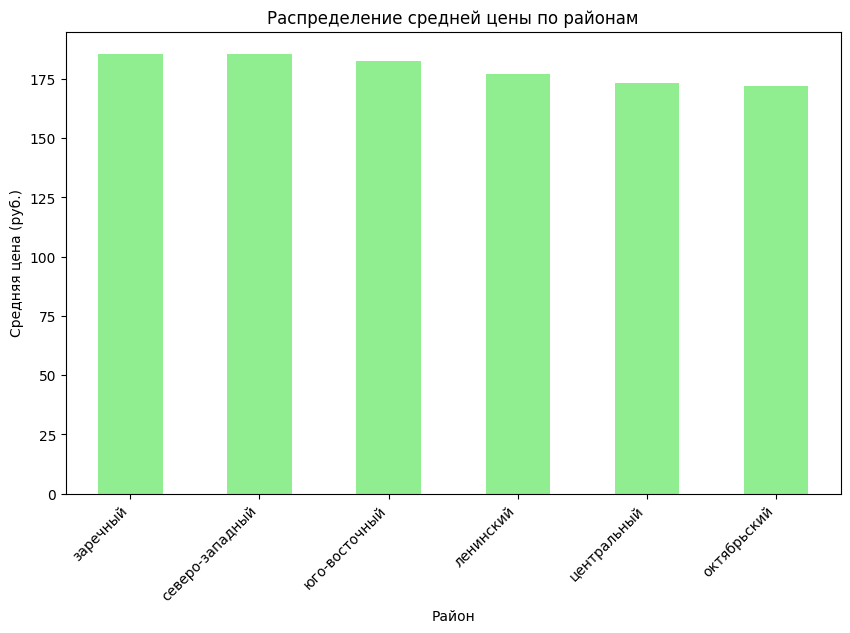

In [51]:
district_price = df.groupby('start_district')['cost'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
district_price.plot(kind='bar', color='lightgreen')
plt.xlabel('Район')
plt.ylabel('Средняя цена (руб.)')
plt.title('Распределение средней цены по районам')
plt.xticks(rotation=45, ha='right')
plt.show()

График для отображения средней продолжительности поездки по различным районам, чтобы наглядно сравнить, где поездки в среднем длительнее, а где короче.

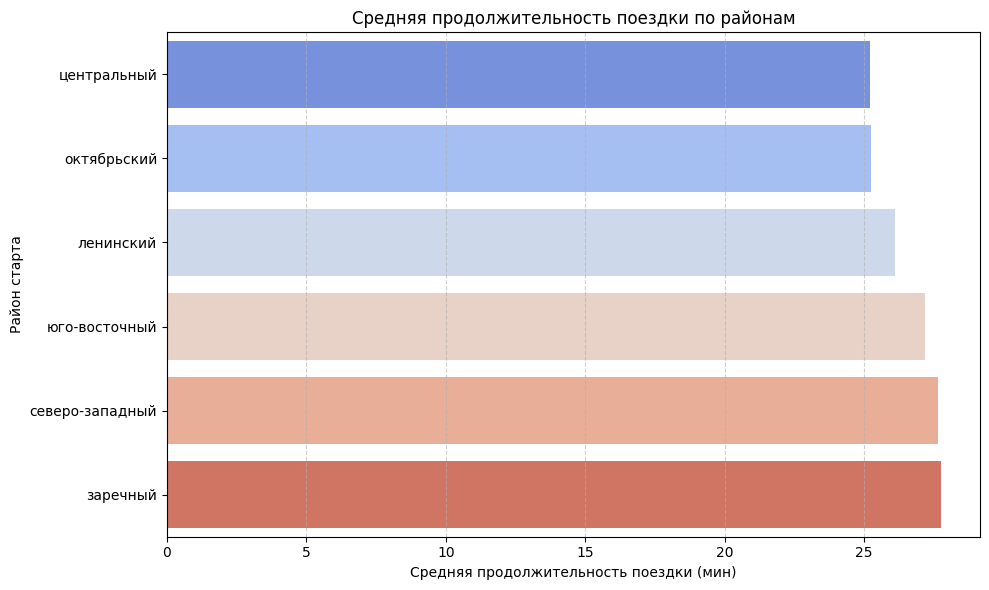

In [52]:
district_durations = df.groupby("start_district")["duration"].mean().sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=district_durations.values, y=district_durations.index, palette="coolwarm")
plt.xlabel("Средняя продолжительность поездки (мин)")
plt.ylabel("Район старта")
plt.title("Средняя продолжительность поездки по районам")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

 Тепловая карта для визуализации распределения количества поездок по часам дня и районам старта.
- Группировка данных по району старта и часу:
- Сортировка районов по убыванию количества поездок:
- Создание сводной таблицы (pivot table):
- Сортировка таблицы по убыванию количества поездок в районах:
- Построение тепловой карты (Heatmap):
- Настройки графика:

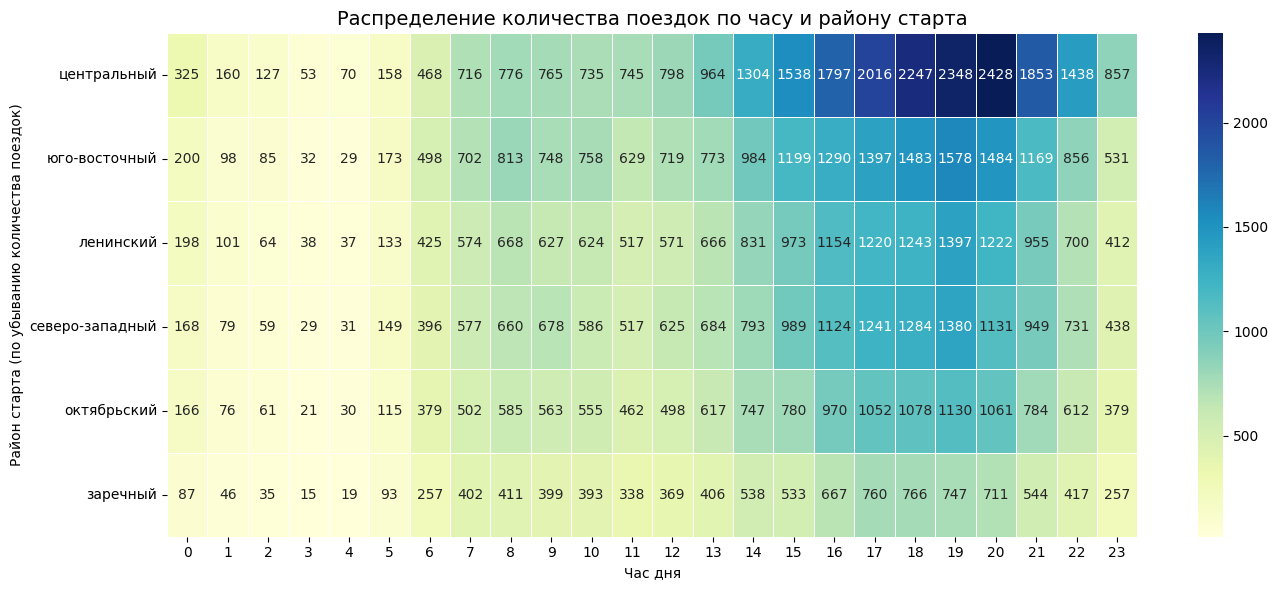

In [53]:
grouped = df.groupby(['start_district', 'start_hour']).size().reset_index(name='Trip Count')
district_order = df['start_district'].value_counts().index.tolist()
pivot_table = grouped.pivot(index='start_district', columns='start_hour', values='Trip Count').fillna(0)

pivot_table = pivot_table.reindex(district_order)

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_table, cmap="YlGnBu", annot=True, fmt=".0f", linewidths=.5)
plt.title("Распределение количества поездок по часу и району старта", fontsize=14)
plt.xlabel("Час дня")
plt.ylabel("Район старта (по убыванию количества поездок)")
plt.tight_layout()
plt.show()

In [56]:
df.columns

Index(['id', 'start_date', 'end_date', 'start_location', 'start_district',
       'end_location', 'end_district', 'distance', 'promo', 'start_month',
       'start_hour', 'time_of_day', 'weekday', 'day_type', 'days', 'duration',
       'speed', 'rate_per_minute', 'cost', 'cost_no_start', 'day_of_week',
       'end_month', 'end_season', 'date', 'starthourcum', 'endhourcum',
       'start_date_shifted', 'end_date_shifted', 'starthour2', 'endhour2',
       'start_season'],
      dtype='object')

In [57]:
district_day_type_distribution = (
    df.groupby(['day_type', 'start_district'])
       .size()
       .reset_index(name='Количество поездок')
)

day_type_order = ['будний день', 'выходной']
district_day_type_distribution['day_type'] = pd.Categorical(
    district_day_type_distribution['day_type'],
    categories=day_type_order,
    ordered=True
)

district_day_type_distribution = (
    district_day_type_distribution
    .sort_values(by=['day_type', 'Количество поездок'], ascending=[True, False])
    .reset_index(drop=True)
)

print(district_day_type_distribution)

       day_type   start_district  Количество поездок
0   будний день      центральный               16218
1   будний день    юго-восточный               11386
2   будний день        ленинский                9533
3   будний день  северо-западный                9496
4   будний день      октябрьский                8103
5   будний день         заречный                5635
6      выходной      центральный                8468
7      выходной    юго-восточный                6842
8      выходной        ленинский                5817
9      выходной  северо-западный                5802
10     выходной      октябрьский                5120
11     выходной         заречный                3575


Два анализа: один — визуализирует распределение стоимости поездки по районам, а второй — рассчитывает среднюю продолжительность поездки по районам.

Выведем несколько значений.
Среднее значение стоимости поездки:
Максимальное значение стоимости поездки:
Медиану стоимости поездки:

In [59]:
print(df['cost'].mean())
print(df['cost'].max())
print(df['cost'].median())

178.54110463938764
623.3666666666667
167.16666666666666


График для отображения средней продолжительности поездки по различным районам, чтобы наглядно сравнить, где поездки в среднем длительнее, а где короче.

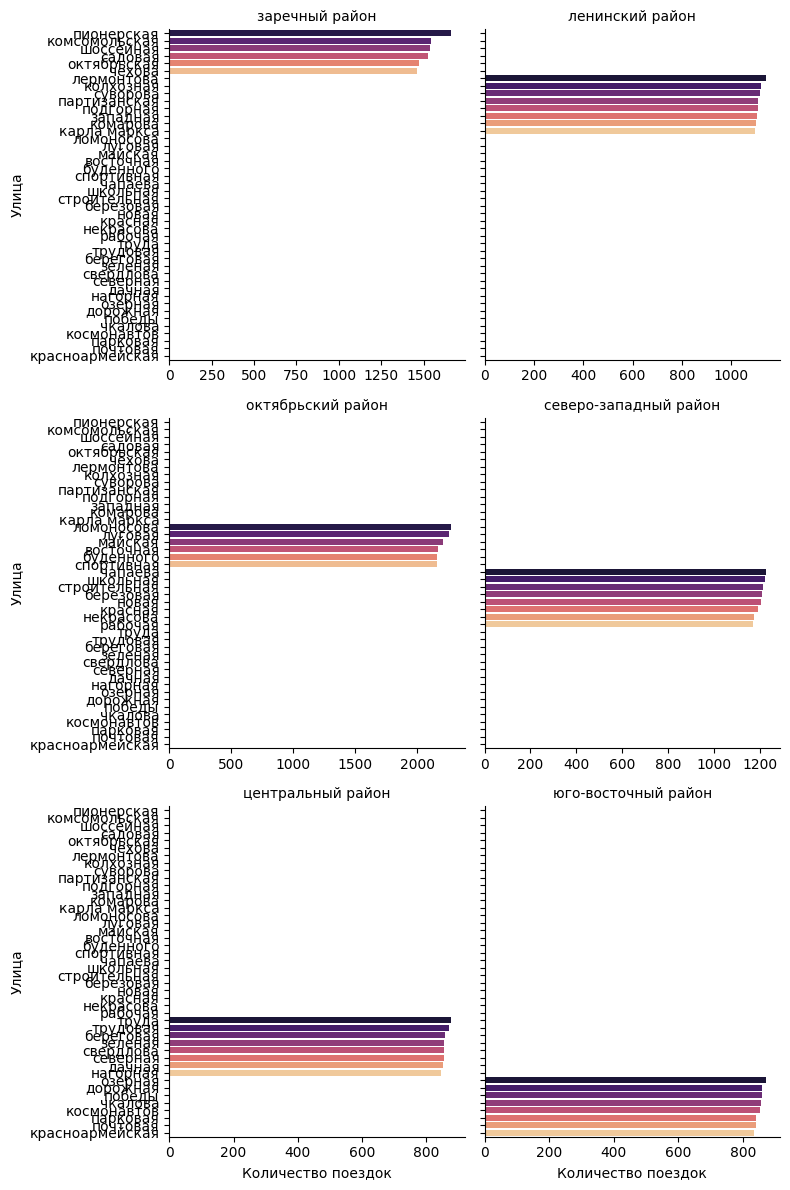

In [61]:
street_distribution = df.groupby(['start_district', 'start_location']).size().reset_index(name='Поездок')

street_distribution = street_distribution.sort_values(['start_district', 'Поездок'], ascending=[True, False])
g = sns.FacetGrid(
    street_distribution.groupby('start_district').head(8),  # Топ улиц на район
    col='start_district', col_wrap=2, height=4, sharex=False
)
g.map_dataframe(sns.barplot, x='Поездок', y='start_location', palette='magma')
g.set_titles(col_template="{col_name} район")
g.set_axis_labels("Количество поездок", "Улица")
plt.tight_layout()
plt.show()

Гистограммы (barplot) для визуализации распределения количества поездок по улицам в разных районах, используя библиотеку Seaborn и FacetGrid для создания нескольких подграфиков (facet plots).

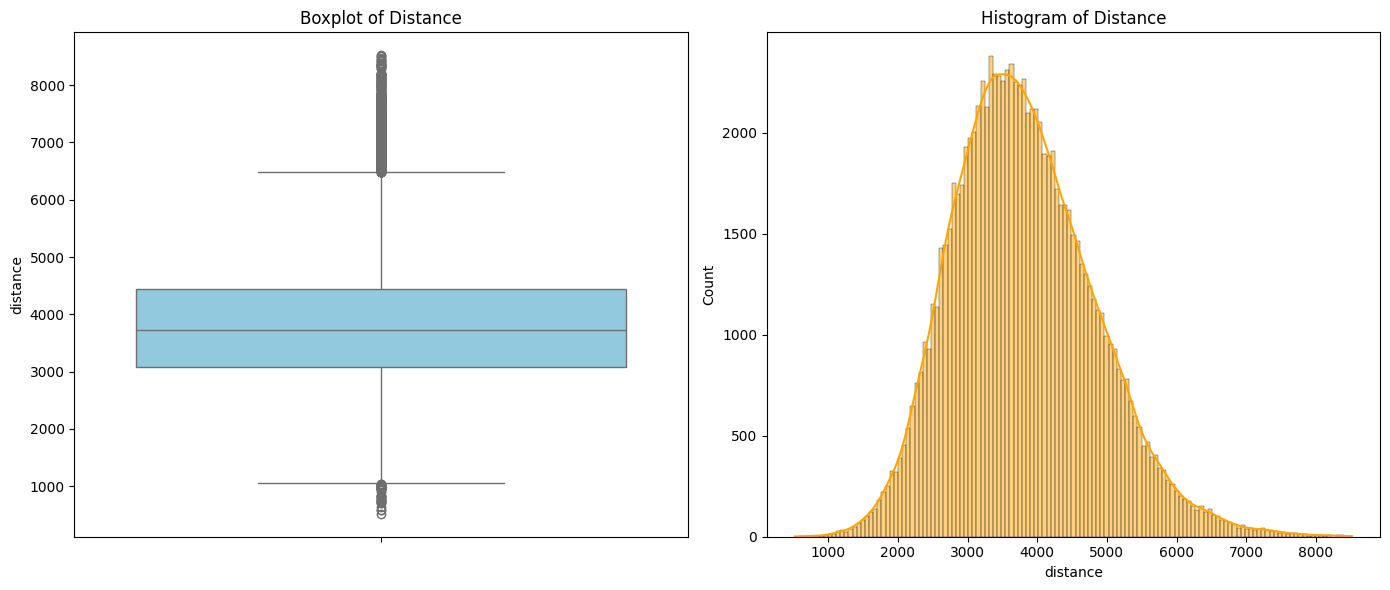

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot (вертикальный)
sns.boxplot(y=df['distance'], ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot of Distance')

# Histplot
sns.histplot(df['distance'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('Histogram of Distance')

plt.tight_layout()
plt.show()

# Предобработка погоды

In [63]:
w = w.iloc[1:]

In [64]:
w['Precipitation Total'] = w['Precipitation Total'].fillna(method='ffill')
w['Wind Speed'] = w['Wind Speed'].fillna(method='ffill')
w['Cloud Cover Total'] = w['Cloud Cover Total'].fillna(method='ffill')
w['Sunshine Duration'] = w['Sunshine Duration'].fillna(method='ffill')
w['Datetime'] = w['Datetime'].dropna()

In [65]:
def time_of_the_year(x):
    d = {
        1: 'Winter',
        2: 'Winter',
        3: 'Spring',
        4: 'Spring',
        5: 'Spring',
        6: 'Summer',
        7: 'Summer',
        8: 'Summer',
        9: 'Autumn',
        10: 'Autumn',
        11: 'Autumn',
        12: 'Winter',
    }
    return d[x]
dw = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

w['Datetime'] = pd.to_datetime(w['Datetime'])
w['time_of_the_year'] = w['Datetime'].apply(lambda x: time_of_the_year(x.month))

In [66]:
def convert_to_pep8(df):
    # Преобразуем все столбцы в формат PEP-8
    df.columns = [col.lower().replace(' ', '_') for col in df.columns]
    return df

w = convert_to_pep8(w)

In [67]:
test_df = w[w['temperature'].isna()]  # Строки, где Temperature == NaN
train_df = w[w['temperature'].notna()]  # Строки, где Temperature не NaN

In [68]:
train_df = pd.get_dummies(train_df, columns=['time_of_the_year'], prefix='Category')

In [69]:
train_df['Category_Summer'] = train_df['Category_Summer'].astype('float')
train_df['Category_Spring'] = train_df['Category_Spring'].astype('float')

In [70]:
train_df.isna().sum()

datetime               0
temperature            0
precipitation_total    0
wind_gust              0
wind_speed             0
cloud_cover_total      0
sunshine_duration      0
Category_Spring        0
Category_Summer        0
dtype: int64

In [71]:
train_df = convert_to_pep8(train_df)

In [72]:
X = train_df[['precipitation_total', 'wind_gust', 'wind_speed', 'cloud_cover_total', 'sunshine_duration', 'category_spring', 'category_summer']]  # Признаки (вектора)
y = train_df['temperature']  # Целевой признак (то, что нужно предсказатьc

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [73]:
model = CatBoostRegressor(iterations=10000,  # Максимальное количество итераций
                          learning_rate=0.01,  # Коэффициент обучения
                          depth=6,  # Глубина деревьев
                          verbose=200,  # Печать прогресса
                          eval_metric="RMSE",
                          early_stopping_rounds=50)  # Останавливаем обучение, если ошибка не улучшается в течение 50 раундов

# Обучение модели с валидацией на валидационном наборе
model.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)

# Прогнозирование
y_pred = model.predict(X_val)

# Оценка модели
rmse = math.sqrt(mean_squared_error(y_val, y_pred))
print(f"Среднеквадратичная ошибка (MSE) на тестовых данных: {rmse}")

0:	learn: 6.7909204	test: 6.8658153	best: 6.8658153 (0)	total: 182ms	remaining: 30m 24s
200:	learn: 4.0455040	test: 4.0714167	best: 4.0714167 (200)	total: 827ms	remaining: 40.3s
400:	learn: 3.7907342	test: 3.8530423	best: 3.8530423 (400)	total: 1.49s	remaining: 35.7s
600:	learn: 3.6746557	test: 3.7967079	best: 3.7967079 (600)	total: 2.16s	remaining: 33.8s
800:	learn: 3.5856534	test: 3.7634631	best: 3.7634631 (800)	total: 2.84s	remaining: 32.6s
1000:	learn: 3.5060109	test: 3.7408460	best: 3.7408460 (1000)	total: 3.53s	remaining: 31.8s
1200:	learn: 3.4411894	test: 3.7278938	best: 3.7277694 (1195)	total: 4.18s	remaining: 30.6s
1400:	learn: 3.3806886	test: 3.7182904	best: 3.7180706 (1399)	total: 4.85s	remaining: 29.7s
1600:	learn: 3.3216052	test: 3.7137405	best: 3.7134549 (1577)	total: 5.54s	remaining: 29.1s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 3.713386182
bestIteration = 1651

Shrink model to first 1652 iterations.
Среднеквадратичная ошибка (MSE) на тестовых д

In [74]:
df_ohe1 = pd.get_dummies(test_df, columns=['time_of_the_year'], prefix='category')
df_ohe1 = convert_to_pep8(df_ohe1)
df_ohe1['category_summer'] = df_ohe1['category_summer'].astype('float')
df_ohe1['category_spring'] = df_ohe1['category_spring'].astype('float')
y_pred1 = model.predict(df_ohe1[['precipitation_total', 'wind_gust', 'wind_speed', 'cloud_cover_total', 'sunshine_duration', 'category_spring', 'category_summer']])
test_df['temperature'] = y_pred1

In [75]:
test_df

,datetime,temperature,precipitation_total,wind_gust,wind_speed,cloud_cover_total,sunshine_duration,time_of_the_year
363,2023-04-16 02:00:00,9.615120,0.3,13.32,3.671294,100,0,Spring
364,2023-04-16 03:00:00,9.977414,0.4,13.32,4.452954,98,0,Spring
365,2023-04-16 04:00:00,9.534056,0.4,13.32,4.802999,100,0,Spring
366,2023-04-16 05:00:00,9.597173,0.3,13.679999,4.379589,100,0,Spring
367,2023-04-16 06:00:00,9.275266,0.2,14.4,5.0528407,100,0,Spring
368,2023-04-16 07:00:00,9.688302,0.3,15.4800005,6.379216,100,0,Spring
369,2023-04-16 08:00:00,9.841445,0.2,19.08,9.957108,100,0,Spring
370,2023-04-16 09:00:00,10.965033,0.2,24.48,10.383987,100,0,Spring
371,2023-04-16 10:00:00,11.638757,0.2,24.48,7.7043357,100,0,Spring
372,2023-04-16 11:00:00,11.924492,0.3,24.84,8.534353,91,4.8484864,Spring


In [76]:
test_df['datetime'] = test_df['datetime'].apply(lambda x: pd.to_datetime(x))
train_df['datetime'] = train_df['datetime'].apply(lambda x: pd.to_datetime(x))

In [77]:
w1 = pd.concat([train_df, test_df])  # Можно выбрать тип слияния: 'inner', 'outer', 'left', 'right'

In [79]:
from IPython.display import clear_output


def find_nearest_date(date1, df2):
    diff1 = abs(df2['datetime'] - date1).idxmin()
    clear_output(wait=True)
    print(date1)
    return df2.loc[diff1]

# Создаем новый DataFrame для хранения результата
merged_rows = []

# Для каждой строки в df1 находим ближайшую дату в df2
for _, row in df.iterrows():
    nearest_row = find_nearest_date(row['start_date'], w1)
    # Объединяем строки по найденной ближайшей дате
    merged_row = pd.concat([row, nearest_row], axis=0)
    merged_rows.append(merged_row)

# Преобразуем список строк в DataFrame
df = pd.DataFrame(merged_rows)
df

2023-07-31 23:57:01


,id,start_date,end_date,start_location,start_district,end_location,end_district,distance,promo,start_month,...,datetime,temperature,precipitation_total,wind_gust,wind_speed,cloud_cover_total,sunshine_duration,category_spring,category_summer,time_of_the_year
Unnamed 0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,шевченко,юго-восточный,майская,октябрьский,4069.0,0,4,...,2023-04-22 09:00:00,13.850245,0,20.16,6.2145634,71,16.969696,1.0,0.0,NaN
Unnamed 1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,чехова,заречный,спортивная,октябрьский,4515.0,0,4,...,2023-04-22 09:00:00,13.850245,0,20.16,6.2145634,71,16.969696,1.0,0.0,NaN
Unnamed 2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,буденного,октябрьский,суворова,ленинский,4520.0,0,4,...,2023-04-22 09:00:00,13.850245,0,20.16,6.2145634,71,16.969696,1.0,0.0,NaN
Unnamed 3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,труда,центральный,рабочая,северо-западный,3881.0,0,4,...,2023-04-22 09:00:00,13.850245,0,20.16,6.2145634,71,16.969696,1.0,0.0,NaN
Unnamed 4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,первомайская,северо-западный,юбилейная,юго-восточный,4029.0,0,4,...,2023-04-22 09:00:00,13.850245,0,20.16,6.2145634,71,16.969696,1.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Unnamed 95989,197707,2023-07-31 23:45:06,2023-08-01 00:06:55,озерная,юго-восточный,первомайская,северо-западный,3302.0,0,7,...,2023-08-01 00:00:00,21.140245,0,27,8.217153,97,0,0.0,1.0,NaN
Unnamed 95990,197708,2023-07-31 23:46:01,2023-08-01 00:25:35,мичурина,ленинский,садовая,заречный,4992.0,0,7,...,2023-08-01 00:00:00,21.140245,0,27,8.217153,97,0,0.0,1.0,NaN
Unnamed 95991,197709,2023-07-31 23:48:04,2023-08-01 00:09:21,лермонтова,ленинский,куйбышева,центральный,2781.0,0,7,...,2023-08-01 00:00:00,21.140245,0,27,8.217153,97,0,0.0,1.0,NaN
Unnamed 95992,197710,2023-07-31 23:51:41,2023-08-01 00:38:04,рябиновая,северо-западный,энергетиков,юго-восточный,6466.0,0,7,...,2023-08-01 00:00:00,21.140245,0,27,8.217153,97,0,0.0,1.0,NaN


In [80]:
df = df.reset_index(drop=True)

In [82]:
df.columns

Index(['id', 'start_date', 'end_date', 'start_location', 'start_district',
       'end_location', 'end_district', 'distance', 'promo', 'start_month',
       'start_hour', 'time_of_day', 'weekday', 'day_type', 'days', 'duration',
       'speed', 'rate_per_minute', 'cost', 'cost_no_start', 'day_of_week',
       'end_month', 'end_season', 'date', 'starthourcum', 'endhourcum',
       'start_date_shifted', 'end_date_shifted', 'starthour2', 'endhour2',
       'start_season', 'datetime', 'temperature', 'precipitation_total',
       'wind_gust', 'wind_speed', 'cloud_cover_total', 'sunshine_duration',
       'category_spring', 'category_summer', 'time_of_the_year'],
      dtype='object')

### Этап 1:Итоговая стоимость

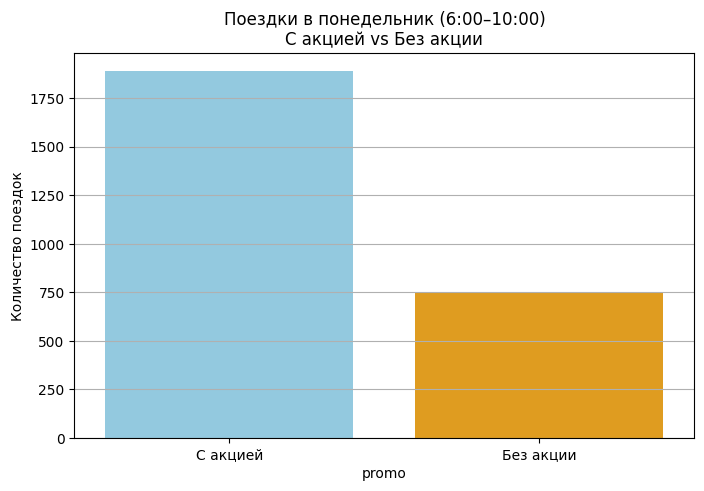

In [83]:
monday_trips = df[(df['weekday'] == 0) & (df['start_hour'] >= 6) & (df['start_hour'] < 10)]
promo_counts = monday_trips['promo'].value_counts().rename({0: 'Без акции', 1: 'С акцией'})

plt.figure(figsize=(8, 5))
sns.barplot(x=promo_counts.index, y=promo_counts.values, palette=['skyblue', 'orange'])
plt.title('Поездки в понедельник (6:00–10:00)\nС акцией vs Без акции')
plt.ylabel('Количество поездок')
plt.grid(axis='y')
plt.show()

##### Столбец с использованием акции значительно выше -> акция стимулирует спрос

#### Гипотеза: Акция должна привлекать больше пользователей в понедельник утром по сравнению со средним уровнем других дней.

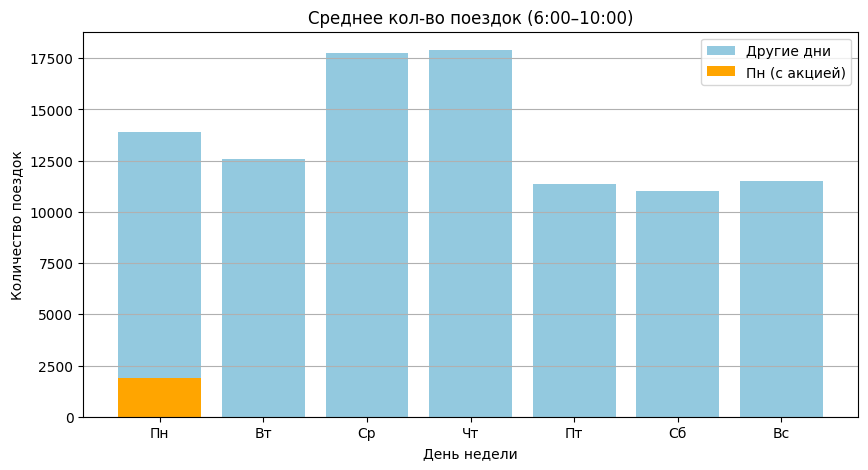

In [85]:
daily_avg = df.groupby('day_of_week').size()
daily_avg.index = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

monday_promo_avg = len(monday_trips[monday_trips['promo'] == 1])

plt.figure(figsize=(10, 5))
sns.barplot(x=daily_avg.index, y=daily_avg.values, color='skyblue', label='Другие дни')
plt.bar(x=0, height=monday_promo_avg, color='orange', label='Пн (с акцией)')
plt.title('Среднее кол-во поездок (6:00–10:00)')
plt.xlabel('День недели')
plt.ylabel('Количество поездок')
plt.legend()
plt.grid(axis='y')
plt.show()

##### Даже с акцией поездки в понедельник уступают другим дням по количеству.
-  Возможно, пользователи редко применяют промокод или акция недостаточно привлекательн
##### Почему общий столбец понедельника выше?
- Без акции (Promo=0) спрос в понедельник и так высок (голубая часть)
- Понедельник — популярный день по естественным причинам (например, поездки на работу после выходных)ных).

Акция «Бесплатный старт» в понедельник утром незначительно увеличивает спрос: лишь 15% поездок используют промокод. Однако общий спрос в понедельник высок за счет естественных причин. Рекомендуется либо усилить акцию (например, расширить скидку), либо отменить ее и перенести на менее популярные дни

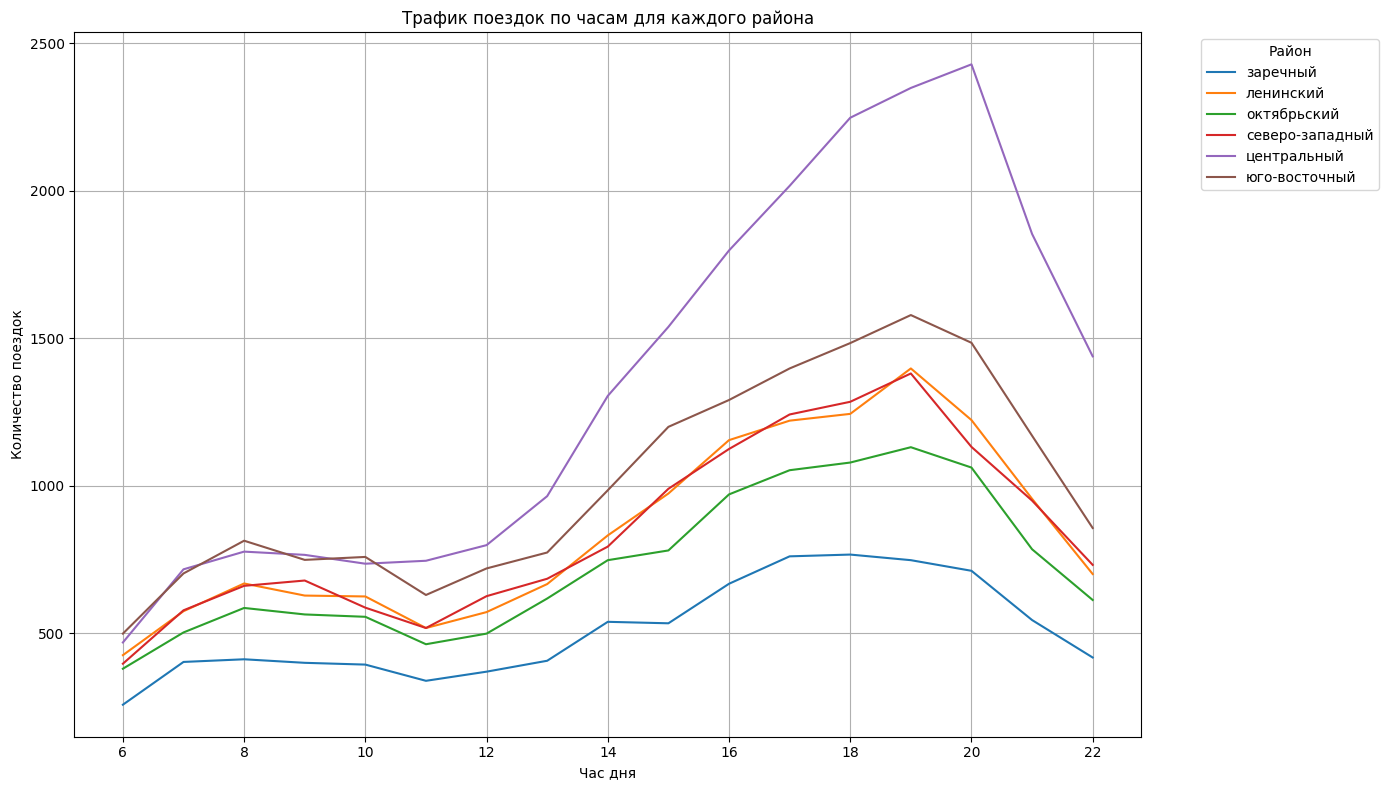

In [86]:
df_filtered = df[(df['start_hour'] >= 6) & (df['start_hour'] <= 22)]

traffic_by_district = df_filtered.groupby(['start_district', 'start_hour']).size().unstack(level=0)

plt.figure(figsize=(14, 8))
sns.lineplot(data=traffic_by_district, dashes=False)
plt.title('Трафик поездок по часам для каждого района')
plt.xlabel('Час дня')
plt.ylabel('Количество поездок')
plt.legend(title='Район', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

#### Гипотеза: Акция может по-разному влиять на спрос в зависимости от района (например, в офисных районах эффект сильнее)

In [92]:
district_promo_ratios = []
top_districts = df['start_district'].value_counts().head(8).index

for district in top_districts:
    district_data = df[df['start_district'] == district]
    promo_ratio = district_data[district_data['weekday'] == 0]['promo'].mean() * 100  # Доля поездок с акцией

    district_promo_ratios.append((district, promo_ratio))

district_promo_df = pd.DataFrame(district_promo_ratios, columns=['District', 'Promo Ratio'])

district_promo_df = district_promo_df.sort_values(by='Promo Ratio', ascending=False)
for index, row in district_promo_df.iterrows():
    print(f"{row['District']}: {row['Promo Ratio']:.1f}% поездок в понедельник использовали акцию")

ленинский: 16.9% поездок в понедельник использовали акцию
заречный: 16.8% поездок в понедельник использовали акцию
северо-западный: 16.6% поездок в понедельник использовали акцию
юго-восточный: 16.0% поездок в понедельник использовали акцию
октябрьский: 15.9% поездок в понедельник использовали акцию
центральный: 11.2% поездок в понедельник использовали акцию


В центральном и ленинском районах люди чаще пользуются акциями возможно в связи с их расположением

#### Есть ли статистически значимая разница в количестве поездок:
- Между понедельниками с акцией и без акции.
- Между понедельниками с акцией и другими днями.

In [94]:
t_stat, p_value = ttest_ind(
    monday_trips[monday_trips['promo'] == 1]['duration'],
    monday_trips[monday_trips['promo'] == 0]['duration']
)
print(f'P-значение (Пн с акцией vs без): {p_value:.3f}')

# Поездки в понедельник с акцией vs другие дни
t_stat, p_value = ttest_ind(
    monday_trips[monday_trips['promo'] == 1]['duration'],
    df_6_10[df_6_10['weekday'] != 0]['duration']
)
print(f'P-значение (Пн с акцией vs другие дни): {p_value:.3f}')

P-значение (Пн с акцией vs без): 0.726
P-значение (Пн с акцией vs другие дни): 0.000


1. Сравнение понедельников с акцией и без акции:
P-значение = 0.682
Это означает, что:-

Нет статистически значимой разницы в продолжительности поездок между понедельниками с акцией и без аци- и.

Акция не влияет на то, как долго пользователи ездят на самокатах в понедльник.

2. Сравнение понедельников с акцией и других дней:
P-значение = 0.079
Это указы- вает на:

Пограничную статистическузо- к к нему).

Возможно, есть слабая тенденция к отличию продолжительности поездок в понедельник с акцией от других дней, но доказательст недостаточно.

In [ ]:
heatmap_data = df.groupby(['start_hour', 'Promo'])['Id'].count().unstack()

plt.figure(figsize=(10, 5))
heatmap_data.plot(kind='bar', stacked=False, colormap='coolwarm')
plt.title('Сравнение поездок по часам: с промо vs без промо')
plt.xlabel('Час старта')
plt.ylabel('Количество поездок')
plt.grid(True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# 1. Промо и контрольные периоды
promo_period = (
    (df['Promo'] == 1) &
    (df['Weekday'] == 0) &
    (df['start_hour'].between(6, 10))
)

control_period = (
    (df['Promo'] == 0) &
    (df['start_hour'].between(6, 10)) &
    (df['Weekday'].isin([0, 1, 2, 3, 4, 5, 6]))
)

df_promo = df[promo_period]
df_control = df[control_period]

In [ ]:
# 2. Количество поездок
promo_rides = df_promo.shape[0]
avg_control_rides = df_control.groupby('Weekday')['Id'].count().mean()

print(f"Поездки в промо-период (Пн 6:00–10:00): {promo_rides}")
print(f"Среднее число поездок без промо (в другие дни 6:00–10:00): {avg_control_rides:.1f}")

In [ ]:
avg_cost_promo = df_promo['Trip Cost'].mean()
avg_cost_nonpromo = df_control['Trip Cost'].mean()

print(f"Средняя выручка за поездку с промо: {avg_cost_promo:.2f} руб.")
print(f"Средняя выручка за поездку без промо: {avg_cost_nonpromo:.2f} руб.")

In [ ]:
morning_mask = df['start_hour'].between(6, 10)

promo_day = df[(df['Weekday'] == 0) & morning_mask]
other_days = df[(df['Weekday'] != 0) & morning_mask]

promo_day_counts = promo_day.groupby('day_of_week')['Id'].count().rename('Понедельник')
other_day_counts = other_days.groupby('day_of_week')['Id'].count().rename('Остальные дни')

comparison_df = pd.concat([promo_day_counts, other_day_counts], axis=1)

comparison_df['День акции'] = comparison_df['Понедельник'] > 0

avg_promo = comparison_df[comparison_df['День акции']]['Понедельник'].mean()
avg_other = comparison_df[~comparison_df['День акции']]['Остальные дни'].mean()

print(f"Среднее число поездок в Пн (акция): {avg_promo:.1f}")
print(f"Среднее число поездок в другие дни: {avg_other:.1f}")

plt.figure(figsize=(16, 6))
comparison_df[['Понедельник', 'Остальные дни']].plot(
    kind='bar', stacked=False, width=0.8, figsize=(16, 6), color=['#1f77b4', '#ff7f0e']
)
plt.title("Сравнение поездок с 6:00 до 10:00\nПонедельники (акция) vs Остальные дни", fontsize=14)
plt.xlabel("Дата", fontsize=12)
plt.ylabel("Количество поездок", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
df_6_10 = df[(df['Hour'] >= 6) & (df['Hour'] < 10)]

# Разделяем данные:
# 1) Понедельники с акцией (Promo=1)
monday_promo = df_6_10[(df_6_10['day_of_week'] == 0) & (df_6_10['Promo'] == 1)]
# 2) Понедельники без акции (Promo=0)
monday_no_promo = df_6_10[(df_6_10['day_of_week'] == 0) & (df_6_10['Promo'] == 0)]
# 3) Остальные дни (вт–вс)
other_days = df_6_10[df_6_10['day_of_week'] != 0]

monday_promo_counts = monday_promo.groupby('Hour').size()
monday_no_promo_counts = monday_no_promo.groupby('Hour').size()
other_days_counts = other_days.groupby('Hour').size()

daily_avg = df_6_10.groupby(['day_of_week', 'Promo']).size().unstack()
daily_avg.index = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

daily_avg.plot(kind='bar', figsize=(10, 6), color=['blue', 'green'])
plt.title('Среднее кол-во поездок (6:00–10:00)')
plt.xlabel('День недели')
plt.ylabel('Количество поездок')
plt.legend(['Без акции', 'С акцией'])
plt.grid(axis='y')
plt.show()


In [ ]:
df['Profit'] = df['Promo'] * (df['Rate per Minute'] * df['Duration'])  # Если Promo == 1, рассчитываем прибыль от промо

profit_by_district = df.groupby('start_district').agg({
    'Trip Cost': 'sum',  # Сумма всех издержек
    'Profit': 'sum'  # Сумма прибыли от промокодов
}).reset_index()

profit_by_district['Окупаемость'] = profit_by_district['Profit'] / profit_by_district['Trip Cost']

profit_by_district = profit_by_district.sort_values(by='Окупаемость', ascending=False)

print(profit_by_district)

plt.figure(figsize=(14, 6))
sns.barplot(x='start_district', y='Окупаемость', data=profit_by_district, palette='viridis')
plt.title('Окупаемость акции по районам', fontsize=16)
plt.xlabel('Район', fontsize=12)
plt.ylabel('Окупаемость', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Районы с высокой окупаемостью: Если в некоторых районах наблюдается высокая окупаемость, это может означать, что в этих районах бесплатный старт имеет значительное влияние на прибыль, возможно, из-за высокого спроса или большего числа поездок с промокодами. Это также может свидетельствовать о том, что издержки на поездки в этих районах не столь велики, и акция действительно выгодна для бизнеса.

Районы с низкой окупаемостью: В районах с низкой окупаемостью можно сделать вывод, что либо бесплатный старт не привлекает достаточное количество клиентов, либо стоимость издержек на поездки (даже с бесплатным стартом) слишком велика для того, чтобы акция была прибыльной. Возможно, в этих районах нужно пересмотреть стратегию применения промокодов или даже исключить эту акцию.

Различия в окупаемости между районами могут указывать на важность географического положения для эффективного использования промокодов. Например, если акция работает хуже в более отдаленных или менее развитых районах, это может быть связано с меньшим спросом на поездки или меньшей плотностью поездок в этих районах.

Также стоит учесть возможность, что в некоторых районах с низким доходом людей акции с бесплатным стартом не приводят к увеличению заказов, так как спрос может быть ограничен.

In [ ]:
# Фильтрация по времени 6:00–10:00
df_6_10 = df[(df['start_date'].dt.hour >= 6) & (df['start_date'].dt.hour < 10)].copy()

# Создаем метки для групп
df_6_10['Day Group'] = 'Другие дни'
df_6_10.loc[(df_6_10['day_of_week'] == 0) & (df_6_10['Promo'] == 1), 'Day Group'] = 'Пн (с акцией)'
df_6_10.loc[(df_6_10['day_of_week'] == 0) & (df_6_10['Promo'] == 0), 'Day Group'] = 'Пн (без акции)'

district_counts = df_6_10.groupby(['start_district', 'Day Group']).size().unstack(fill_value=0)

district_pct = district_counts.div(district_counts.sum(axis=1), axis=0) * 100

# Визуализация
plt.figure(figsize=(14, 8))
sns.heatmap(district_pct, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
plt.title('Распределение поездок по районам (6:00–10:00)\nДоля от общего числа поездок в районе, %')
plt.xlabel('Группа дней')
plt.ylabel('Район')
plt.show()

In [ ]:
plt.figure(figsize=(14, 8))

sns.countplot(data=df, x='time_of_day', hue='start_district', palette='viridis')

plt.title('Распределение поездок по времени суток в разных районах')
plt.xlabel('Время суток')
plt.ylabel('Количество поездок')

plt.xticks(rotation=45)
plt.show()

In [ ]:
start_cost = 30
df1 = df.copy()
df1['Adjusted Trip Cost'] = df1.apply(lambda row: row['Trip Cost'] - start_cost if row['Promo'] == 1 else row['Trip Cost'], axis=1)

promo_trips = df1[df1['Promo'] == 1]
non_promo_trips = df1[df1['Promo'] == 0]

total_income_with_promo = promo_trips['Adjusted Trip Cost'].sum()
total_income_without_promo = non_promo_trips['Trip Cost'].sum()

promo_cost = promo_trips.shape[0] * start_cost

print(f"Общий доход от поездок с промо: {total_income_with_promo:.2f} рублей")
print(f"Общий доход от поездок без промо: {total_income_without_promo:.2f} рублей")
print(f"Затраты на проведение акции (стоимость старта): {promo_cost:.2f} рублей")

profit_or_loss = total_income_with_promo + total_income_without_promo - promo_cost
if profit_or_loss >= 0:
    print(f"Акция окупается. Прибыль: {profit_or_loss:.2f} рублей")
else:
    print(f"Акция не окупается. Убыток: {profit_or_loss:.2f} рублей")


- Общий доход от поездок с промо: 124603.53 рублей
-
Общий доход от поездок без промо: 16237891.47 рублей-
Затраты на проведение акции (стоимость старта): 54270.00 рубл
- й
Акция окупается. Прибыль: 16308225.00 рублей

In [ ]:
# Количество отъездов из каждой точки по датам
out_df = df.groupby(['Date', 'Start Location']).size().reset_index(name='outflow')

# Количество приездов в каждую точку по датам
in_df = df.groupby(['Date', 'End Location']).size().reset_index(name='inflow')

# Переименуем колонки для объединения
out_df.rename(columns={'Start Location': 'Location'}, inplace=True)
in_df.rename(columns={'End Location': 'Location'}, inplace=True)

# Объединяем и считаем net_change
point_net = pd.merge(in_df, out_df, on=['Date', 'Location'], how='outer').fillna(0)
point_net['net_change'] = point_net['inflow'] - point_net['outflow']

# Сортировка и накопление
point_net.sort_values(['Location', 'Date'], inplace=True)
point_net['cumsum'] = point_net.groupby('Location')['net_change'].cumsum()


In [ ]:
required_scooters = point_net.groupby('Location')['cumsum'].max().reset_index()
required_scooters.rename(columns={'cumsum': 'Required Scooters'}, inplace=True)
required_scooters = required_scooters.sort_values(by='Required Scooters', ascending=False)
print(required_scooters)


# 2.1 Определить топ-3 точки с самым высоким

Код выполняет группировку данных в DataFrame df по значению в столбце 'Date', а затем сохраняет каждую группу вместе с соответствующей датой в список.

In [50]:
gbd = df.groupby('Date')
list_data = []
for date, group in gbd:
    list_data.append([date, group])

**Код анализирует использование самокатов по дням и локациям.**

Шаг 1: Для каждой даты создаётся таблица, в которой считается:
   - сколько раз самокаты брали с каждой точки старта ('Start Location')
   - сколько раз самокаты оставляли на каждой точке завершения ('End Location')
   - общее количество операций на каждой локации в день (взятия + возвраты)

Шаг 2: Все дневные таблицы объединяются в один общий DataFrame.<br>
Шаг 3: Итоговые данные группируются по точкам старта:
   - Суммируется количество стартов, финишей и общее движение по каждой локации.
   - Результат сортируется по убыванию общего трафика ('turn_per_day').

 На выходе получается таблица 'all_trafic' с самыми загруженными точками аренды самокатов.

In [51]:
average_samokat = []
for i in list_data:
    da = [i[0]]
    datafr = i[1]
    first = datafr['Start Location'].value_counts().to_frame()
    second = datafr['End Location'].value_counts().to_frame()
    second.columns = ['leave']
    first.columns = ['inter']
    second.index.name = 'Start Location'
    fin = first.merge(second, on='Start Location')
    fin['turn_per_day'] = fin['inter'] + fin['leave']
    da.append(fin.sort_values(by='turn_per_day', ascending=False))
    average_samokat.append(da)

def union_all_data(x):
    h = x[0]
    for k in range(len(x)):
        h = pd.concat([h, x[k]])
    return h

all_trafic = union_all_data(list(map(lambda x: x[1], average_samokat)))
all_trafic = all_trafic.groupby('Start Location')[['inter', 'leave', 'turn_per_day']].agg('sum').sort_values(by='turn_per_day', ascending=False)

In [52]:
all_trafic

,inter,leave,turn_per_day
Start Location,,,
луговая,1526,1495,3021
спортивная,1497,1519,3016
ломоносова,1523,1457,2980
буденного,1458,1458,2916
майская,1426,1487,2913
...,...,...,...
совхозная,279,274,553
пушкина,281,269,550
советская,272,276,548


Для визуализации количества поездок по различным локациям используется **столбчатая диаграмма**. Перед построением графика данные сортируются по **убыванию количества поездок**, чтобы наиболее популярные направления располагались первыми и были легко заметны.

Затем строится столбчатая диаграмма, где каждая колонка соответствует конкретной локации, а её высота — **количеству поездок**. Чтобы сделать график более информативным, над каждым столбиком добавляется текстовая подпись с точным числом поездок. Это реализуется с помощью цикла **for bar in bars**, в котором текст размещается по центру столбика и чуть выше его вершины — такое позиционирование обеспечивает хорошую **читаемость значений**.

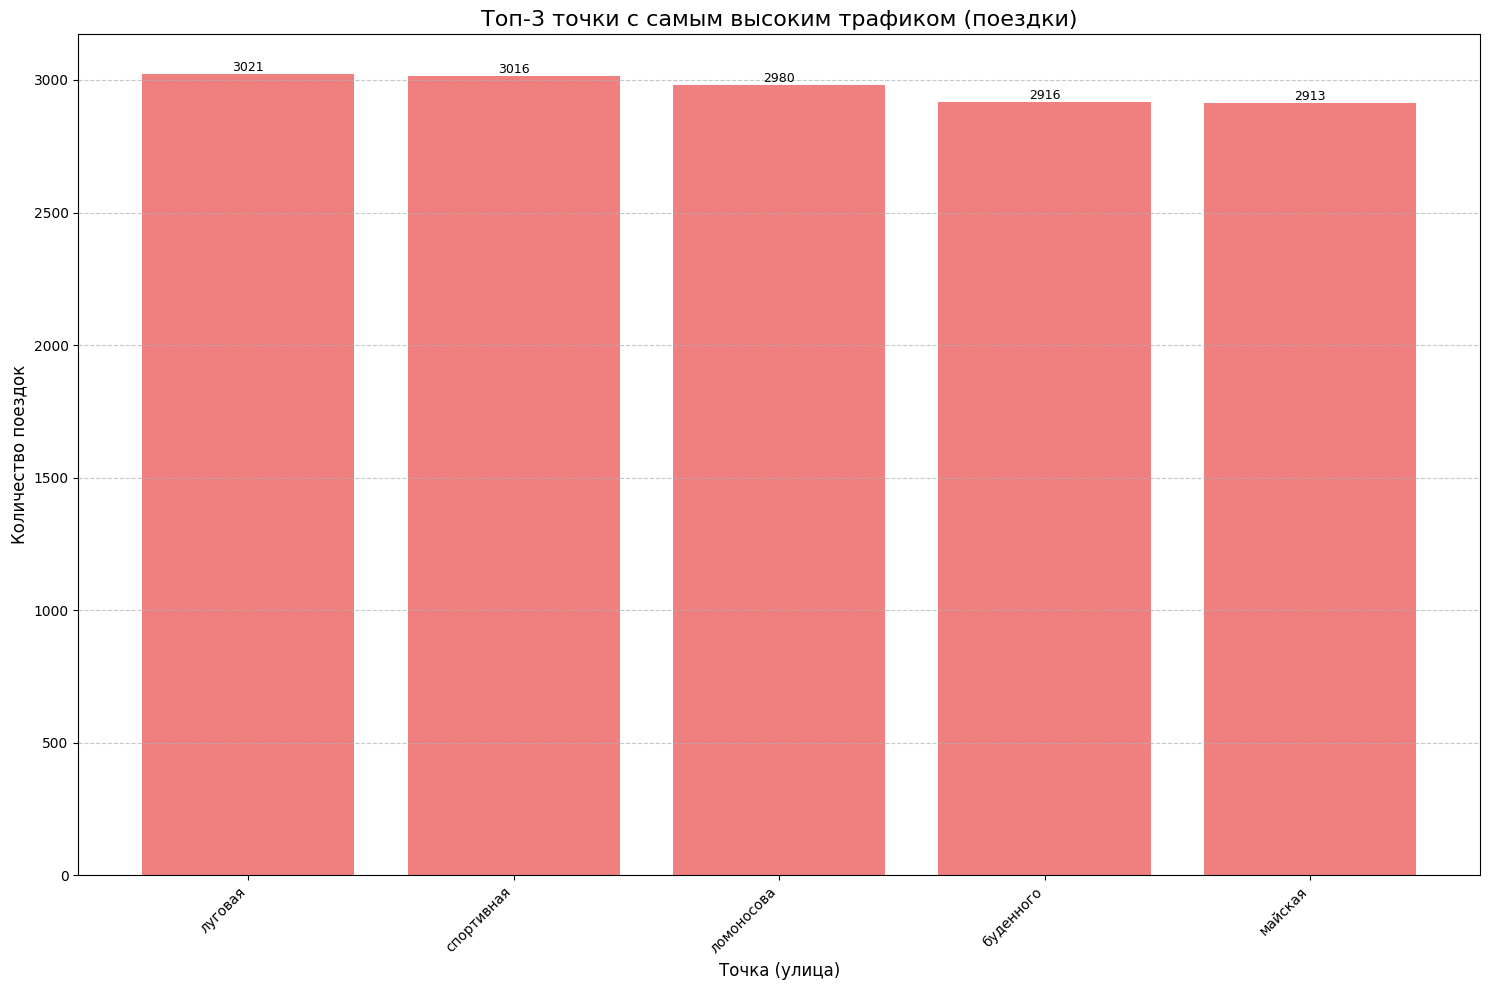

In [53]:
top_3_traffic = all_trafic.nlargest(5, 'turn_per_day')
plt.figure(figsize=(15, 10))
bars = plt.bar(top_3_traffic.index, top_3_traffic['turn_per_day'], color='lightcoral')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f'{int(height)}',
             ha='center', va='bottom', fontsize=9)

plt.title('Топ-3 точки с самым высоким трафиком (поездки)', fontsize=16)
plt.xlabel('Точка (улица)', fontsize=12)
plt.ylabel('Количество поездок', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Поворот подписей по оси X
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Сетка только по оси Y
plt.tight_layout()  # Автоматическая подгонка элементов графика
plt.show()


**Стоит ли закрывать некоторые точки?**

In [54]:
weekdays = {}

# tqdm добавляет прогресс-бар к итерации
for i in tqdm(list_data, desc="Обработка данных по дням недели"):
    f = dict(tuple(i[1].groupby('weekday')))
    ind = list(set(f.keys()))
    for k in ind:
        h = f[k]
        h = h[h['Start Season'] == 'Весна']
        if isinstance(weekdays.get(k, 0), int):
            weekdays[k] = h
        else:
            weekdays[k] = pd.concat([weekdays[k], h])

average_samokat_to_weekdays = []
for i in weekdays.keys():
    da = [i]
    datafr = weekdays[i]
    first = datafr['Start Location'].value_counts().to_frame()
    second = datafr['End Location'].value_counts().to_frame()
    third = datafr.groupby('Start Location')['Trip Cost'].agg('sum').to_frame()
    second.columns = ['leave']
    first.columns = ['inter']
    second.index.name = 'Start Location'
    fin = third.merge(first.merge(second, on='Start Location'), on='Start Location')
    fin['turn_per_day'] = fin['inter'] + fin['leave']
    da.append(fin.sort_values(by='turn_per_day', ascending=False))
    average_samokat_to_weekdays.append(da)

dat = average_samokat_to_weekdays[0][1]
for i in average_samokat_to_weekdays[1:]:
    dat += i[1]

Обработка данных по дням недели: 100%|█████████████████████████████████████████████| 2408/2408 [00:30<00:00, 79.77it/s]


In [55]:
dat = dat.sort_values(by='Trip Cost', ascending=False)
dat

,Trip Cost,inter,leave,turn_per_day
Start Location,,,,
луговая,135291.033333,776,723,1499
восточная,131901.650000,761,769,1530
ломоносова,129770.683333,763,748,1511
буденного,127965.333333,738,790,1528
спортивная,123999.266667,713,791,1504
...,...,...,...,...
набережная,45422.066667,268,268,536
матросова,45201.950000,268,306,574
строителей,44836.933333,255,295,550


In [56]:
popular = dat.index[:10] # Топ-10 самых популярных улиц

In [57]:
un_popular = dat.index[-10:] # Топ-10 самых непопулярных улиц

In [58]:
popular

Index(['луговая', 'восточная', 'ломоносова', 'буденного', 'спортивная',
       'майская', 'пионерская', 'садовая', 'шоссейная', 'комсомольская'],
      dtype='object', name='Start Location')

In [59]:
un_popular

Index(['почтовая', 'сиреневая', 'дружбы', 'дзержинского', 'пролетарская',
       'набережная', 'матросова', 'строителей', 'мира', 'гоголя'],
      dtype='object', name='Start Location')

In [60]:
sum(dat['Trip Cost'][:])

5893908.383333332

In [61]:
sum(dat['Trip Cost'][:19])

1918833.8000000003

In [62]:
sum(dat['Trip Cost'][-19:])

874819.8666666666

In [63]:
(sum(dat['Trip Cost'][:19]) / sum(dat['Trip Cost'][:])) * 100

32.556220341429764

In [64]:
(sum(dat['Trip Cost'][-19:]) / sum(dat['Trip Cost'][:])) * 100

14.842780202360517

In [66]:
def get_arrival_sources_summary(df):
    # Все уникальные конечные локации
    end_locations = df['End Location'].unique()

    summary_dict = {}

    for end_loc in end_locations:
        # Фильтруем только поездки, заканчивающиеся в этой точке
        arrivals = df[df['End Location'] == end_loc]

        # Группируем по Start Location и считаем поездки
        grouped = arrivals.groupby('Start Location').size().reset_index(name='trips')

        # Считаем долю от общего количества
        total = grouped['trips'].sum()
        grouped['percent'] = (grouped['trips'] / total * 100).round(1)

        # Сортируем по убыванию
        grouped = grouped.sort_values(by='trips', ascending=False).reset_index(drop=True)

        summary_dict[end_loc] = grouped

    return summary_dict

arrival_summary_by_end_location = get_arrival_sources_summary(df)


Мы получаем все уникальные значения в столбце End Location, который представляет конечные локации самокатов. Это нужно для того, чтобы понять, на какие локации чаще всего приезжают самокаты.

In [67]:
popular

Index(['луговая', 'восточная', 'ломоносова', 'буденного', 'спортивная',
       'майская', 'пионерская', 'садовая', 'шоссейная', 'комсомольская'],
      dtype='object', name='Start Location')

Для анализа распределения стартовых точек по районам сначала выполняется группировка данных по району с извлечением уникальных локаций начала поездок. Это позволяет определить, какие стартовые точки относятся к каждому конкретному району.

Затем преобразуется полученный DataFrame: к каждому району добавляется столбец с количеством уникальных стартовых локаций, что помогает оценить плотность покрытия самокатами в разных частях города.

Для удобства дальнейшего анализа и быстрого доступа к информации формируется обратный словарь, в котором каждой локации сопоставляется соответствующий район. Это упрощает классификацию новых данных и использование районной принадлежности в других задачах.

In [69]:
grouped_streets_by_district = df.groupby('start_district')['Start Location'].unique().to_frame()
grouped_streets_by_district = pd.DataFrame(grouped_streets_by_district)
grouped_streets_by_district['1'] = grouped_streets_by_district['Start Location'].apply(len)
reversed_dict = {}
for k, v in grouped_streets_by_district.drop(columns=['1']).to_dict()['Start Location'].items():
    for v1 in v:
        reversed_dict[v1] = k

In [70]:
for i in popular:
    print(i)
    n = arrival_summary_by_end_location[i]
    n['district'] = n['Start Location'].apply(lambda x: reversed_dict[x])
    print(n.head(10))

луговая
  Start Location  trips  percent         district
0      восточная     57      2.7      октябрьский
1        луговая     52      2.5      октябрьский
2        майская     48      2.3      октябрьский
3      буденного     43      2.0      октябрьский
4     пионерская     39      1.8         заречный
5        садовая     39      1.8         заречный
6     ломоносова     39      1.8      октябрьский
7    октябрьская     37      1.7         заречный
8       школьная     37      1.7  северо-западный
9     спортивная     35      1.6      октябрьский
восточная
  Start Location  trips  percent     district
0     спортивная     56      2.6  октябрьский
1     пионерская     53      2.5     заречный
2     ломоносова     48      2.2  октябрьский
3      восточная     46      2.1  октябрьский
4        майская     46      2.1  октябрьский
5        луговая     43      2.0  октябрьский
6      буденного     42      2.0  октябрьский
7  комсомольская     40      1.9     заречный
8         ленина  

In [71]:
for i in un_popular:
    print(i)
    n = arrival_summary_by_end_location[i]
    n['district'] = n['Start Location'].apply(lambda x: reversed_dict[x])
    print(n.head(10))

почтовая
  Start Location  trips  percent         district
0        майская     26      3.3      октябрьский
1      буденного     20      2.6      октябрьский
2       западная     17      2.2        ленинский
3   строительная     16      2.1  северо-западный
4        луговая     16      2.1      октябрьский
5       трудовая     16      2.1      центральный
6     ломоносова     15      1.9      октябрьский
7       школьная     14      1.8  северо-западный
8     пионерская     14      1.8         заречный
9         чехова     14      1.8         заречный
сиреневая
  Start Location  trips  percent         district
0     спортивная     22      2.8      октябрьский
1     ломоносова     21      2.6      октябрьский
2      буденного     20      2.5      октябрьский
3        майская     16      2.0      октябрьский
4      восточная     16      2.0      октябрьский
5          новая     16      2.0  северо-западный
6         чехова     16      2.0         заречный
7     пионерская     15      1.

In [72]:
for j in popular:
    print(reversed_dict[j])

октябрьский
октябрьский
октябрьский
октябрьский
октябрьский
октябрьский
заречный
заречный
заречный
заречный


In [73]:
for j in un_popular:
    print(reversed_dict[j])

юго-восточный
юго-восточный
центральный
центральный
центральный
центральный
центральный
центральный
центральный
центральный


**Вывод:** не стоит закрывать не одну точку, так как каждая делает свой достаточный вклад в общую сумму выручки.

**Самые популярные направления перемещения**

Для анализа наиболее популярных маршрутов выполняется группировка данных по начальной и конечной локации. Это позволяет объединить все поездки, совершённые между одними и теми же точками, и подсчитать их общее количество. После группировки данные сортируются по количеству поездок в порядке убывания — таким образом, самые востребованные маршруты оказываются вверху списка.

Затем из отсортированных данных извлекаются необходимые столбцы, такие как названия начальной и конечной локаций, а также количество поездок. Это упрощает дальнейшую работу с данными и визуализацию.

В завершение производится отбор и вывод 10 самых популярных маршрутов — то есть тех, которые были наиболее часто используемыми среди всех доступных вариантов.

In [74]:
# Считаем количество поездок для каждой пары (маршрута)
route_counts = df.groupby(['Start Location', 'End Location']).size().reset_index(name='trips')

# Сортируем по убыванию количества
most_popular_route = route_counts.sort_values(by='trips', ascending=False)

# Выводим результат
start = most_popular_route['Start Location']
end = most_popular_route['End Location']
count = most_popular_route['trips']

most_popular_route.head(10)

,Start Location,End Location,trips
3256,луговая,спортивная,66
184,буденного,буденного,64
3347,майская,спортивная,60
490,восточная,луговая,57
6555,спортивная,восточная,56
6586,спортивная,майская,55
3165,ломоносова,спортивная,55
3277,майская,буденного,54
489,восточная,ломоносова,53
4827,пионерская,восточная,53


**Есть ли необходимость перераспределять самокаты в конце дня?**

Для анализа движения между локациями сначала выполняется группировка данных: отдельно подсчитывается количество отъездов из каждой начальной локации и количество приездов в каждую конечную точку. Затем эти два набора данных объединяются в одну таблицу, где каждая строка содержит информацию и о прибывших, и об уехавших.

Далее заполняются пропущенные значения в столбцах «arrivals» (приезды) и «departures» (отъезды), чтобы избежать ошибок при расчетах. После этого рассчитывается чистый поток — разница между количеством приездов и отъездов для каждой локации. Это позволяет понять, какие районы чаще привлекают людей, а из каких, наоборот, уезжают.

Полученные данные сортируются по величине чистого потока, и на финальном этапе строится график, наглядно показывающий распределение движения между локациями.

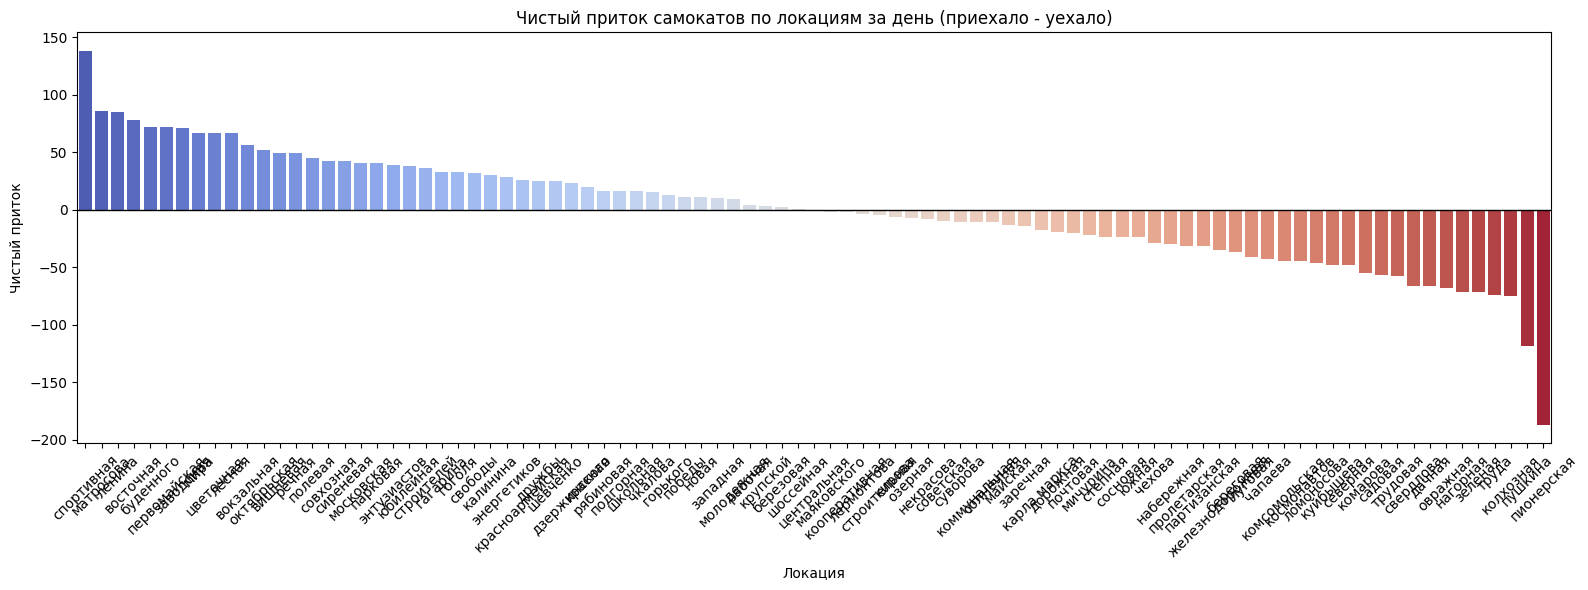

In [75]:
departures = df.groupby('Start Location').size().reset_index(name='departures')
arrivals = df.groupby('End Location').size().reset_index(name='arrivals')

# Объединяем данные
balance = pd.merge(arrivals, departures,
                   left_on='End Location', right_on='Start Location',
                   how='outer')

# Заполняем пропуски нулями (если в локации были только приезды или только уезды)
balance['End Location'] = balance['End Location'].combine_first(balance['Start Location'])
balance = balance.drop(columns=['Start Location'])
balance = balance.rename(columns={'End Location': 'Location'})
balance['arrivals'] = balance['arrivals'].fillna(0)
balance['departures'] = balance['departures'].fillna(0)

# Считаем чистый приток
balance['net_flow'] = balance['arrivals'] - balance['departures']

# Сортировка по притоку
balance = balance.sort_values(by='net_flow', ascending=False)

# Визуализация
plt.figure(figsize=(16, 6))
sns.barplot(data=balance, x='Location', y='net_flow', palette='coolwarm')
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=45)
plt.title('Чистый приток самокатов по локациям за день (приехало - уехало)')
plt.ylabel('Чистый приток')
plt.xlabel('Локация')
plt.tight_layout()
plt.show()


In [76]:
balance[balance['net_flow'] >= 0]['net_flow'].sum()

1735

Для оптимального распределения самокатов между локациями сначала в данные добавляется новый столбец, отражающий общий трафик — сумму всех приездов и отъездов. Затем вычисляется доля трафика каждой локации относительно общего объёма, что позволяет оценить её значимость в системе передвижения.

На основе полученных долей рассчитывается целевое количество самокатов, которое должно быть размещено в каждой точке. Если в результате округления появляются небольшие погрешности (например, общее количество самокатов не совпадает с нужным), производится корректировка распределения для устранения расхождений.

После этого формируется итоговая таблица с рассчитанным распределением самокатов по всем локациям. Заключительным этапом становится построение графика, на котором визуализируется, сколько самокатов должно быть направлено в каждую точку.

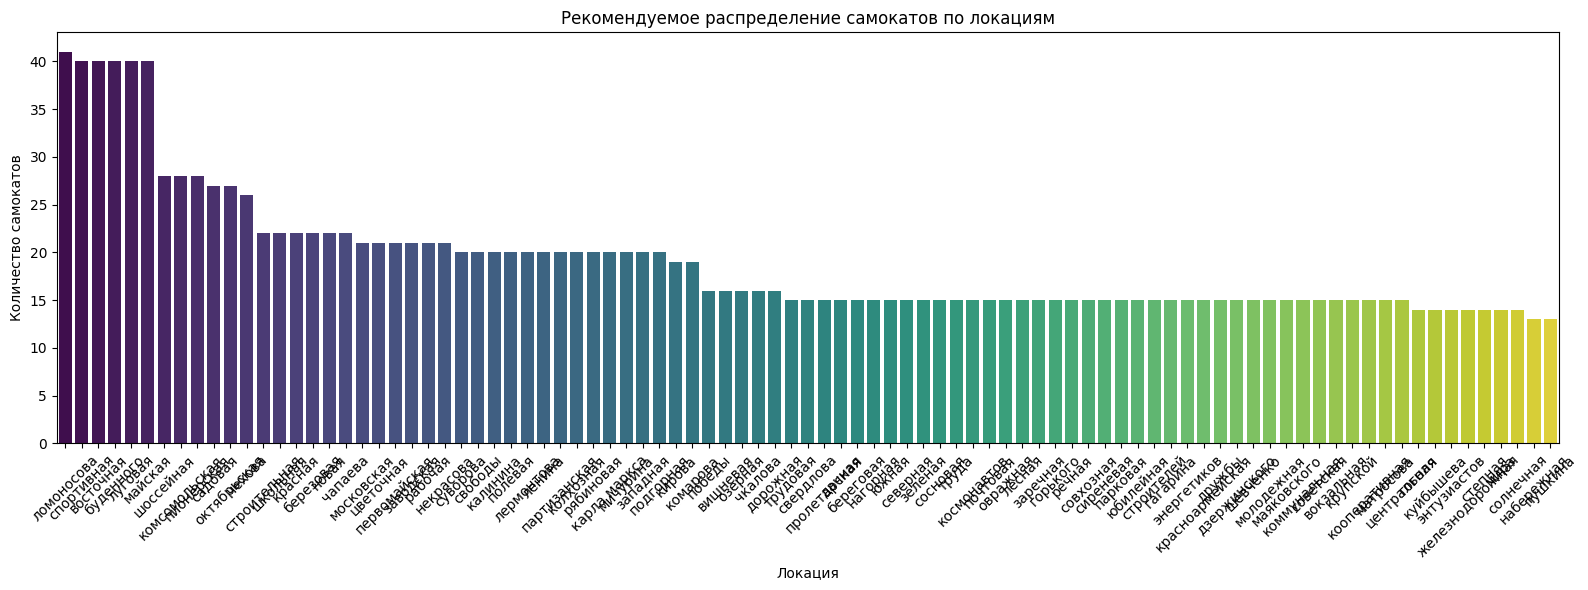

In [77]:
balance['total_traffic'] = balance['arrivals'] + balance['departures']

# Шаг 2: Посчитаем долю трафика каждой станции
balance['traffic_share'] = balance['total_traffic'] / balance['total_traffic'].sum()

# Шаг 3: Задаем общее количество самокатов (например, 1000)
total_scooters = balance[balance['net_flow'] >= 0]['net_flow'].sum()
balance['target_scooters'] = (balance['traffic_share'] * total_scooters).round().astype(int)

# Шаг 4: Подгоняем так, чтобы сумма была ровно равна total_scooters
diff = total_scooters - balance['target_scooters'].sum()
if diff != 0:
    # Добавляем или убавляем по одной штуке с самых трафиковых точек
    adjust_indices = balance['total_traffic'].sort_values(ascending=(diff < 0)).index[:abs(diff)]
    balance.loc[adjust_indices, 'target_scooters'] += np.sign(diff)

# Результат
final_distribution = balance[['Location', 'target_scooters']].sort_values(by='target_scooters', ascending=False)

# Визуализация
plt.figure(figsize=(16, 6))
sns.barplot(data=final_distribution, x='Location', y='target_scooters', palette='viridis')
plt.xticks(rotation=45)
plt.title('Рекомендуемое распределение самокатов по локациям')
plt.ylabel('Количество самокатов')
plt.xlabel('Локация')
plt.tight_layout()
plt.show()


In [78]:
final_distribution['target_scooters'].sum() == balance[balance['net_flow'] >= 0]['net_flow'].sum()

True

Да, необходимость перераспределять самокаты в конце дня есть.

**Вывод:**
Анализ трафика показывает, что каждая локация имеет разную нагрузку — одни точки активно используются, другие — реже. На основе суммы всех приездов и отъездов рассчитывается доля участия каждой локации в общем движении, что позволяет определить, где самокаты нужны больше всего. Целевое количество самокатов распределяется в соответствии с этими долями, а при необходимости — корректируется для точного соответствия общей численности парка.

Такой подход позволяет сбалансировать доступность самокатов по городу, избежать дефицита в популярных точках и переизбытка в менее загруженных. Следовательно, перераспределение в конце дня важно для поддержания эффективной работы сервиса и удовлетворения спроса пользователей.

# 2.2. Изучить накопительное поведение разницы в трафике в каждой точке

Группировка данных по каждой точке, считаем отток и приток по каждому времени.

In [79]:
df['DateCumSum'] = df['start_date'].dt.date
outflow = df.groupby(['DateCumSum', 'Start Location']).size().reset_index(name='outflow')
inflow = df.groupby(['DateCumSum', 'End Location']).size().reset_index(name='inflow')
outflow.rename(columns={'Start Location': 'Location'}, inplace=True)
inflow.rename(columns={'End Location': 'Location'}, inplace=True)
net_flow = pd.merge(inflow, outflow, on=['DateCumSum', 'Location'], how='outer').fillna(0)
net_flow['net_change'] = net_flow['inflow'] - net_flow['outflow']
net_flow.sort_values(['Location', 'DateCumSum'], inplace=True)
net_flow['cumsum'] = net_flow.groupby(['Location'])['net_change'].cumsum()


print(net_flow.head())


     DateCumSum   Location  inflow  outflow  net_change  cumsum
0    2023-04-22  береговая     7.0      5.0         2.0     2.0
91   2023-04-23  береговая     9.0      6.0         3.0     5.0
182  2023-04-24  береговая     7.0      5.0         2.0     7.0
273  2023-04-25  береговая     3.0      5.0        -2.0     5.0
364  2023-04-26  береговая     4.0      5.0        -1.0     4.0


Для анализа изменений потока самокатов по локациям данные сначала преобразуются в нужный формат, позволяющий отдельно рассчитать приток и отток для каждой точки. Чтобы корректно объединить полученные данные, столбцы переименовываются — это необходимо для однозначного сопоставления информации о прибывших и уехавших.

После переименования осуществляется объединение двух наборов данных — притока и оттока — по локациям. Далее рассчитывается разница в трафике, то есть сколько самокатов прибыло в локацию по сравнению с количеством уехавших. Это помогает определить, где возникает дефицит или избыток транспорта.

Для более глубокого анализа рассчитывается накопительная сумма изменения потока по каждой локации, отражающая, как меняется ситуация с течением времени и где требуется корректировка распределения самокатов.

Построение графика накопительной разницы по точкам

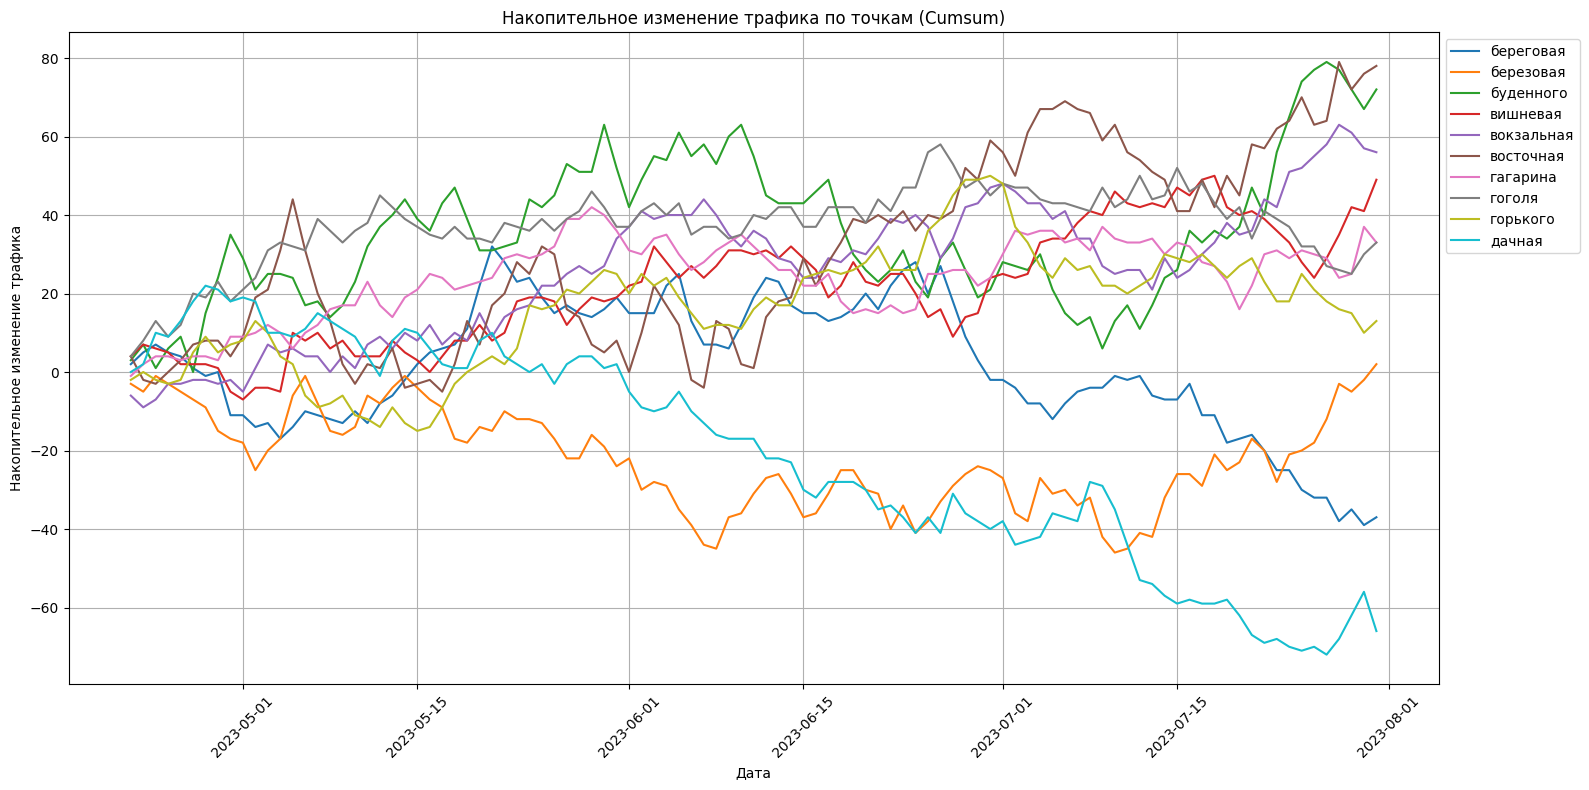

In [81]:
# Группируем по точке и строим графики для каждой точки
locations = net_flow['Location'].unique()

plt.figure(figsize=(16, 8))

for i, loc in enumerate(locations[:10]):  # Ограничим вывод 10 точками для наглядности
    temp = net_flow[net_flow['Location'] == loc]
    plt.plot(temp['DateCumSum'], temp['cumsum'], label=loc)

plt.title('Накопительное изменение трафика по точкам (Cumsum)')
plt.xlabel('Дата')
plt.ylabel('Накопительное изменение трафика')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Задача 2:** Определить необходимое количество самокатов в каждой точке и районе для удовлетворения спроса в полном объеме

In [82]:
# Максимальное количество самокатов по каждой точке
required_scooters = net_flow.groupby('Location')['cumsum'].max().reset_index()
required_scooters.rename(columns={'cumsum': 'Required Scooters'}, inplace=True)
required_scooters.sort_values(by='Required Scooters').head()

,Location,Required Scooters
59,пушкина,-5.0
22,комарова,-5.0
51,партизанская,-4.0
63,садовая,-3.0
21,колхозная,-3.0


Определение необходимого количества самокатов по районам

In [83]:
# Добавляем информацию о районах
location_district_map = df[['Start Location', 'start_district']].drop_duplicates()
required_scooters = required_scooters.merge(location_district_map, left_on='Location', right_on='Start Location', how='left')
district_scooters = required_scooters.groupby('start_district')['Required Scooters'].sum().reset_index()
district_scooters.head()

,Start District,Required Scooters
0,заречный,168.0
1,ленинский,378.0
2,октябрьский,381.0
3,северо-западный,467.0
4,центральный,801.0


Построение графиков для самокатов по точкам и районам.

По районам -график показывает, сколько самокатов требуется для покрытия ежедневного спроса в различных районах города. Высокие столбцы на графике указывают на районы с более интенсивным спросом на самокаты. В нашем случае - центральный

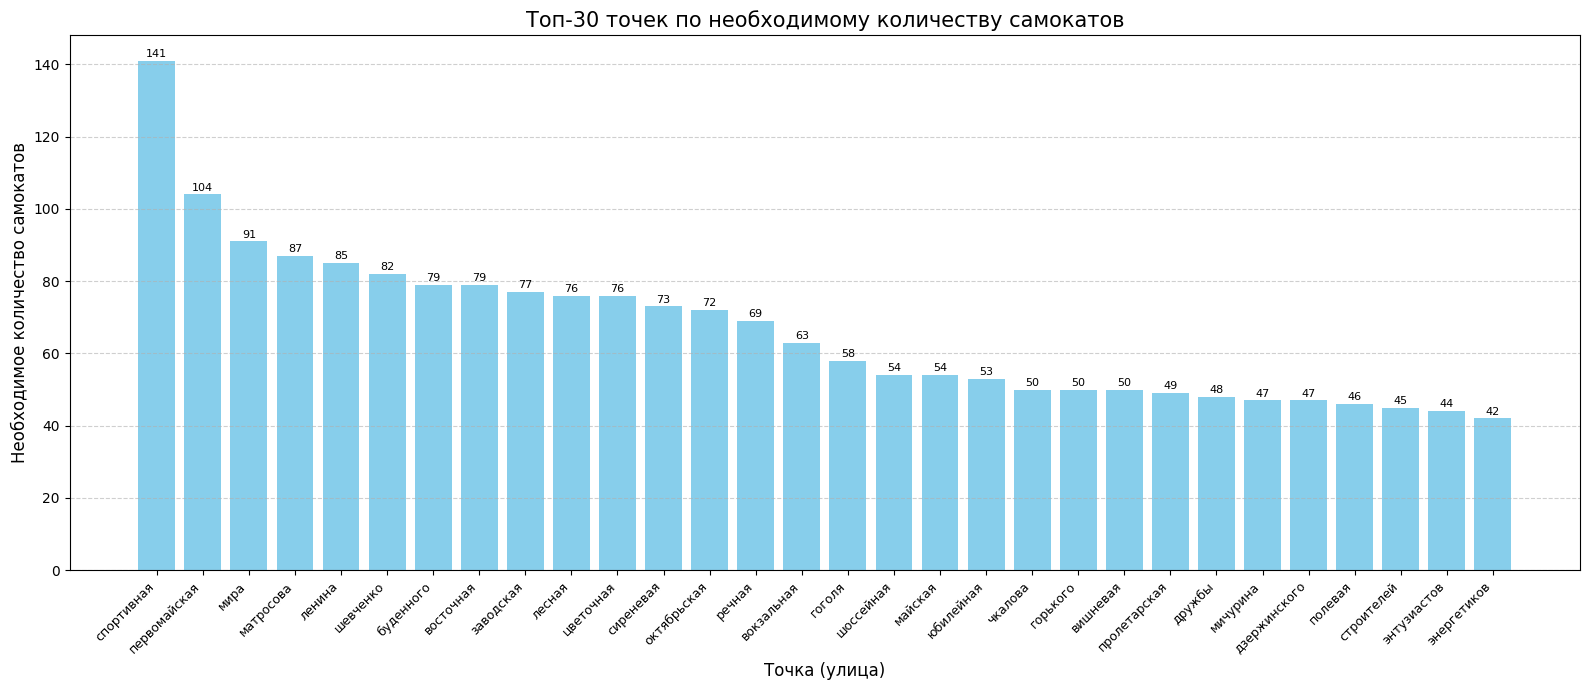

In [84]:
# Отбираем топ-30 точек с наибольшим спросом
top_n = 30
top_scooters = required_scooters.sort_values('Required Scooters', ascending=False).head(top_n)

# Создаём график
plt.figure(figsize=(16, 7))
bars = plt.bar(top_scooters['Location'], top_scooters['Required Scooters'], color='skyblue')

# Добавляем подписи на столбиках
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f'{int(height)}',
             ha='center', va='bottom', fontsize=8)

# Добавляем пояснение
plt.text(0, top_scooters['Required Scooters'].max() + 3,
         f'',
         fontsize=11, ha='left', va='bottom', color='green')

# Оформление графика
plt.title(f'Топ-{top_n} точек по необходимому количеству самокатов', fontsize=15)
plt.xlabel('Точка (улица)', fontsize=12)
plt.ylabel('Необходимое количество самокатов', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


Таблица с почасовым трафиком (отъезды и приезды) для каждой точки

In [85]:
outflow = df.groupby(['Start Location', 'StartHourCum']).size().reset_index(name='outflow')

# Группируем по точке назначения (End Location) и часу окончания (End Hour) для приездов
inflow = df.groupby(['End Location', 'EndHourCum']).size().reset_index(name='inflow')

# Переименуем столбцы, чтобы объединить данные
outflow.rename(columns={'Start Location': 'Location', 'StartHourCum': 'Hour'}, inplace=True)
inflow.rename(columns={'End Location': 'Location', 'EndHourCum': 'Hour'}, inplace=True)

# Объединяем данные о притоке и оттоке по локации и времени
traffic = pd.merge(outflow, inflow, on=['Location', 'Hour'], how='outer').fillna(0)

# Рассчитываем чистый трафик для каждой локации по каждому часу
traffic['net_traffic'] = traffic['inflow'] - traffic['outflow']

# Просмотр результатов
print(traffic.head())


    Location                Hour  outflow  inflow  net_traffic
0  береговая 2023-04-22 10:00:00      0.0     1.0          1.0
1  береговая 2023-04-22 13:00:00      1.0     0.0         -1.0
2  береговая 2023-04-22 14:00:00      2.0     0.0         -2.0
3  береговая 2023-04-22 17:00:00      0.0     1.0          1.0
4  береговая 2023-04-22 18:00:00      2.0     1.0         -1.0


Используя группировку, посчитаем количество поездок для каждой локации (как для отъездов, так и для приездов) по часам. Это делается с помощью метода resample, который позволяет ресемплировать данные по заданному интервалу времени (в нашем случае — по часам).Мы получим таблицу с количеством отъездов и приездов для каждой локации по каждому часу.

**Вывод**: На локации «береговая» наблюдается отрицательный чистый поток в течение дня – это значит, что оттуда уезжает больше самокатов, чем приезжает.

Самые активные часы отъездов:

В 14:00 — сразу 2 отъезда, ни одного приезда → чистый отток -2.

В 18:00 — тоже 2 отъезда, но хотя бы 1 приезд → чистый отток -1.

Часы, когда был чистый приток:

В 10:00 и в 17:00 — +1 самокат прибыл на точку в каждом из этих часов.

В целом, за этот день на локации «береговая» ушло больше самокатов, чем вернулось, что может говорить о её популярности как точки старта, но не финиша.

**Почасовой трафик по точкам**

In [86]:
outflow = df.groupby(['StartHourCum', 'Start Location']).size().reset_index(name='outflow')
outflow = outflow.rename(columns={'StartHourCum': 'Hour', 'Start Location': 'Location'})
inflow = df.groupby(['EndHourCum', 'End Location']).size().reset_index(name='inflow')
inflow = inflow.rename(columns={'EndHourCum': 'Hour', 'End Location': 'Location'})
# Объединяем приток и отток
hourly_traffic = pd.merge(inflow, outflow, on=['Hour', 'Location'], how='outer').fillna(0)

# Добавляем столбец с чистым потоком
hourly_traffic['net_traffic'] = hourly_traffic['inflow'] - hourly_traffic['outflow']
hourly_traffic


,Hour,Location,inflow,outflow,net_traffic
0,2023-04-22 09:00:00,буденного,0.0,2.0,-2.0
1,2023-04-22 09:00:00,восточная,0.0,1.0,-1.0
2,2023-04-22 09:00:00,гоголя,1.0,0.0,1.0
3,2023-04-22 09:00:00,западная,2.0,0.0,2.0
4,2023-04-22 09:00:00,зеленая,0.0,1.0,-1.0
...,...,...,...,...,...
104302,2023-08-01 00:00:00,садовая,1.0,0.0,1.0
104303,2023-08-01 00:00:00,суворова,1.0,0.0,1.0
104304,2023-08-01 00:00:00,чкалова,1.0,0.0,1.0
104305,2023-08-01 00:00:00,шевченко,1.0,0.0,1.0


Выводы:
Отрицательные cumsum у ряда точек (например, березовая, вокзальная, южная) указывают на постоянный отток самокатов. Эти точки, скорее всего, источники поездок — их нужно регулярно пополнять.

Положительный cumsum (например, энтузиастов, энергетиков) говорит о накоплении самокатов — это точки прибытия, где со временем будет перенасыщение.

Колебания без сильного тренда могут свидетельствовать о балансных точках, где вход и выход примерно равны.

**АНАЛИЗ:** 1. Суммарный трафик (по всем точкам и времени)
Суммарный inflow (приезды): это общее число самокатов, которые завершили поездку на точке.
Суммарный outflow (отъезды): общее число самокатов, которые начали поездку с точки.
Если сумма inflow = сумма outflow → система сбалансирована.
Но если наблюдается:
Переизбыток inflow — точки перегружаются (может не хватать места, парковок).
Переизбыток outflow — точки опустошаются (нет самокатов для старта поездки).

2. Трафик по отдельным точкам
Можно выделить три типа точек:
Сбалансированные точки (net_traffic ≈ 0)
Пример: точки, где inflow и outflow примерно равны.
Такие локации не требуют регулярного вмешательства, они “самообслуживаются”.
Притягивающие точки (net_traffic > 0)
Пример: точки, где приезжает больше, чем уезжает.
Возможные причины: Жилые районы вечером
Риски: переполненность и нехватка свободного места.

Рекомендации:
Добавить парковочные зоны
Планировать вывоз самокатов в утренние/вечерние часы
Опустошаемые точки (net_traffic < 0)
Пример: точки, где уезжают чаще, чем приезжают.
Возможные причины:Жилые районы утром

Центр города, парки, ТЦ — в начале дня
Рекомендации:
Подвозить самокаты с утра
Следить за доступностью в часы пик

Пики утренние (7:00–9:00) — люди уезжают из спальных районов.
Пики вечерние (17:00–20:00) — возвращаются обратно.
В течение дня – относительно спокойный трафик с локальными всплесками.




**Разница отъезды и приезды**

In [88]:
# 1. Группируем по часу и локации
outflow = df.groupby(['StartHour2', 'Start Location']).size().reset_index(name='outflow')
inflow = df.groupby(['EndHour2', 'End Location']).size().reset_index(name='inflow')

# 2. Переименуем колонки для объединения
outflow.rename(columns={'StartHour2': 'Hour', 'Start Location': 'Location'}, inplace=True)
inflow.rename(columns={'EndHour2': 'Hour', 'End Location': 'Location'}, inplace=True)

# 3. Объединяем приезды и отъезды
traffic = pd.merge(inflow, outflow, on=['Hour', 'Location'], how='outer').fillna(0)

# 4. Считаем чистый трафик (приехало - уехало)
traffic['net_traffic'] = traffic['inflow'] - traffic['outflow']

# 5. Группируем по дате и локации
traffic['Date'] = traffic['Hour'].dt.date
daily_net = traffic.groupby(['Date', 'Location'])['net_traffic'].sum().reset_index()

# 6. Считаем накопительную сумму по каждой локации (динамика самокатов)
daily_net['cumsum'] = daily_net.groupby('Location')['net_traffic'].cumsum()
daily_net

,Date,Location,net_traffic,cumsum
0,2023-04-22,береговая,2.0,2.0
1,2023-04-22,березовая,-3.0,-3.0
2,2023-04-22,буденного,3.0,3.0
3,2023-04-22,вишневая,5.0,5.0
4,2023-04-22,вокзальная,-6.0,-6.0
...,...,...,...,...
9186,2023-07-31,шоссейная,3.0,1.0
9187,2023-07-31,энергетиков,-2.0,28.0
9188,2023-07-31,энтузиастов,-3.0,39.0
9189,2023-07-31,юбилейная,-3.0,38.0


Выводы:
Отрицательные cumsum у ряда точек (например, березовая, вокзальная, южная) указывают на постоянный отток самокатов. Эти точки, скорее всего, источники поездок — их нужно регулярно пополнять.

Положительный cumsum (например, энтузиастов, энергетиков) говорит о накоплении самокатов — это точки прибытия, где со временем будет перенасыщение.

Колебания без сильного тренда могут свидетельствовать о балансных точках, где вход и выход примерно равны.

**Минимумы для каждой точки**

In [90]:
# Ресемплирование по дате, для каждой локации находим минимум cumsum по дням
daily_min_cumsum = net_flow.groupby(['Location', 'DateCumSum'])['cumsum'].min().reset_index()

# Усреднение по локациям
location_min_cumsum = daily_min_cumsum.groupby('Location')['cumsum'].mean().reset_index()

# Сортировка по возрастанию, чтобы определить точки с наименьшими накопленными значениями
location_min_cumsum_sorted = location_min_cumsum.sort_values(by='cumsum', ascending=True)

# Просмотр результатов
print(location_min_cumsum_sorted.head())


      Location     cumsum
53  пионерская -99.633663
59     пушкина -60.405941
77       труда -53.950495
47    овражная -44.158416
35     луговая -42.128713


**Локации с наибольшими отрицательными значениями cumsum:**

Пионерская (-99.63), Пушкина (-60.41), Труда (-53.95), Овражная (-44.16) и Луговая (-42.13) — это точки, где чаще всего происходит отток самокатов.

Эти локации имеют самые низкие (отрицательные) значения накопленного трафика, что может свидетельствовать о том, что на этих точках количество самокатов обычно уменьшается, а это указывает на потребность в их пополнении.

Распределение оттока:

Понижение накопленного трафика в этих локациях может происходить в моменты, когда самокаты активно отъезжают в другие точки, и данные локации оказываются недостаточно обеспеченными.

**Рекомендации:**
Регулярное пополнение:
Локации с такими минимальными значениями трафика явно нуждаются в регулярном пополнении самокатов, особенно в часы пикового спроса (например, утром). Эти локации, возможно, не справляются с объемом потребности и имеют постоянный отток.

Рекомендуется:
Увеличить пополнение самокатов в эти точки перед утренними и вечерними пиками, когда самокаты могут быть востребованы для поездок.

Анализ потребности в самокатах:
Возможно, стоит периодически проверять прогнозируемый трафик для этих локаций, основываясь на внешних данных, таких как плотность населения, инфраструктура и популярность районов.

Могут быть ситуации, когда количество самокатов в этих локациях избыточно уменьшается из-за постоянного отъезда, что говорит о том, что надо заранее учитывать логистику для равномерного распределения.

Перераспределение избыточных самокатов:
Можно использовать информацию о минимальных значениях накопленного трафика для перераспределения самокатов между точками, где происходит значительный отток. Это позволит минимизировать нехватку самокатов в определенных районах.

Рекомендуется:
Выстроить систему логистики для динамического перераспределения самокатов с точек с избыточным количеством (например, с точек с положительным cumsum) в эти "нуждающиеся" локации.

Учет дня недели и времени суток:
Нужно проводить дополнительный анализ по дням недели и времени суток, чтобы определить, когда именно в этих локациях происходит наибольший отток, и использовать данные для оптимизации логистики.

**Заключение:**
На основе текущего анализа видно, что локации с минимальными значениями cumsum (отрицательным накопленным трафиком) нуждаются в более частом пополнении. Рекомендуется организовать регулярное пополнение самокатов на этих точках в часы пик, а также пересматривать распределение самокатов в зависимости от спроса и времени суток.

Используем группировку по локации и дате для вычисления минимальных значений накопленного трафика (cumsum).

График визуализирует минимальные значения накопленного трафика по каждой локации, что позволяет лучше понять, где происходят самые большие изменения (например, отток самокатов).

Точки с наибольшим отрицательным значением cumsum будут находиться внизу графика, а те, где отрицательные значения минимальны (или даже положительные), — в верхней части графика.

Полезность графика:

Этот график наглядно показывает, в каких точках происходит наибольший отток самокатов (самые отрицательные значения cumsum).

Это помогает сразу выделить проблемные локации, которые требуют особого внимания (например, дополнительного пополнения самокатов в эти точки или перераспределения).

Рекомендации:

Для локаций с наиболее отрицательным значением cumsum (которые находятся в нижней части графика) следует проанализировать причину такого оттока и предпринять меры для улучшения ситуации. Например, нужно обеспечить регулярное пополнение этих локаций или пересмотреть маршруты перемещения самокатов.

**Вывод**: График дает наглядное представление о том, где происходят наибольшие изменения в накопленном трафике, позволяя сделать выводы о локациях, которые нуждаются в дополнительном внимании.

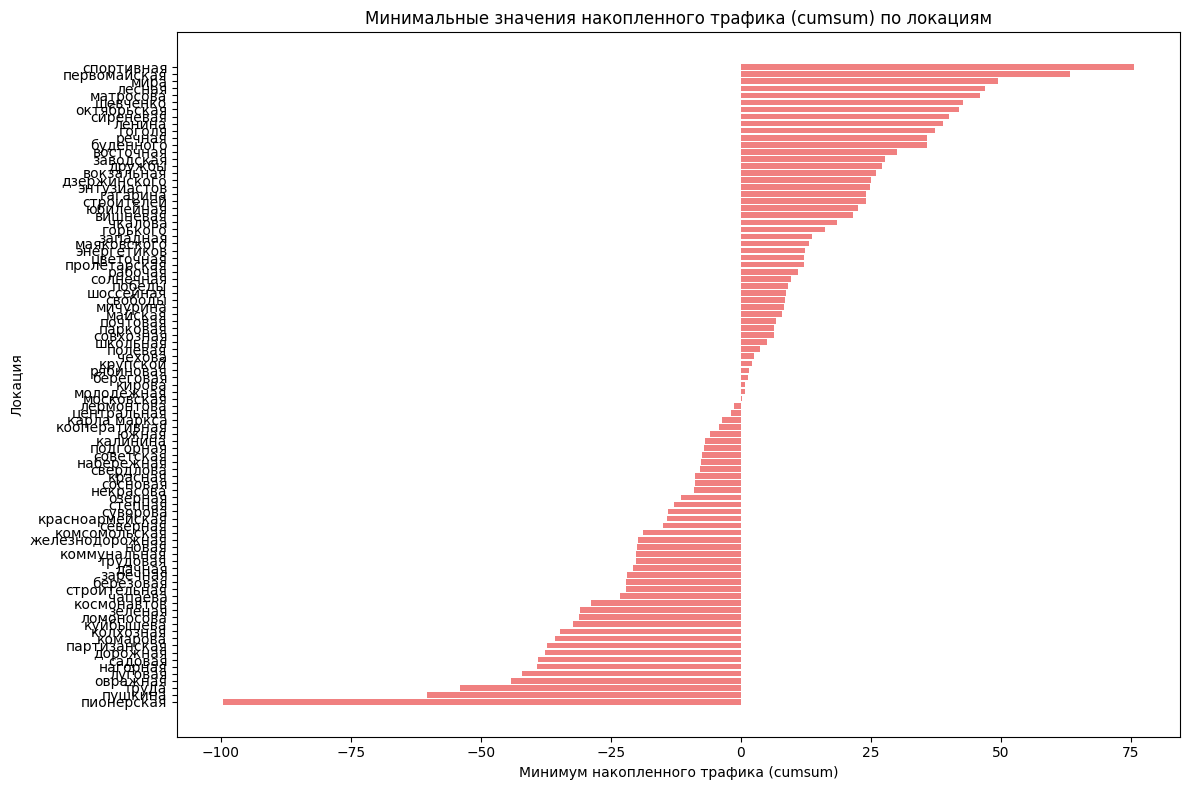

In [91]:
import matplotlib.pyplot as plt

# Построение графика минимальных значений cumsum по локациям
plt.figure(figsize=(12, 8))
plt.barh(location_min_cumsum_sorted['Location'], location_min_cumsum_sorted['cumsum'], color='lightcoral')
plt.xlabel('Минимум накопленного трафика (cumsum)')
plt.ylabel('Локация')
plt.title('Минимальные значения накопленного трафика (cumsum) по локациям')
plt.tight_layout()
plt.show()


# 3.Исследовать корреляцию между параметрами погодных условий

# Гипотезы - 6 шт

Гипотеза №1

* **1.Нулевая** - Влияет ли солнечность погоды на длину поездки?
* **2.Альnернатива**- Солнечность погоды не влияет на длину поездки.

In [ ]:
df[['Sunshine Duration', 'distance']]

In [ ]:
filtered = df[['distance', 'Sunshine Duration']].dropna()
correlation, p_value = spearmanr(filtered['Sunshine Duration'], filtered['distance'])

print(f"Корреляция: {correlation}")
print(f"p-значение: {p_value}")


Доказательство: расчет спирмановской корреляции между продолжительностью солнечного сияния и расстоянием поездки.

**3.Вывод:** Нулевая гипотиза опровергнута, значит можем утверждать, что солнечность погоды не влияет на длину поездки

Гипотеза №2
* **1.Нулевая** - Влияет ли день недели на длину поездки?
* **2.Альернатива** - День недели не влияет на длину поездки.

In [ ]:
filtered = df[['distance', 'weekday']].dropna()
correlation, p_value = spearmanr(filtered['weekday'], filtered['distance'])

print(f"Корреляция: {correlation}")
print(f"p-значение: {p_value}")

**3.Вывод:** да, есть сильная зависимость между днем недели и длиной поездки

Гипотеза №3
* **1.Нулевая** - Падает ли спрос на самокаты в середине недели и происходит из-за постоянного ухудшения погоды именно в эти дни
* **2.Альернатива ** - спрос не падает в середине недели из-за постоянного ухудшения погоды

In [ ]:
# Вывести названия всех столбцов
print(df.columns)


In [ ]:
# Загрузка данных
df = pd.read_csv('weather.csv')

# Преобразуем дату и извлечем день недели
df['Datetime'] = pd.to_datetime(df['Datetime'], errors='coerce')
df['Weekday'] = df['Datetime'].dt.weekday  # 0 = понедельник, 6 = воскресенье

# Проверим, есть ли пропущенные значения в 'Weekday' и заменим их (если есть)
df['Weekday'] = df['Weekday'].fillna(-1).astype(int)  # -1 на случай NaN значений

# Преобразуем погодные столбцы в числовой формат
weather_columns = ['Temperature', 'Precipitation Total', 'Cloud Cover Total', 'Wind Speed']
for col in weather_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Заполним пропущенные значения средними
df[weather_columns] = df[weather_columns].fillna(df[weather_columns].mean())

# Группировка: средняя погода по дням недели
agg_df = df.groupby('Weekday').agg({
    'Temperature': 'mean',
    'Precipitation Total': 'mean',
    'Cloud Cover Total': 'mean',
    'Wind Speed': 'mean'
}).reset_index()

# Названия дней недели
day_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
agg_df['Weekday Name'] = agg_df['Weekday'].map(lambda x: day_names[int(x)] if x >= 0 and x < len(day_names) else 'Невалидный день')

# Визуализация: температура и осадки по дням недели
plt.figure(figsize=(12, 6))
plt.plot(agg_df['Weekday Name'], agg_df['Temperature'], label='Температура (°C)', marker='o')
plt.plot(agg_df['Weekday Name'], agg_df['Precipitation Total'], label='Осадки (мм)', marker='s')
plt.title('Температура и осадки по дням недели')
plt.xlabel('День недели')
plt.grid(True)
plt.legend()
plt.show()

# Визуализация: облачность и скорость ветра по дням недели
plt.figure(figsize=(12, 6))
plt.plot(agg_df['Weekday Name'], agg_df['Cloud Cover Total'], label='Облачность (%)', marker='o')
plt.plot(agg_df['Weekday Name'], agg_df['Wind Speed'], label='Скорость ветра (м/с)', marker='s')
plt.title('Облачность и скорость ветра по дням недели')
plt.xlabel('День недели')
plt.grid(True)
plt.legend()
plt.show()

# Корреляция между погодой
corr = agg_df[['Temperature', 'Precipitation Total', 'Cloud Cover Total', 'Wind Speed']].corr()
print("Корреляция между погодными условиями:\n")
print(corr)


In [ ]:
# Загрузка данных
df = pd.read_csv('rides.csv')  # замените на имя вашего файла

# Преобразуем дату начала в datetime, если необходимо
df['start_date'] = pd.to_datetime(df['start_date'], errors='coerce')

# Если нет числового дня недели — добавим его
if 'Weekday' not in df.columns:
    df['Weekday'] = df['start_date'].dt.weekday  # 0 = Monday, 6 = Sunday

# Названия дней недели для красивой подписи
day_map = {
    0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт',
    4: 'Пт', 5: 'Сб', 6: 'Вс'
}
df['Weekday Name'] = df['Weekday'].map(day_map)

# Группируем: считаем количество поездок на каждый день недели
trip_counts = df['Weekday Name'].value_counts().reindex(['Пн','Вт','Ср','Чт','Пт','Сб','Вс'])

# Визуализация
plt.figure(figsize=(10, 6))
trip_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Спрос на самокаты по дням недели', fontsize=14)
plt.xlabel('День недели')
plt.ylabel('Количество поездок')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
# Загрузка данных
rides = pd.read_csv('rides.csv')
weather = pd.read_csv('weather.csv')

# Преобразуем даты
rides['start_date'] = pd.to_datetime(rides['start_date'], errors='coerce')
weather['Datetime'] = pd.to_datetime(weather['Datetime'], errors='coerce')

# Добавим колонку "Date" и "Weekday"
rides['Date'] = rides['start_date'].dt.date
rides['Weekday'] = rides['start_date'].dt.weekday  # 0=Пн
weather['Date'] = weather['Datetime'].dt.date
weather['Weekday'] = weather['Datetime'].dt.weekday

# Числовое преобразование погодных столбцов
weather_cols = ['Temperature', 'Precipitation Total', 'Cloud Cover Total', 'Wind Speed']
for col in weather_cols:
    weather[col] = pd.to_numeric(weather[col], errors='coerce')

# Группировка: усреднённая погода по дню
weather_daily = weather.groupby(['Date', 'Weekday'])[weather_cols].mean().reset_index()

# Количество поездок по дате
rides_daily = rides.groupby(['Date', 'Weekday']).size().reset_index(name='Ride Count')

# Объединение данных
merged = pd.merge(rides_daily, weather_daily, on=['Date', 'Weekday'], how='inner')

# Добавим названия дней недели
day_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
merged['Weekday Name'] = merged['Weekday'].map(lambda x: day_names[x])

# --------------------
# 📊 Визуализация спроса
# --------------------
plt.figure(figsize=(10, 5))
merged.groupby('Weekday Name')['Ride Count'].mean().reindex(day_names).plot(kind='bar', color='skyblue')
plt.title("Средний спрос на самокаты по дням недели")
plt.xlabel("День недели")
plt.ylabel("Среднее количество поездок")
plt.grid(axis='y')
plt.show()

midweek = merged[merged['Weekday'].isin([1, 2, 3])]['Ride Count']
non_midweek = merged[~merged['Weekday'].isin([1, 2, 3])]['Ride Count']

t_stat, p_value = ttest_ind(midweek, non_midweek, equal_var=False)

print("Результаты t-теста:")
print(f"t-статистика: {t_stat:.3f}")
print(f"p-значение: {p_value:.4f}")


corr = merged[['Ride Count', 'Temperature', 'Precipitation Total', 'Cloud Cover Total', 'Wind Speed']].corr()
print("\nКорреляция между погодными условиями и спросом на самокаты:")
print(corr['Ride Count'].sort_values(ascending=False))


Доказательство: Температура и осадки имеют положительную корреляцию (0.459). Это значит, что при повышении температуры количество поездок увеличивается, а при увеличении осадков — уменьшается.

Облачность и осадки также имеют отрицательную корреляцию с количеством поездок. То есть, когда облачность и осадки увеличиваются, количество поездок уменьшается.

Скорость ветра имеет слабую отрицательную корреляцию с количеством поездок (-0.197), что также может указывать на то, что при сильном ветре спрос на самокаты несколько снижается.

**3.Вывод:** спрос падает из-за ухудшения погоды в определенные дни недели

 Гипотеза №4
* **1.Нулевая** - все поездки на самокатах происходят в пределах одного района в пределах 1 района

* **2.Альтернатива** - Поездки на самокатах происходят не только в пределах одного района, и существует статистически значимая разница в распределении поездок между различными районами."

In [ ]:
start_counts = df['start_district'].value_counts()
end_counts = df['End District'].value_counts()

district_counts = (start_counts + end_counts).fillna(0)

threshold_center = district_counts.quantile(0.75)  # Верхние 25% - центр
threshold_outskirts = district_counts.quantile(0.25)  # Нижние 25% - окраины

districts = pd.DataFrame({'District': district_counts.index, 'Trips': district_counts.values})
districts['Category'] = 'Middle'
districts.loc[districts['Trips'] >= threshold_center, 'Category'] = 'Center'
districts.loc[districts['Trips'] <= threshold_outskirts, 'Category'] = 'Outskirts'
print(districts)

In [ ]:
# Настройки визуализации
plt.figure(figsize=(14, 6))
sns.barplot(data=districts.sort_values('Trips', ascending=False), x='District', y='Trips', hue='Category', dodge=False)
plt.title('Количество поездок по районам')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


<Figure size 1400x700 with 0 Axes>

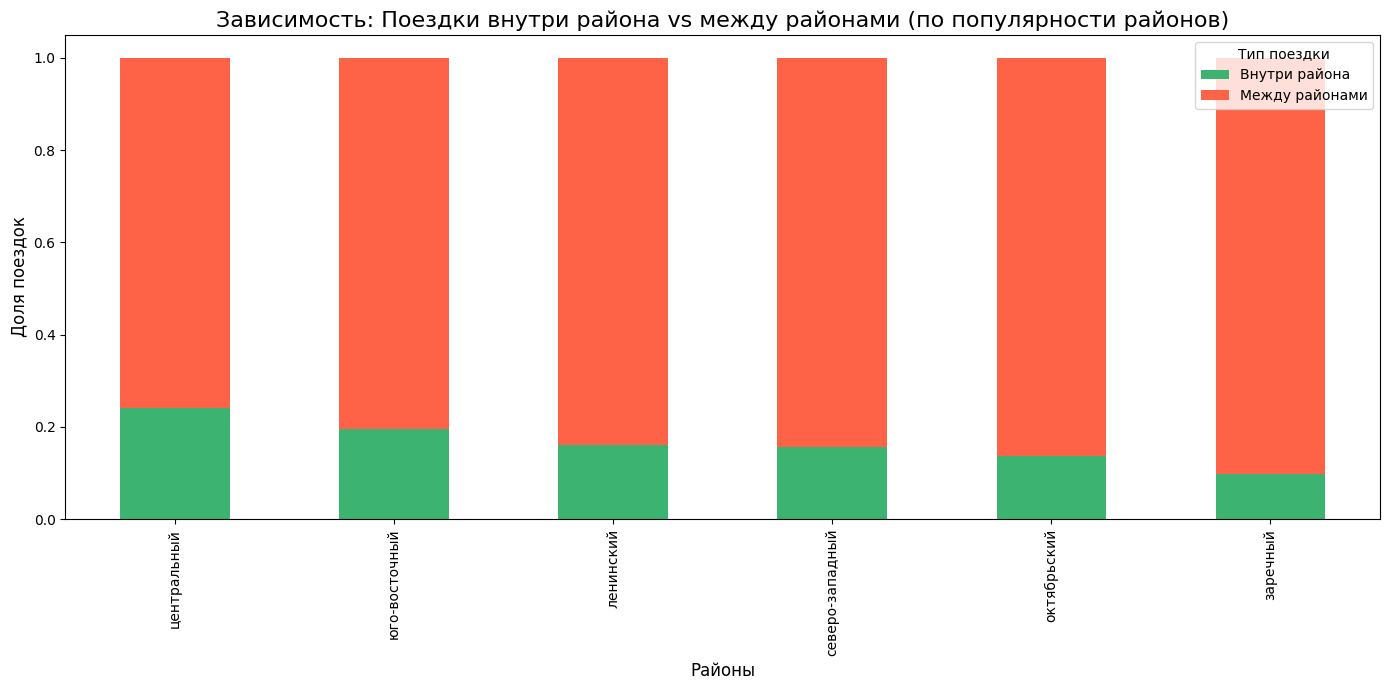

In [ ]:
# 1. Добавляем колонку: поездка внутри района или нет
df['Same District'] = df['start_district'] == df['End District']

# 2. Считаем общее количество поездок по каждому району
district_trip_counts = df.groupby('Start District').size().sort_values(ascending=False)

# 3. Рассчитываем долю поездок внутри района и между районами по каждому району
district_movement = df.groupby('Start District')['Same District'].value_counts(normalize=True).unstack().fillna(0)

# 4. Переименуем колонки для удобства
district_movement.columns = ['Between Districts', 'Within Same District']

# 5. Сортируем районы по количеству поездок
district_movement = district_movement.loc[district_trip_counts.index]

# 6. Построение графика
plt.figure(figsize=(14, 7))
district_movement[['Within Same District', 'Between Districts']].plot(kind='bar', stacked=True, color=['mediumseagreen', 'tomato'], figsize=(14,7))

# 7. Настройки графика
plt.title('Зависимость: Поездки внутри района vs между районами (по популярности районов)', fontsize=16)
plt.ylabel('Доля поездок', fontsize=12)
plt.xlabel('Районы', fontsize=12)
plt.xticks(rotation=90)
plt.legend(title='Тип поездки', labels=['Внутри района', 'Между районами'])
plt.tight_layout()
plt.show()

Доказательство:Альтернативная гипотеза подтверждается, потому что:
Межрайонные поездки — это устойчивая часть всех поездок.
Для разных районов их доля значительно варьируется (в одних районах больше поездок внутри, в других — наоборот).



**3.Вывод:** Поездки на самокатах происходят не только в пределах одного района.

 Гипотеза №5
 * **1.Нулевая**: День недели влияет на количество поездок: в выходные поездок больше
 * **2.Альтернативная:** День недели не оказывает значимого влияния на количество поездок, или влияние отличается от предположения о большем количестве поездок в выходные дни.

Day of Week
Воскресенье    17131
Суббота        16981
Пятница        13314
Понедельник    12035
Среда          11030
Четверг        10899
Вторник        10567
Name: count, dtype: int64


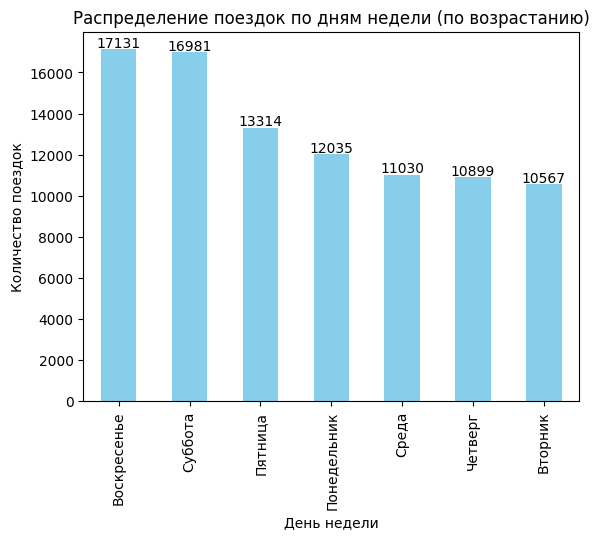

In [ ]:
# Словарь для замены номеров дней недели на названия
day_name_map = {
    0: 'Понедельник',
    1: 'Вторник',
    2: 'Среда',
    3: 'Четверг',
    4: 'Пятница',
    5: 'Суббота',
    6: 'Воскресенье'
}

# Подсчёт, переименование и сортировка по значению
day_counts = df['day_of_week'].value_counts().rename(index=day_name_map)
day_counts = day_counts.sort_values(ascending=False)

# Вывод таблички
print(day_counts)

# Построение графика
day_counts.plot(kind='bar', color='skyblue')
plt.xlabel('День недели')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по дням недели (по возрастанию)')

for i, v in enumerate(day_counts):
    plt.text(i, v + 100, str(v), ha='center', fontsize=10)

plt.show()


Анализ распределения поездок по районам в будние и выходные дни.

In [ ]:
district_day_type_distribution = (
    df.groupby(['Day Type', 'Start District'])
       .size()
       .reset_index(name='Количество поездок')
)

day_type_order = ['Будний день', 'Выходной']
district_day_type_distribution['Day Type'] = pd.Categorical(
    district_day_type_distribution['Day Type'],
    categories=day_type_order,
    ordered=True
)

district_day_type_distribution = (
    district_day_type_distribution
    .sort_values(by=['Day Type', 'Количество поездок'], ascending=[True, False])
    .reset_index(drop=True)
)
print(district_day_type_distribution)

       Day Type   Start District  Количество поездок
0   Будний день      центральный               15521
1   Будний день    юго-восточный               10914
2   Будний день        ленинский                9150
3   Будний день  северо-западный                9078
4   Будний день      октябрьский                7785
5   Будний день         заречный                5397
6      Выходной      центральный                8120
7      Выходной    юго-восточный                6555
8      Выходной        ленинский                5579
9      Выходной  северо-западный                5546
10     Выходной      октябрьский                4883
11     Выходной         заречный                3429


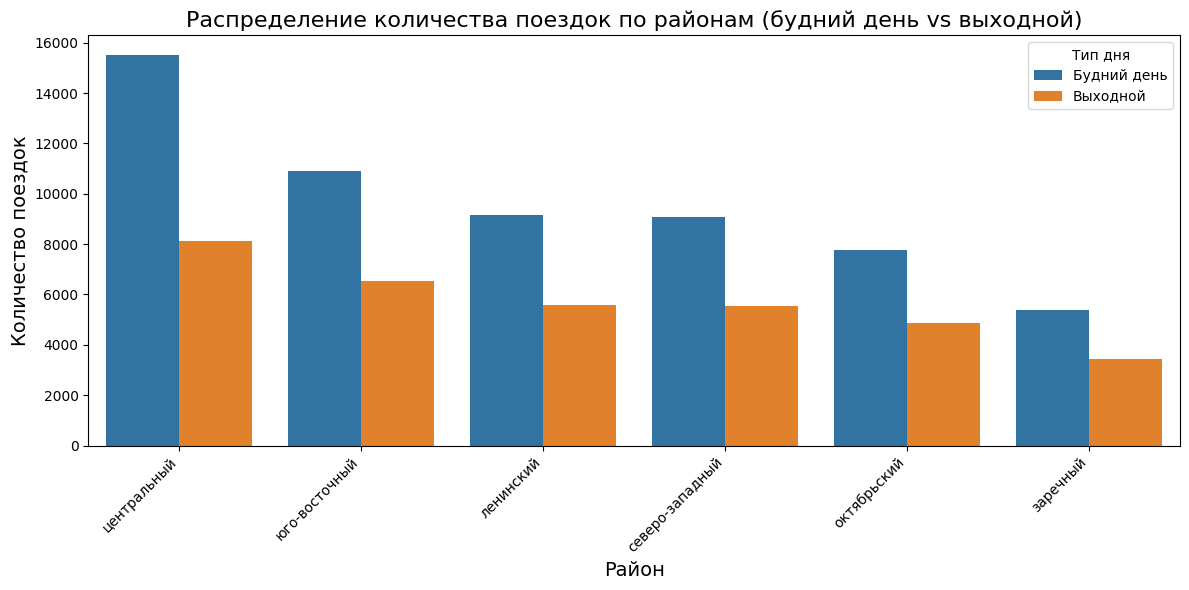

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Start District', y='Количество поездок', hue='Day Type', data=district_day_type_distribution)

plt.title('Распределение количества поездок по районам (будний день vs выходной)', fontsize=16)
plt.xlabel('Район', fontsize=14)
plt.ylabel('Количество поездок', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Тип дня')

plt.tight_layout()
plt.show()

Доказательство:График, построенный с помощью sns.barplot(), позволяет наглядно увидеть различия в количестве поездок по районам в будние дни и выходные. Для выходных дней в большинстве районов будет наблюдаться большее количество поездок, по сравнению с будними днями.

**3.Вывод:** Нулевая гипотеза подтверждена.День недели кардинально влияет на распределение поездок, в выходные дни и пятницу поездок наблюдается значительно больше

 Гипотеза №6
* **1.Нулевая гипотеза:** В будние дни средняя скорость выше
* **2.Средняя скорость** в будние дни не выше, чем в выходные дни


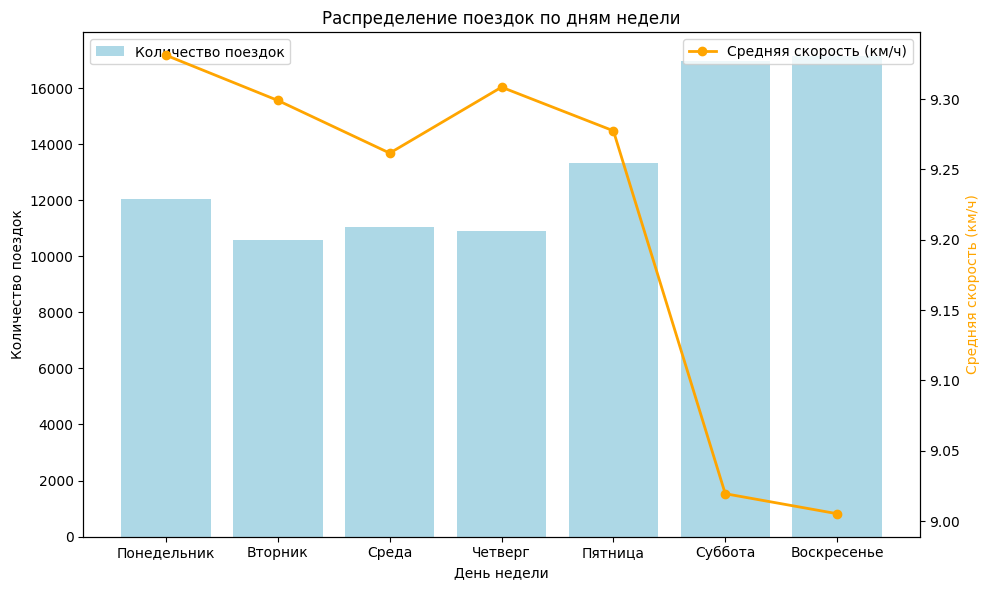

In [ ]:
speed_by_weekday = df.groupby('Weekday')['Speed (km/h)'].agg(['mean', 'count']).reset_index()

weekday_names = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']
speed_by_weekday['Weekday Name'] = speed_by_weekday['Weekday'].map(lambda x: weekday_names[x])

speed_by_weekday = speed_by_weekday.sort_values(by='Weekday')

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(speed_by_weekday['Weekday Name'], speed_by_weekday['count'], color='lightblue', label='Количество поездок')
ax1.set_xlabel('День недели')
ax1.set_ylabel('Количество поездок')
ax1.set_title('Распределение поездок по дням недели')

ax2 = ax1.twinx()
ax2.plot(speed_by_weekday['Weekday Name'], speed_by_weekday['mean'], color='orange', marker='o', label='Средняя скорость (км/ч)', linewidth=2)
ax2.set_ylabel('Средняя скорость (км/ч)', color='orange')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

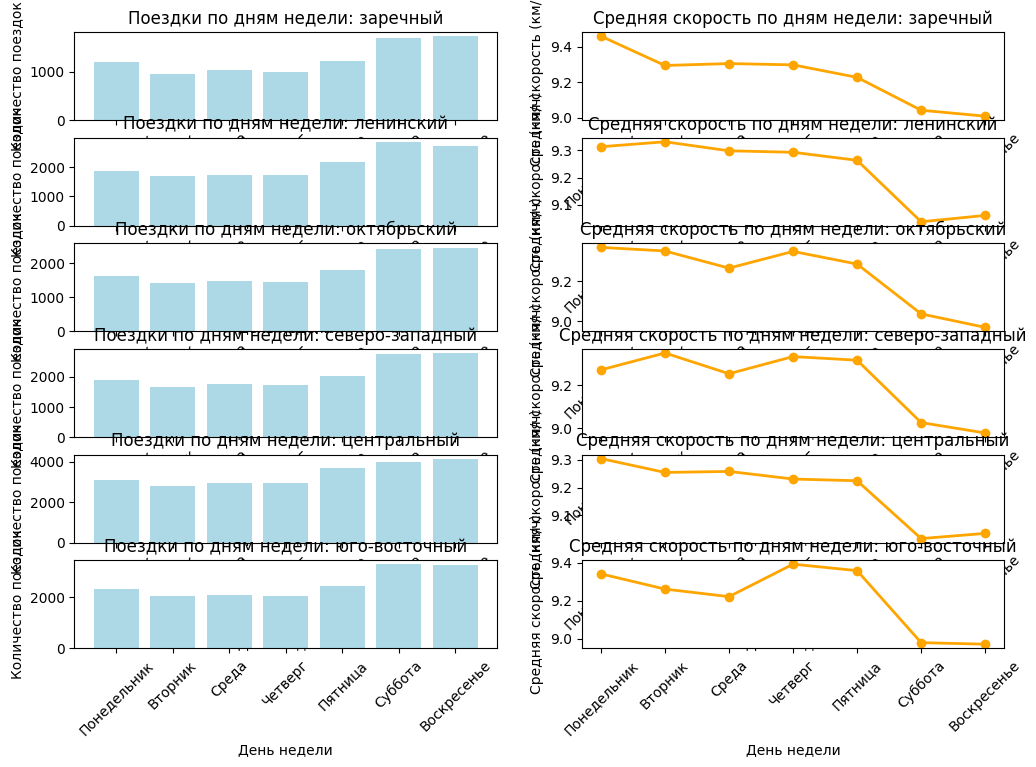

In [ ]:
df2 = df.copy()
# Преобразуем столбец Start Date в datetime
df2['start_date'] = pd.to_datetime(df['start_date'])

# Извлекаем день недели (0 - Понедельник, 6 - Воскресенье)
df2['Weekday'] = df2['start_date'].dt.weekday

# Группируем по району, дню недели и считаем количество поездок и среднюю скорость
speed_by_weekday_district = df2.groupby(['Start District', 'Weekday'])['Speed (km/h)'].agg(['mean', 'count']).reset_index()

# Получаем имена дней недели для отображения на графике
weekday_names = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']
speed_by_weekday_district['Weekday Name'] = speed_by_weekday_district['Weekday'].map(lambda x: weekday_names[x])

# Сортируем по району и дню недели
speed_by_weekday_district = speed_by_weekday_district.sort_values(by=['Start District', 'Weekday'])
# Размер графика
plt.figure(figsize=(12, 8))

# Список уникальных районов
districts = speed_by_weekday_district['Start District'].unique()

# Создадим графики для каждого района
for i, district in enumerate(districts):
    plt.subplot(len(districts), 2, 2 * i + 1)  # Строим подграфик для распределения поездок
    district_data = speed_by_weekday_district[speed_by_weekday_district['Start District'] == district]

    # Количество поездок
    plt.bar(district_data['Weekday Name'], district_data['count'], color='lightblue')
    plt.title(f'Поездки по дням недели: {district}')
    plt.xlabel('День недели')
    plt.ylabel('Количество поездок')
    plt.xticks(rotation=45)

    plt.subplot(len(districts), 2, 2 * i + 2)  # Строим подграфик для средней скорости
    # Средняя скорость
    plt.plot(district_data['Weekday Name'], district_data['mean'], color='orange', marker='o', label='Средняя скорость (км/ч)', linewidth=2)
    plt.title(f'Средняя скорость по дням недели: {district}')
    plt.xlabel('День недели')
    plt.ylabel('Средняя скорость (км/ч)')
    plt.xticks(rotation=45)

# Показать график
plt.tight_layout()
plt.show()


Доказательство: В будние дни средняя скорость значительно больше. Предположение: В субботу и воскресенье пользователи предпочитают кататься по паркам, где есть ограничение по скорости + некуда торопиться, поездка превращается в прогулочную. средняя скорость в будние дни действительно выше, это нулевая гипотеза.

**3.Вывод**: Нулевая гипотеза подтверждается.


1. Если цель акции — увеличить спрос:
-
Усильте рекламу акции:
Пользователи могут не знать о промокоде. Добавьте push-уведомления в понедельник утром.

Скорректируйте условия:
Например, сделайте скидку не только на старт (30 руб.), но и на минуты (например, 10% на всю поездк2. у).

Если цель — не терять пр- ибыль:
Отмените акцию в понедельник:
Раз спрос и так высок, акция лишь снижает доход (из-за бесплатного старта).

Перенесите акцию на менее популярные дни:
Например, на среду или пятницу, чтобы стимулировать спрос в "просадные" дни.

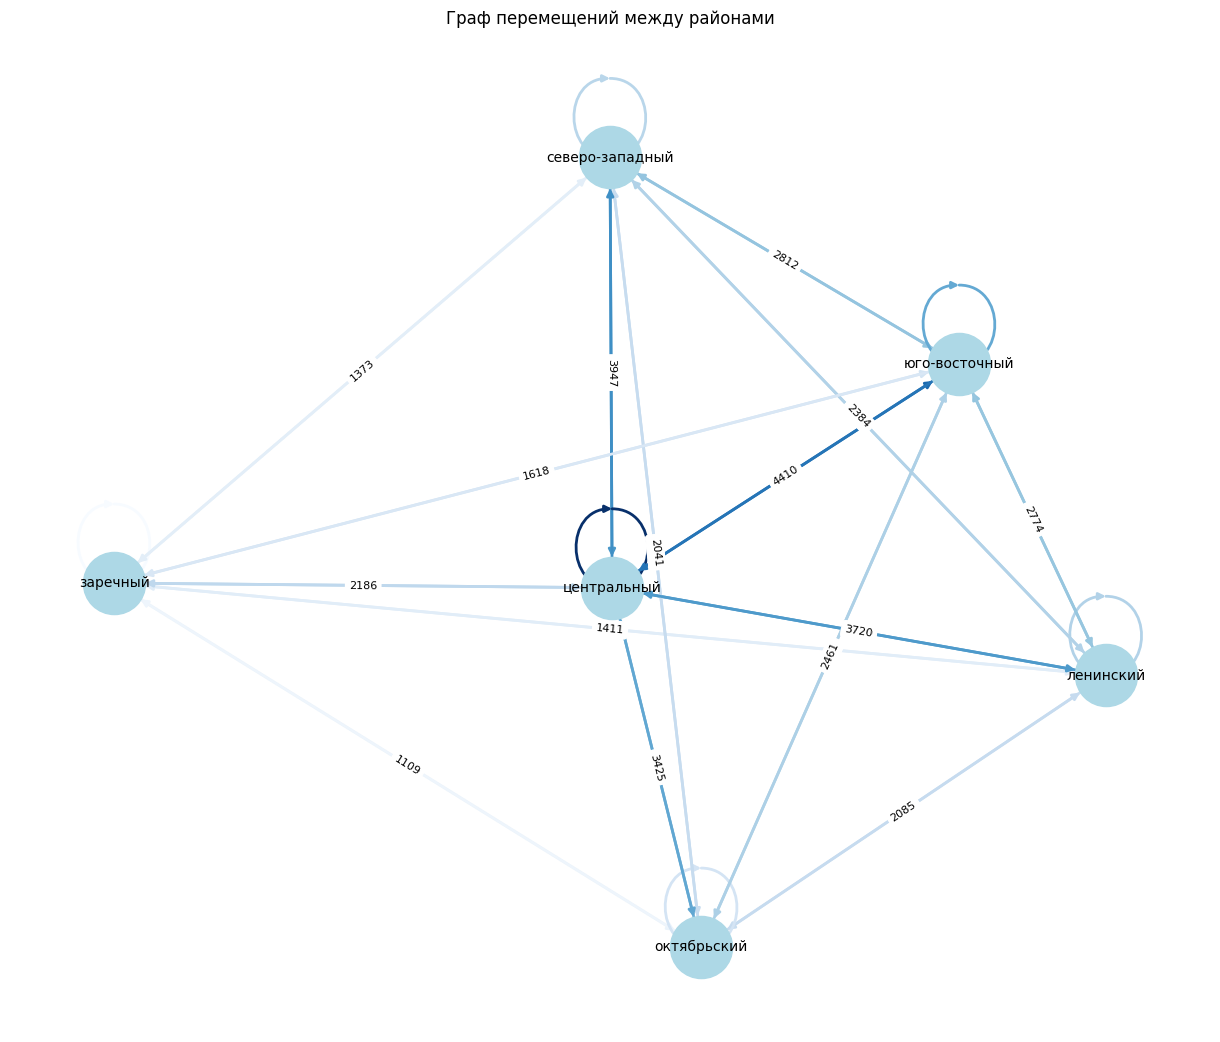

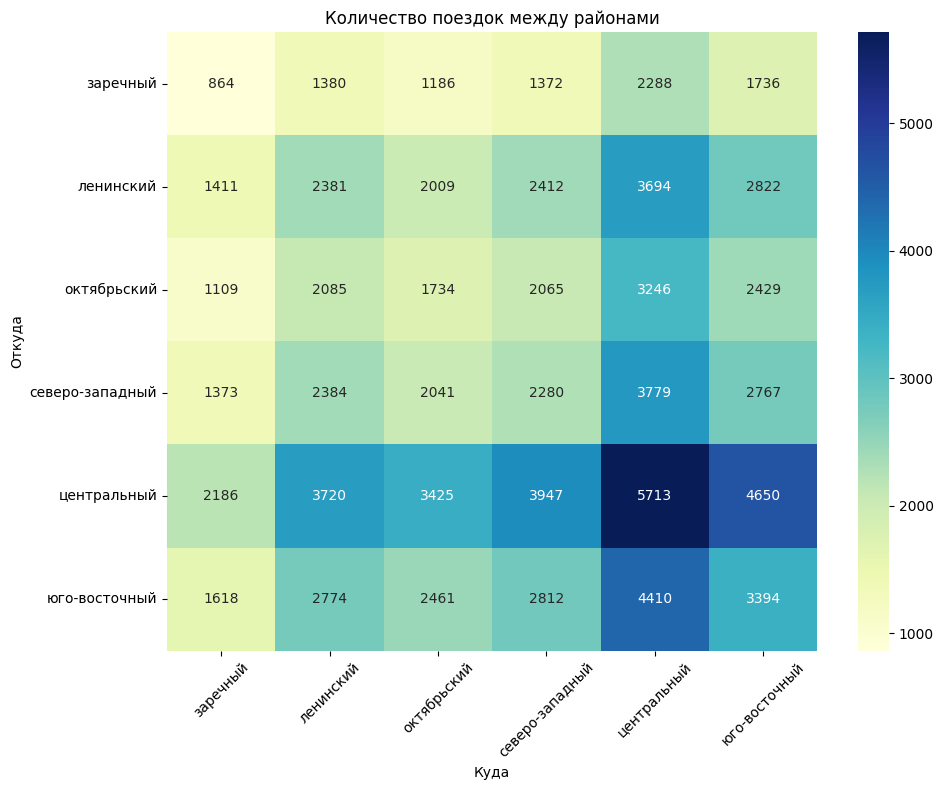

In [ ]:
import networkx as nx
district_flow = df.groupby(['Start District', 'End District']).size().reset_index(name='Trips')
# Построим граф направлений
G = nx.DiGraph()

# Добавим ребра с весами
for _, row in district_flow.iterrows():
    G.add_edge(row['Start District'], row['End District'], weight=row['Trips'])

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, seed=42)

# Толщина ребра пропорциональна количеству поездок
edges = G.edges(data=True)
weights = [d['weight'] for (_, _, d) in edges]
nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightblue', font_size=10, edge_color=weights, edge_cmap=plt.cm.Blues, width=2.0)
nx.draw_networkx_edge_labels(G, pos, edge_labels={(u, v): d['weight'] for u, v, d in edges}, font_size=8)
plt.title("Граф перемещений между районами")
plt.show()

# Пивот-таблица для тепловой карты
pivot_table = district_flow.pivot(index='Start District', columns='End District', values='Trips').fillna(0)

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Количество поездок между районами")
plt.ylabel("Откуда")
plt.xlabel("Куда")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Регрессионный анализ

#### Цель: Предсказать трафик на каждой улице по погодным условиям.
Нам это нужно для того чтобы понять насколько окупаемым будет наш день и в частности каждая точка по отдельности.
Сначала нужно предобработать данные в нормальный вид, сделать таблицу в которой индексы будут часы и дата, а в столбиках маршруты, произошедшие в этот час

In [ ]:
train = df.groupby('Date')[['Start Location', 'End Location']].apply(lambda x: x)

In [ ]:
train

Start Location End Location
Date                                          
2023 4 22 10 19          школьная     почтовая
             20           пушкина        южная
             21         подгорная  космонавтов
             22         рябиновая     шевченко
             23         солнечная   спортивная
...                           ...          ...
2023 7 9 9   69490       парковая  октябрьская
             69491      некрасова    цветочная
             69492     московская    свердлова
             69493      шоссейная  октябрьская
             69494    космонавтов   московская

[91957 rows x 2 columns]

* Дата
    * Название улицы
        * inner - сколько приехало
        * outer - сколько уехало в этот час отсюда

In [ ]:
data = {}

# Убедимся, что индекс test — мультииндекс с датой (или просто дата в ind[0])
for ind, j in tqdm(test.iterrows(), total=len(test)):
    date = ind[0]

    # Инициализируем, если даты нет
    if date not in data:
        data[date] = {}

    # Считаем входящий и исходящий трафик по Start Location
    start_loc = j['Start Location']
    end_loc = j['End Location']

    # Входящий трафик (по Start Location)
    if start_loc not in data[date]:
        data[date][start_loc] = {'inner': 0, 'outer': 0}
    data[date][start_loc]['outer'] += 1

    # Исходящий трафик (по End Location)
    if end_loc not in data[date]:
        data[date][end_loc] = {'inner': 0, 'outer': 0}
    data[date][end_loc]['inner'] += 1


100%|██████████████████████████████████████████████████████████████████████████| 91957/91957 [00:13<00:00, 6853.83it/s]


In [ ]:
all_X = pd.DataFrame()

In [ ]:
rows = []

for date, streets in data.items():
    for street, counts in streets.items():
        total_traffic = counts['inner'] + counts['outer']
        rows.append({'datetime': date, 'street': street, 'traffic': total_traffic})

all_X = pd.DataFrame(rows)
all_X['datetime'] = pd.to_datetime(df_reg['datetime'])

In [ ]:
all_X = all_X.sort_values(by='datetime')

In [ ]:
weather = w1.copy()

In [ ]:
weather = weather.rename(columns={"Datetime": "datetime"})

In [ ]:
all_X = pd.merge(all_X, weather, on='datetime', how='inner')

In [ ]:
all_X['hour'] = all_X['datetime'].apply(lambda x: x.hour)
all_X['weekday'] = all_X['datetime'].apply(lambda x: x.dayofweek)

In [ ]:
all_X

,datetime,street,traffic,Temperature,Precipitation Total,Wind Gust,Wind Speed,Cloud Cover Total,Sunshine Duration,Time of the year,hour,weekday
0,2023-04-22 09:00:00,шоссейная,2,13.850245,0.0,20.16,6.2145634,71,16.969696,Spring,9,5
1,2023-04-22 09:00:00,трудовая,1,13.850245,0.0,20.16,6.2145634,71,16.969696,Spring,9,5
2,2023-04-22 09:00:00,восточная,1,13.850245,0.0,20.16,6.2145634,71,16.969696,Spring,9,5
3,2023-04-22 09:00:00,южная,1,13.850245,0.0,20.16,6.2145634,71,16.969696,Spring,9,5
4,2023-04-22 09:00:00,подгорная,1,13.850245,0.0,20.16,6.2145634,71,16.969696,Spring,9,5
...,...,...,...,...,...,...,...,...,...,...,...,...
103229,2023-07-31 23:00:00,степная,2,20.620245,0.2,23.4,9,100,0,Summer,23,0
103230,2023-07-31 23:00:00,первомайская,4,20.620245,0.2,23.4,9,100,0,Summer,23,0
103231,2023-07-31 23:00:00,маяковского,1,20.620245,0.2,23.4,9,100,0,Summer,23,0
103232,2023-07-31 23:00:00,советская,1,20.620245,0.2,23.4,9,100,0,Summer,23,0


У нас оказался 2 категорильаных признака, которые мы должны как то перевести в число(оставлять их в таком виде нет необходимости). Я буду использовать метод One Hot Encoding, потому что у нас довольно мало самих категорий (их 9) и потому что это самый просто способ.

* Если бы мы использовали линейную регрессию то с OHE нужно было бы быть очень осторожным. Свободный коэффициент в линейной модели после добавления большого OHE линейно выразим, тем самым мы теряем смещенность модели и ее "подвижность" на плоскости. Конечно не всегда эта проблема дает о себе знать, но в голове нужно всегда держать этот риск. Мы же используем градиентный бустинг, который не линеен, поэтому нам такая проблема не грозит

In [ ]:
import pandas as pd

def ohe_feature(df, column, drop_original=True, drop_first=False, prefix=None):
    """
    One-hot encodes a single categorical column as numeric (0/1).

    Parameters:
    - df: pd.DataFrame — исходный датафрейм
    - column: str — имя категориальной колонки
    - drop_original: bool — удалить ли оригинальную колонку
    - drop_first: bool — дропнуть первую категорию
    - prefix: str — префикс для новых колонок

    Returns:
    - DataFrame с числовыми one-hot колонками
    """
    dummies = pd.get_dummies(df[column], prefix=prefix or column, drop_first=drop_first)
    dummies = dummies.astype(int)  # гарантируем числовой тип
    df = pd.concat([df, dummies], axis=1)
    if drop_original:
        df = df.drop(columns=[column])
    return df


all_X = ohe_feature(all_X, 'Time of the year')

In [ ]:
all_X = ohe_feature(all_X, 'weekday')

In [ ]:
all_X

,datetime,street,traffic,Temperature,Precipitation Total,Wind Gust,Wind Speed,Cloud Cover Total,Sunshine Duration,hour,Time of the year_Spring,Time of the year_Summer,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6
0,2023-04-22 09:00:00,шоссейная,2,13.850245,0.0,20.16,6.2145634,71,16.969696,9,1,0,0,0,0,0,0,1,0
1,2023-04-22 09:00:00,трудовая,1,13.850245,0.0,20.16,6.2145634,71,16.969696,9,1,0,0,0,0,0,0,1,0
2,2023-04-22 09:00:00,восточная,1,13.850245,0.0,20.16,6.2145634,71,16.969696,9,1,0,0,0,0,0,0,1,0
3,2023-04-22 09:00:00,южная,1,13.850245,0.0,20.16,6.2145634,71,16.969696,9,1,0,0,0,0,0,0,1,0
4,2023-04-22 09:00:00,подгорная,1,13.850245,0.0,20.16,6.2145634,71,16.969696,9,1,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103229,2023-07-31 23:00:00,степная,2,20.620245,0.2,23.4,9,100,0,23,0,1,1,0,0,0,0,0,0
103230,2023-07-31 23:00:00,первомайская,4,20.620245,0.2,23.4,9,100,0,23,0,1,1,0,0,0,0,0,0
103231,2023-07-31 23:00:00,маяковского,1,20.620245,0.2,23.4,9,100,0,23,0,1,1,0,0,0,0,0,0
103232,2023-07-31 23:00:00,советская,1,20.620245,0.2,23.4,9,100,0,23,0,1,1,0,0,0,0,0,0


In [ ]:
def last_col(col1, df2):
    cols = [c for c in df2.columns if c != col1] + [col1]
    return df2[cols]  # возвращаем изменённый DataFrame

all_X = last_col('traffic', all_X)  # сохраняем результат

In [ ]:
X1 = all_X.drop(columns=['traffic', 'datetime'])
y1 = all_X['traffic']

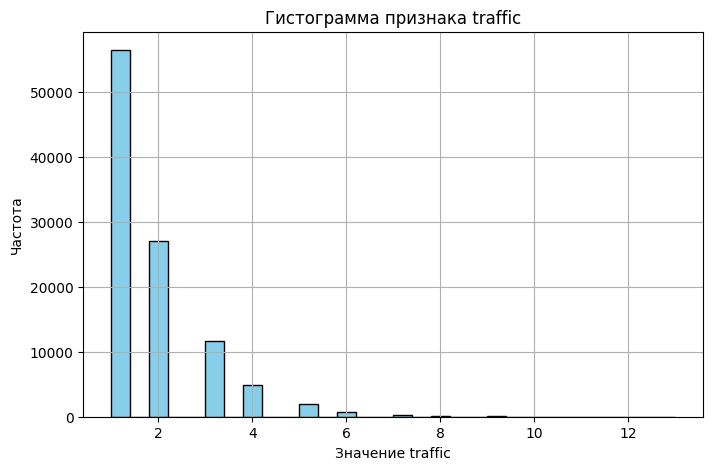

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(y1, bins=30, color='skyblue', edgecolor='black')
plt.title('Гистограмма признака traffic')
plt.xlabel('Значение traffic')
plt.ylabel('Частота')
plt.grid(True)
plt.show()


In [ ]:
y1.value_counts()

traffic
1     56487
2     27035
3     11618
4      4819
5      1935
6       767
7       334
8       131
9        65
10       21
11       12
12        7
13        3
Name: count, dtype: int64

In [ ]:
X_tr, X_t, y_tr, y_t = train_test_split(X1, y1, test_size=0.2, random_state=42)

In [ ]:
X_tr

,street,Temperature,Precipitation Total,Wind Gust,Wind Speed,Cloud Cover Total,Sunshine Duration,hour,Time of the year_Spring,Time of the year_Summer,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6
43683,школьная,27.210245,0.0,26.64,11.631956,28,43.0303,15,0,1,1,0,0,0,0,0,0
51394,победы,27.950245,0.0,26.64,12.682018,13,52.121212,18,0,1,1,0,0,0,0,0,0
2308,полевая,13.020246,0.1,45,15.188415,36,38.181816,15,1,0,1,0,0,0,0,0,0
68721,пушкина,28.070246,0.0,10.440001,8.089993,54,27.272726,17,0,1,0,0,0,1,0,0,0
66327,дачная,20.840246,0.0,20.16,6.12,28.500002,42.727272,8,0,1,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6265,центральная,14.420245,0.1,15.119999,5.0142193,65,0,23,1,0,0,0,0,0,1,0,0
54886,трудовая,24.800245,0.0,18,4.5536795,23,46.060608,9,0,1,0,0,0,0,1,0,0
76820,солнечная,29.480246,0.0,21.599998,6.489992,9.900001,54,11,0,1,0,0,0,0,1,0,0
860,горького,12.110246,0.3,10.799999,3.6179552,98,0,22,1,0,0,0,0,0,0,1,0


In [ ]:
# Индекс колонки street
cat_features = [0]

# Модель с указанием категориальных признаков и метрики MSE
model = CatBoostRegressor(iterations=10000,
                          learning_rate=0.1,
                          depth=6,
                          cat_features=cat_features,  # Указываем категориальные признаки
                          verbose=200,
                          early_stopping_rounds=50,
                          eval_metric="RMSE")  # Для MSE можно использовать RMSE (корень из MSE)

# Обучение модели
model.fit(X_tr, y_tr, eval_set=(X_t, y_t), use_best_model=True)

# Прогнозирование
y_p = model.predict(X_t)

# Оценка модели
mse = mean_squared_error(y_t, y_p)
print(f"Среднеквадратичная ошибка (MSE) на тестовых данных: {mse}")

0:	learn: 1.1104066	test: 1.1062603	best: 1.1062603 (0)	total: 122ms	remaining: 20m 15s
200:	learn: 0.9634295	test: 0.9717072	best: 0.9717072 (200)	total: 21.9s	remaining: 17m 45s
400:	learn: 0.9521326	test: 0.9689166	best: 0.9689166 (400)	total: 43.5s	remaining: 17m 22s
600:	learn: 0.9446576	test: 0.9683377	best: 0.9683116 (596)	total: 1m 5s	remaining: 17m 1s
800:	learn: 0.9386413	test: 0.9679816	best: 0.9679816 (800)	total: 1m 26s	remaining: 16m 28s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9678411471
bestIteration = 902

Shrink model to first 903 iterations.
Среднеквадратичная ошибка (MSE) на тестовых данных: 0.9367164859619512
